In [2]:
from class_polar import *
from monte_carlo_funcs import *
from sqGKP_funcs import *
from helper_funcs import *
import matplotlib.pyplot as plt
plt.rcParams['font.size'] = 60
plt.rcParams['legend.fontsize'] = 40
plt.rcParams['font.family'] = 'serif'
plt.rcParams["figure.figsize"] = (24,18)

plt.rcParams['axes.linewidth'] = 2
plt.rcParams['mathtext.fontset'] = 'stix'

In [141]:
def variance_Zwi_Q(d, N, sig, samples,alpha=1):
    """
    d: qudit dimension
    N: code-length
    sig: displacement noise
    samples: no. of runs for monte-carlo sampling
    """
    obj = cl_polar_dit_alpha(d,N,[],samples,alpha)
    
    x_error = np.random.normal(0,sig,(N,samples))
    u = np.array(np.rint(x_error/np.sqrt(2*np.pi/d))%d,dtype=int)
        
    k1 = np.mod(x_error/np.sqrt(2*np.pi),np.sqrt(1/d))
    k1[k1>=np.sqrt(1/(4*d))] -= np.sqrt(1/d)

    Lu = np.zeros((d,N,samples))
    for i in range(N):
        for j in range(samples):
            Lu[:,i,j] = pu_belief(k1[i,j],sig,u[i,j],d)

    obj.sc_decode(Lu)
    meanlogZ_Wi_list_X = scipy.special.logsumexp(-obj.LLRs/2,axis=-1) - np.log(samples)
    varlogZ_Wi_list_X = scipy.special.logsumexp(-obj.LLRs,axis=-1) - np.log(samples)
    varlogZ_Wi_list_X = scipy.special.logsumexp(
       np.stack([varlogZ_Wi_list_X, meanlogZ_Wi_list_X*2],axis=0), axis = 0, b = np.array([1.0, -1.0])[..., None, None]) - np.log(samples)
    return np.exp(meanlogZ_Wi_list_X), np.exp(varlogZ_Wi_list_X/2)

Text(0, 0.5, '$Z(W^{(i)})$')

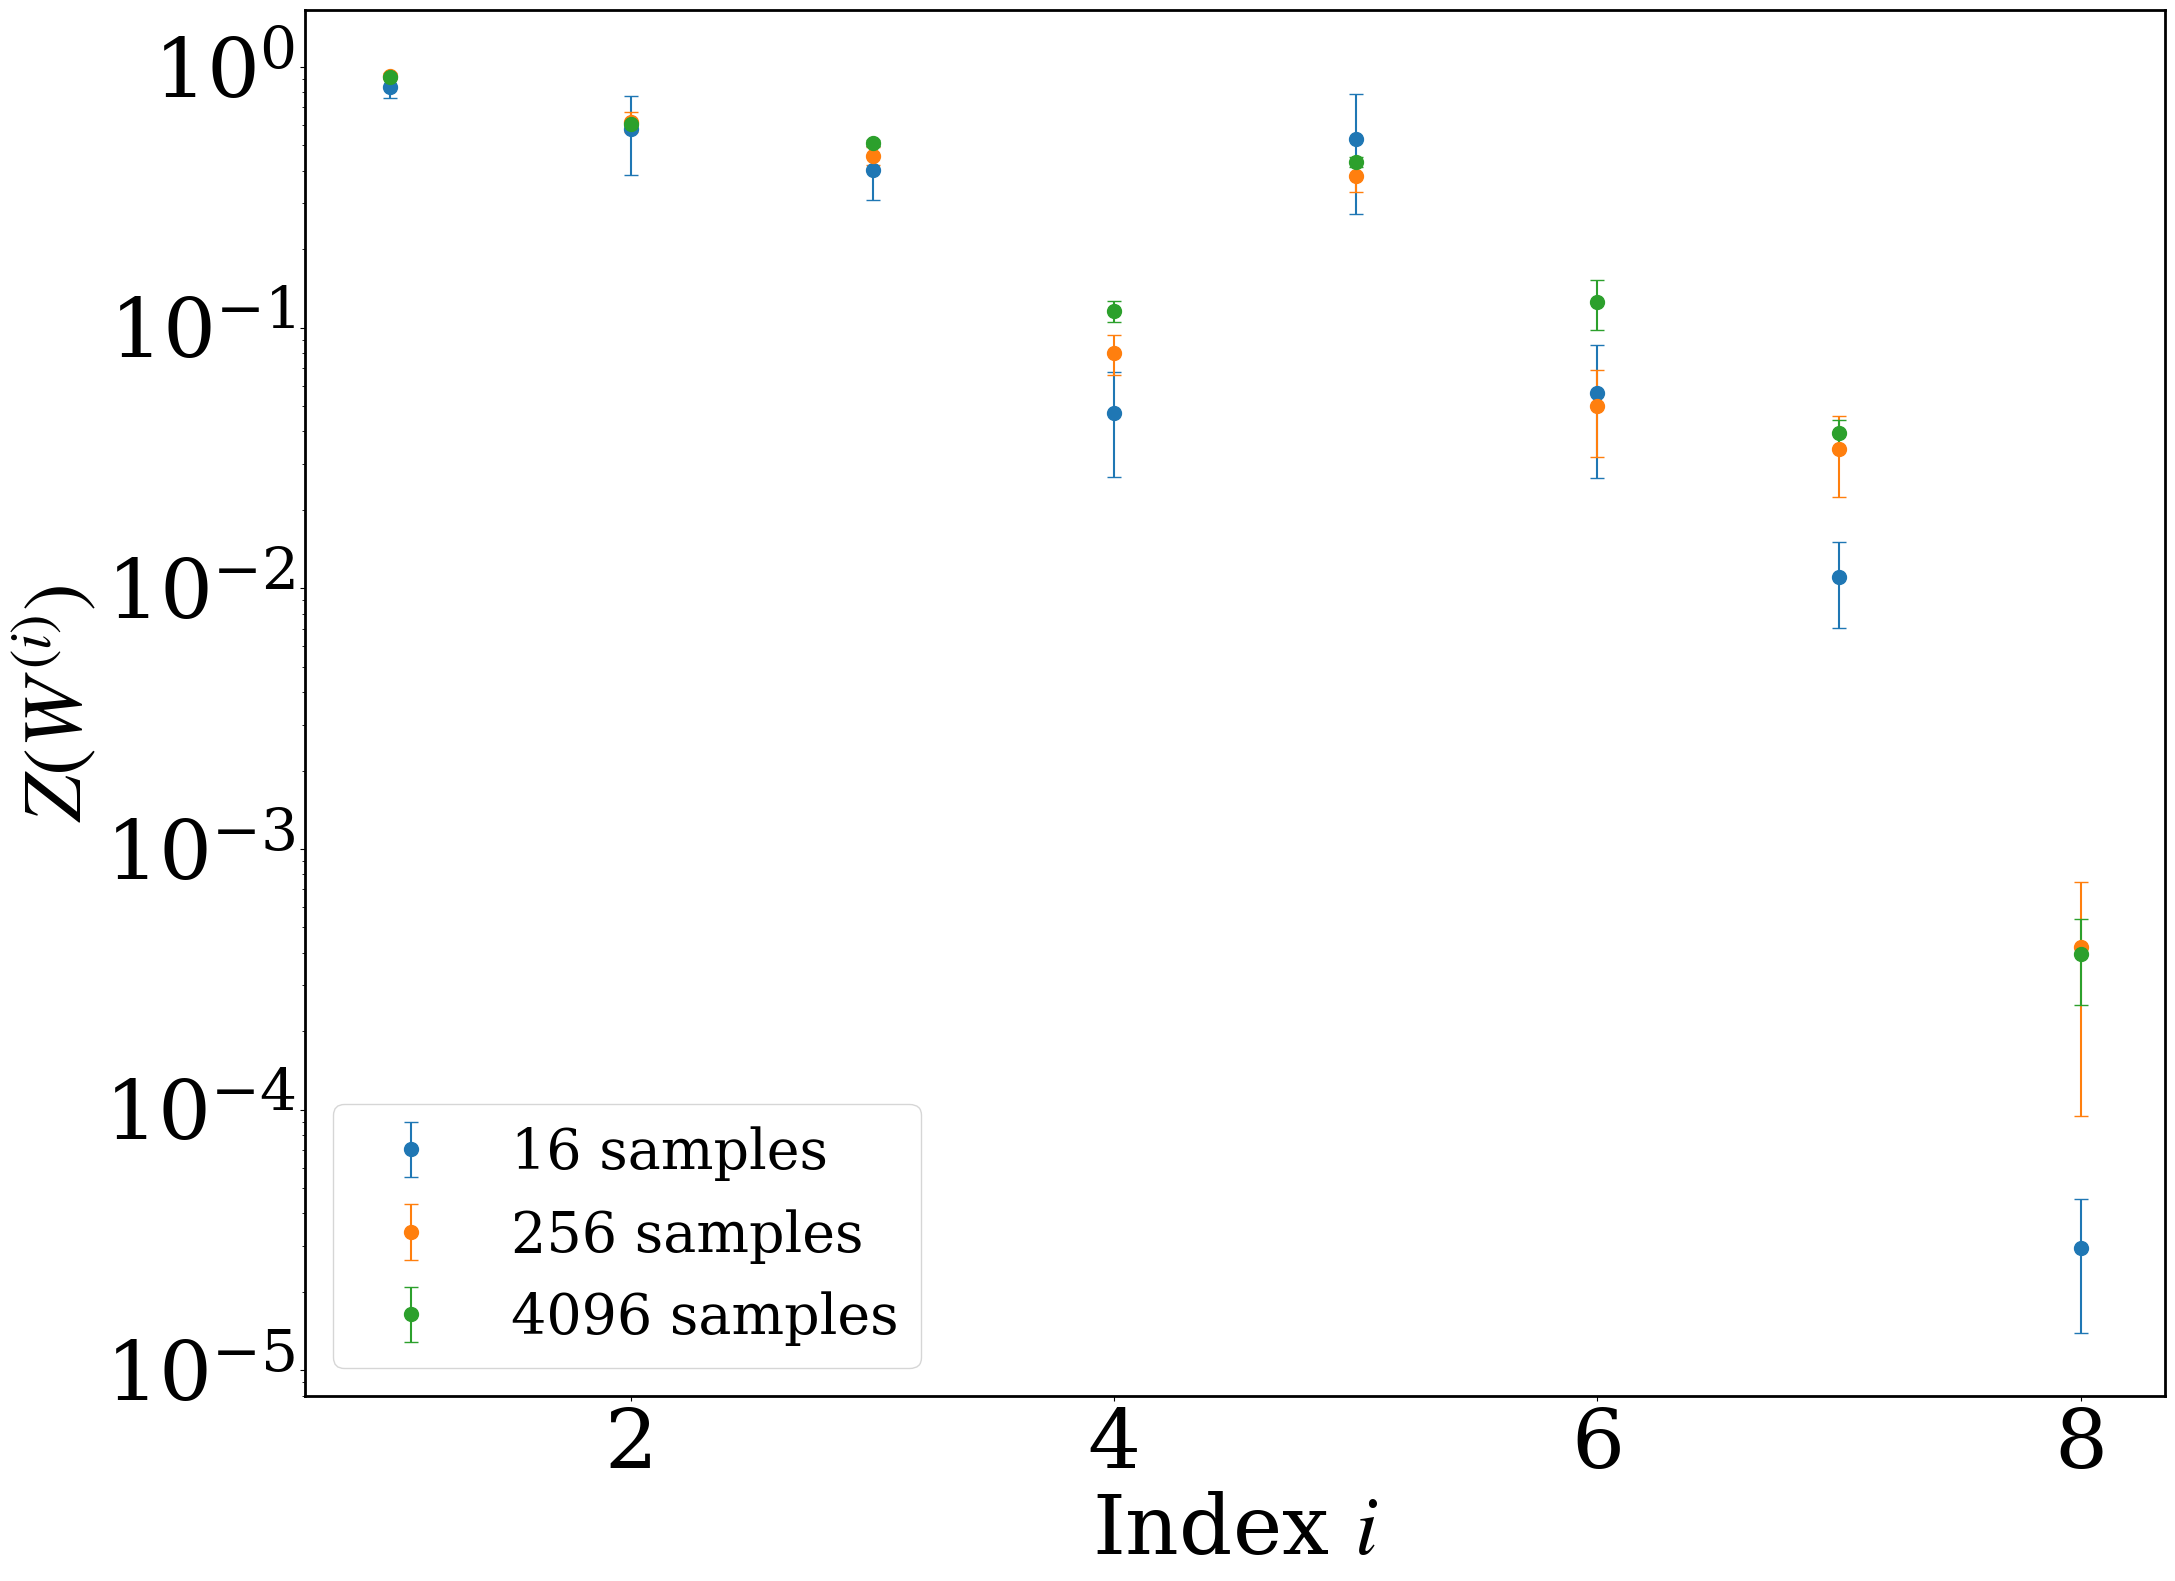

In [208]:
for i in [4,8,12]:
    mu, sig = variance_Zwi_Q(2, 8, 0.5, 2**i, alpha=1)
    plt.errorbar(range(1,1+len(mu[0])), mu[0], yerr=sig[0], fmt='o', capsize=5, markersize=10, label=str(2**i)+' samples')

plt.yscale('log')
plt.legend()
plt.xlabel('Index $i$')
plt.ylabel(r'$Z(W^{(i)})$')

In [218]:
alltryZ = []
variance = []
means = []
tries = 100
for samples in [2**8, 2**10, 2**12]:
    for i in range(tries):
        alltryZ.append(estimate_Z_Wi_displ_sq_dGKP_Q(2, 8, 0.5, samples))
    variance.append(np.var(np.array(alltryZ),axis = 0))
    means.append(np.mean(np.array(alltryZ),axis=0))
variance = np.array(variance)
means = np.array(means)

Text(0, 0.5, '$Z(W^{(i)})$')

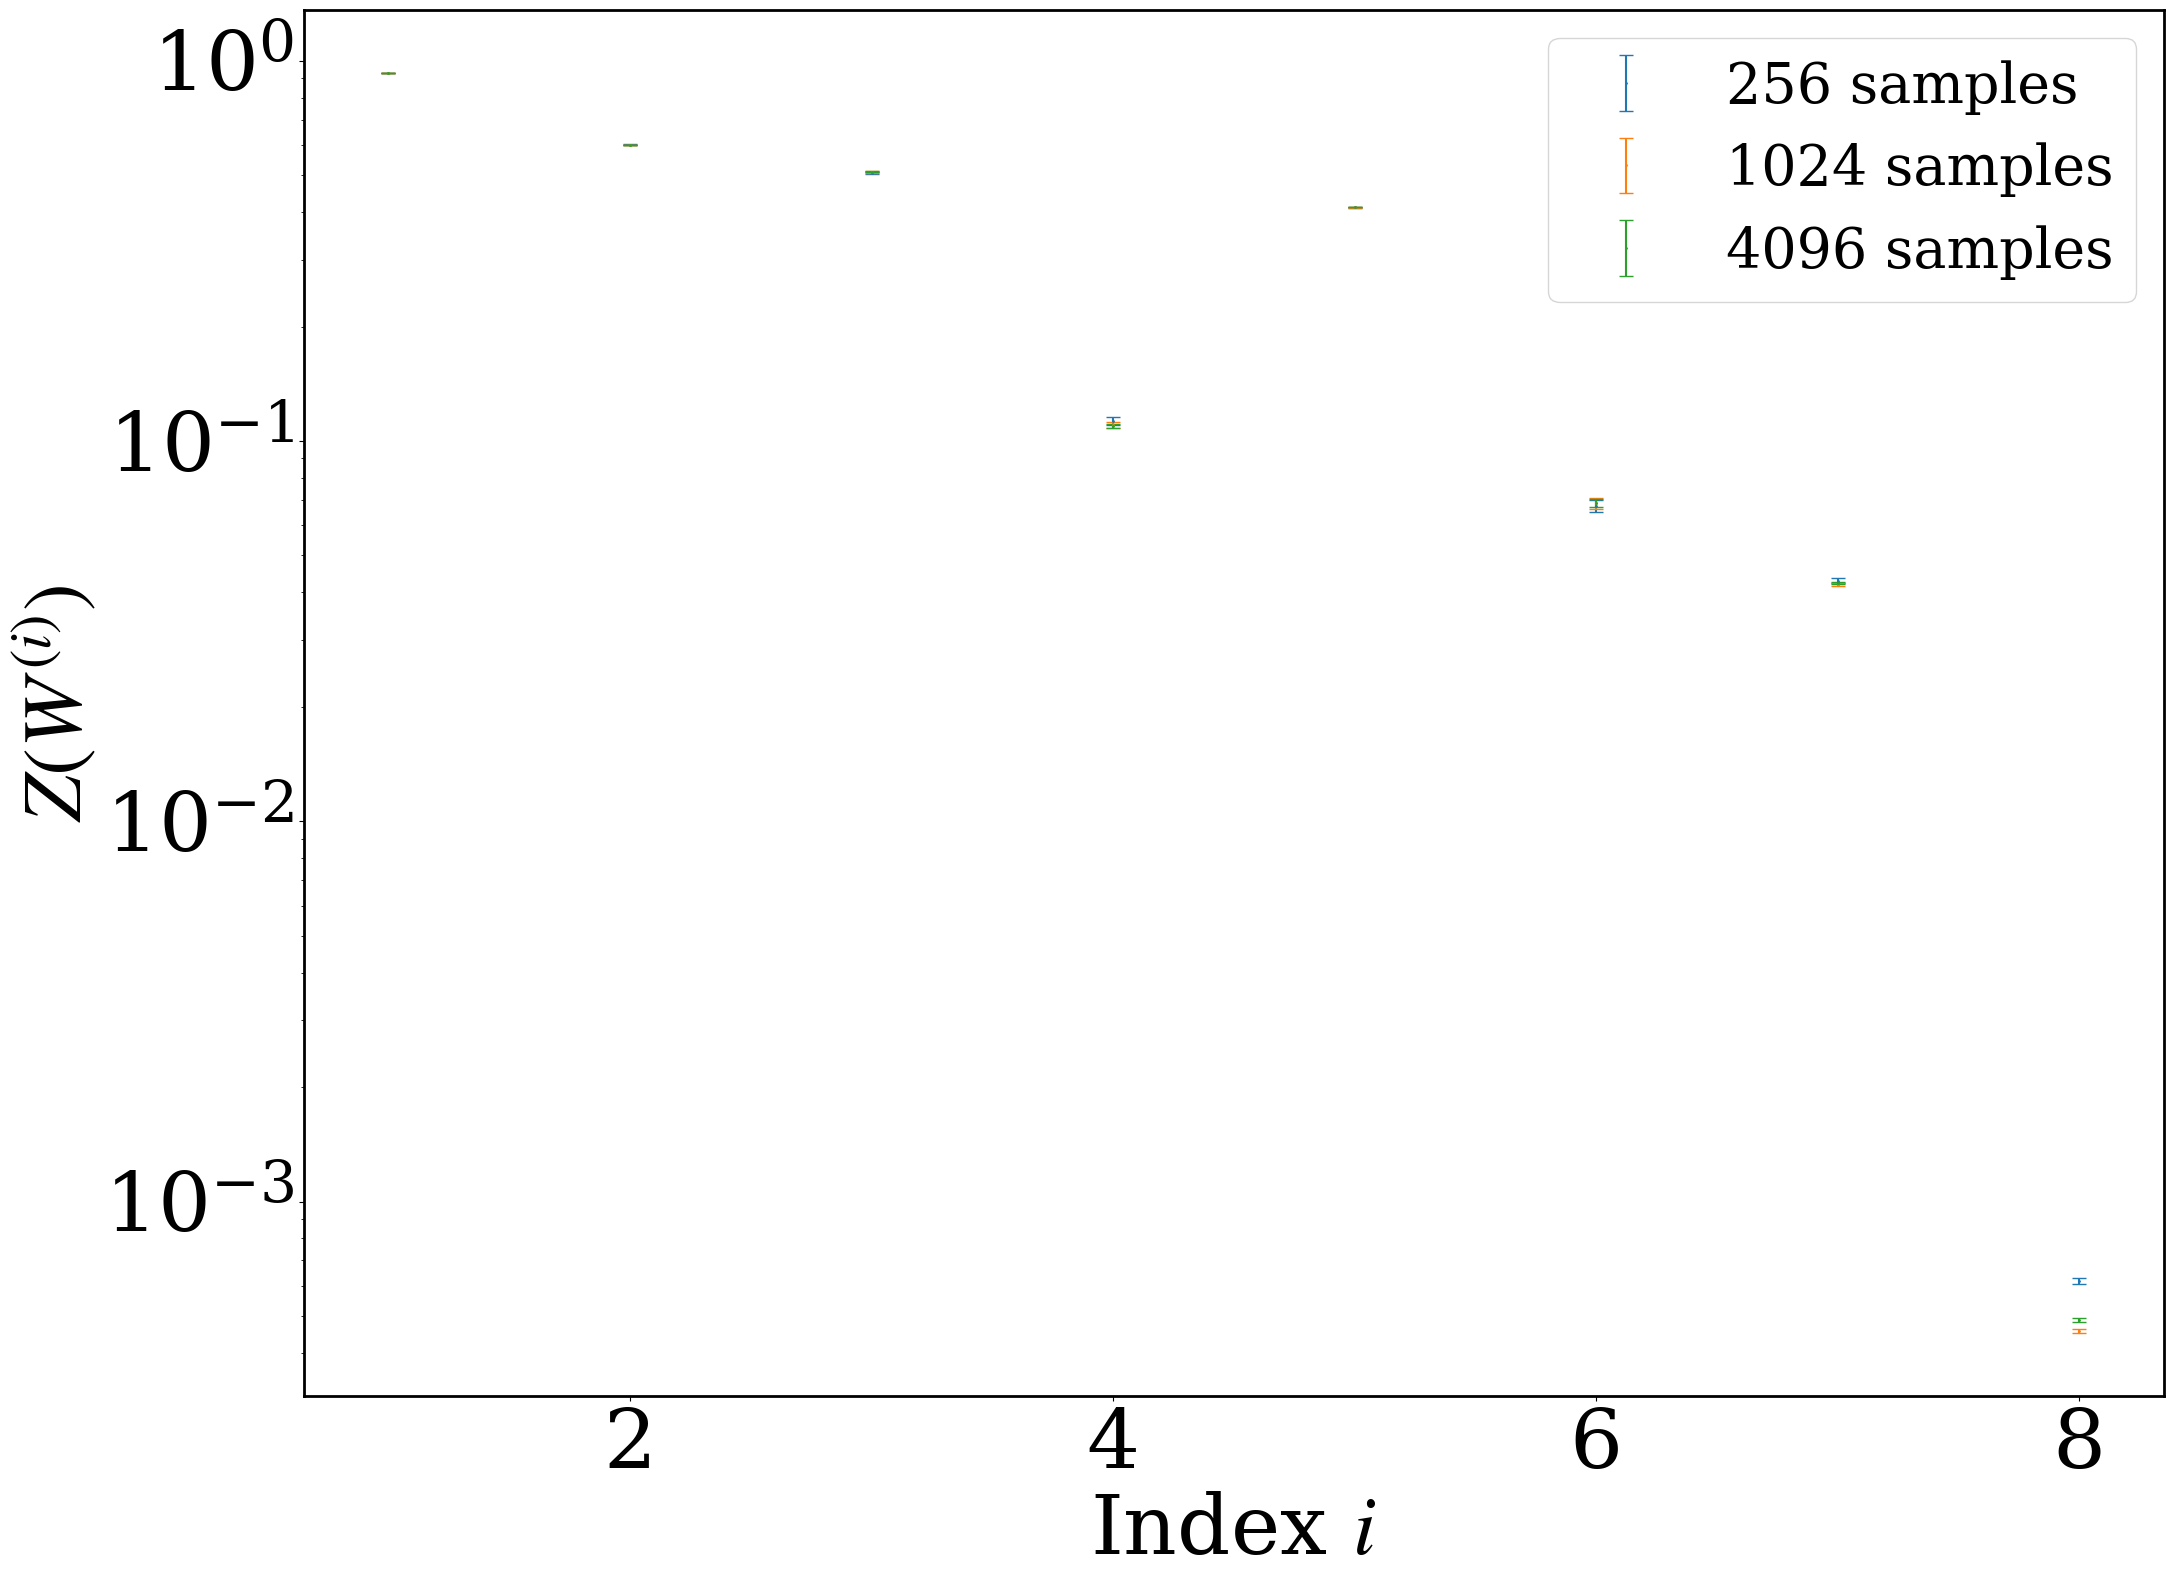

In [220]:
for i in range(3):
    plt.errorbar(range(1,1+len(means[i])), means[i], yerr=variance[i], fmt='o', capsize=5, markersize=1, label=str(2**(2*i+8))+' samples')

plt.yscale('log')
plt.legend()
plt.xlabel('Index $i$')
plt.ylabel(r'$Z(W^{(i)})$')

In [142]:
def pus(ums,d,sig,l_cutoff=20):
    u_list = np.array(range(-l_cutoff*d, l_cutoff*d + 1, d)) + ums*d
    log_numer = scipy.special.logsumexp(-((u_list*np.sqrt(2*np.pi/d))**2)/(2*sig*sig))
    return np.exp(log_numer)/(np.sqrt(d)*sig)

In [143]:
def ps(s,d,sig,l_cutoff=20):
    u_list = np.array(range(-l_cutoff, l_cutoff + 1, 1)) + s
    log_numer = scipy.special.logsumexp(-((u_list*np.sqrt(2*np.pi/d))**2)/(2*sig*sig))
    return np.exp(log_numer)/(np.sqrt(d)*sig)

In [ ]:
def log_recursive_Zwi_upper_alpha(log_Zwi_half, alpha):
    d, N = log_Zwi_half.shape
    log_Zwi = np.zeros((d,2*N), dtype=log_Zwi_half.dtype) - np.inf
    for i in range(d):
        for j in range(d):
            log_Zwi[i,:2*N:2] = np.logaddexp(log_Zwi[i,:2*N:2], log_Zwi_half[j,:] + log_Zwi_half[(j*alpha + i)%d,:])
        if d == 2:
            log_Zwi[i,:2*N:2] = scipy.special.logsumexp(
                np.stack([log_Zwi[i,:2*N:2], log_Zwi_half[i,:]],axis=0), axis = 0, b = np.array([1.0, -1.0])[..., None, None])
        log_Zwi[i,1:2*N:2] = log_Zwi_half[i,:] + log_Zwi_half[(i*alpha)%d,:]
    return np.minimum(np.zeros(log_Zwi.shape),log_Zwi)

In [302]:
def pus(ums,d,sig,l_cutoff=20):
    u_list = np.array(range(-l_cutoff*d, l_cutoff*d + 1, d)) + ums*d
    log_numer = scipy.special.logsumexp(-((u_list*np.sqrt(2*np.pi/d))**2)/(2*sig*sig))
    return np.exp(log_numer)/(np.sqrt(d)*sig)
def pus_lim(ums,d,sig):
    return np.exp(-np.pi*d*((ums/sig)**2))/(np.sqrt(d)*sig)

def my_mod(u, d):
    umod = np.mod(u,d)
    if umod >= d/2:
        umod -= d
    return umod

def Z_w_integrand(s,d,u,sig):
    integrand = 0
    for uu in range(d):
        uups = my_mod(uu+u, d)/d + s/d
        ups = my_mod(uu,d)/d + s/d
        integrand += np.sqrt(pus(uups, d, sig)*pus(ups, d, sig))
    return integrand


def get_rates(d, alpha, sig, n_low, n_high):
    N = [2**i for i in range(n_low, n_high+1)]
    rate = []
    pe = []
    Z = np.log(np.array([[scipy.integrate.quad(lambda s: Z_w_integrand(s,d,i,sig),-1/2,1/2)[0]] for i in range(d)]))
    for i in range(n_low-1):
        Z = log_recursive_Zwi_upper_alpha(Z, alpha)
    for n in N:
        Z = log_recursive_Zwi_upper_alpha(Z, alpha)
        Zsum = np.sort(scipy.special.logsumexp(Z[1:,:],axis=0))
        px = -np.inf
        count1 = 0
        for i in range(n):
            if np.exp(px) >= 0.5*(1/4)**(np.log2(n)/9):
                break
            px = np.logaddexp(px,Zsum[i])
            count1 += 1
        pe.append(px)
        rate.append(max(0,(count1+count1)/len(Zsum) - 1))

    return rate, pe


In [146]:
def estimate_Z_Wi_displ_sq_dGKP_all(d, N, sig, samples,alpha=1):
    """
    d: qudit dimension
    N: code-length
    sig: displacement noise
    samples: no. of runs for monte-carlo sampling
    """
    obj = cl_polar_dit_alpha(d,N,[],samples,alpha)
    
    x_error = np.random.normal(0,sig,(N,samples))
    u = np.array(np.rint(x_error/np.sqrt(2*np.pi/d))%d,dtype=int)
        
    k1 = np.mod(x_error/np.sqrt(2*np.pi),np.sqrt(1/d))
    k1[k1>=np.sqrt(1/(4*d))] -= np.sqrt(1/d)

    Lu = np.zeros((d,N,samples))
    for i in range(N):
        for j in range(samples):
            Lu[:,i,j] = pu_belief(k1[i,j],sig,u[i,j],d)

    obj.sc_decode(Lu)
    logZ_Wi_list_X = scipy.special.logsumexp(-obj.LLRs/2,axis=-1)

    return np.concatenate((np.ones((1,N),dtype=logZ_Wi_list_X.dtype),(np.exp(logZ_Wi_list_X))/(samples)))

In [413]:
def estimate_sq_dGKP_worst_err(d, N, sig, samples,alpha=1):
    """
    d: qudit dimension
    N: code-length
    sig: displacement noise
    samples: no. of runs for monte-carlo sampling
    """
    obj = cl_polar_dit_alpha(d,N,[],samples,alpha)
    
    x_error = np.random.normal(0,sig,(N,samples))
    u = np.array(np.rint(x_error/np.sqrt(2*np.pi/d))%d,dtype=int)
        
    k1 = np.mod(x_error/np.sqrt(2*np.pi),np.sqrt(1/d))
    k1[k1>=np.sqrt(1/(4*d))] -= np.sqrt(1/d)

    Lu = np.zeros((d,N,samples))
    for i in range(N):
        for j in range(samples):
            Lu[:,i,j] = pu_belief(k1[i,j],sig,u[i,j],d)

    obj.sc_decode(Lu)
    worst_err = np.sum(np.min(-obj.LLRs/2,axis=0) < -np.log(N)*1.25, axis=-1)

    return worst_err/samples

In [ ]:
def estimate_sq_dGKP_err(d, N, A, sig, samples, alpha=1):
    """
    d: qudit dimension
    N: code-length
    A: information set
    sig: displacement noise
    samples: no. of runs for monte-carlo sampling
    """
    obj = cl_polar_dit_alpha(d,N,A,samples,alpha)
    
    x_error = np.random.normal(0,sig,(N,samples))
    u = np.array(np.rint(x_error/np.sqrt(2*np.pi/d))%d,dtype=int)
        
    k1 = np.mod(x_error/np.sqrt(2*np.pi),np.sqrt(1/d))
    k1[k1>=np.sqrt(1/(4*d))] -= np.sqrt(1/d)

    Lu = np.zeros((d,N,samples))
    for i in range(N):
        for j in range(samples):
            Lu[:,i,j] = pu_belief(k1[i,j],sig,u[i,j],d)

    output = obj.sc_decode(Lu)
    err_counts = np.sum(np.sum(output,axis=0) > 0)

    return err_counts/samples

In [473]:
N = [2**9,2**10,2**11,2**12,2**13,2**14,2**15,2**16,2**17,2**18]
rate51 = []
pe51 = []
Aset = []
for n in N:
    A = []
    Z = np.sort(np.load('Zdata_alpha/Z_Wi_sig0.4_'+str(n)+'_d5_a2_Q.npy'))
    Z_ind = np.argsort(np.load('Zdata_alpha/Z_Wi_sig0.4_'+str(n)+'_d5_a2_Q.npy'))
    px = 0.0
    count1 = 0
    count2 = 0
    for i in range(n):
        if px >= 0.5*(1/4)**(np.log2(n)/9):
            break
        px += 4*Z[i]
        count1 += 1
        A.append(Z_ind[i])
    pe51.append(px)
    rate51.append(max(0,(count1*2)/len(Z) - 1))
    Aset.append(A)

print(*pe51)
print(*rate51)

0.13627297368665947 0.11215563070500031 0.09257560612720947 0.07885076950313982 0.06804259408826038 0.05837699133010153 0.04975642211920149 0.042707458421775896 0.0364742456408494 0.03126734034118807
0.28125 0.306640625 0.3291015625 0.35205078125 0.3720703125 0.389404296875 0.40692138671875 0.42120361328125 0.4339447021484375 0.444671630859375


In [486]:
peac51 = []
for i in range(len([2**9,2**10,2**11,2**12,2**13,2**14,2**15])):
    peac51.append(estimate_sq_dGKP_err(5,512*(2**i),Aset[i],0.4,100,2))

In [494]:
N = 2048
scipy.stats.binom.cdf(N*0.02,N,0.03)

0.00207508512536174

In [487]:
peac51

[0.01, 0.03, 0.01, 0.0, 0.01, 0.03, 0.01]

In [414]:
perr_512_5_04 = estimate_sq_dGKP_worst_err(5,512,0.4,512,2)
perr_1024_5_04 = estimate_sq_dGKP_worst_err(5,1024,0.4,512,2)

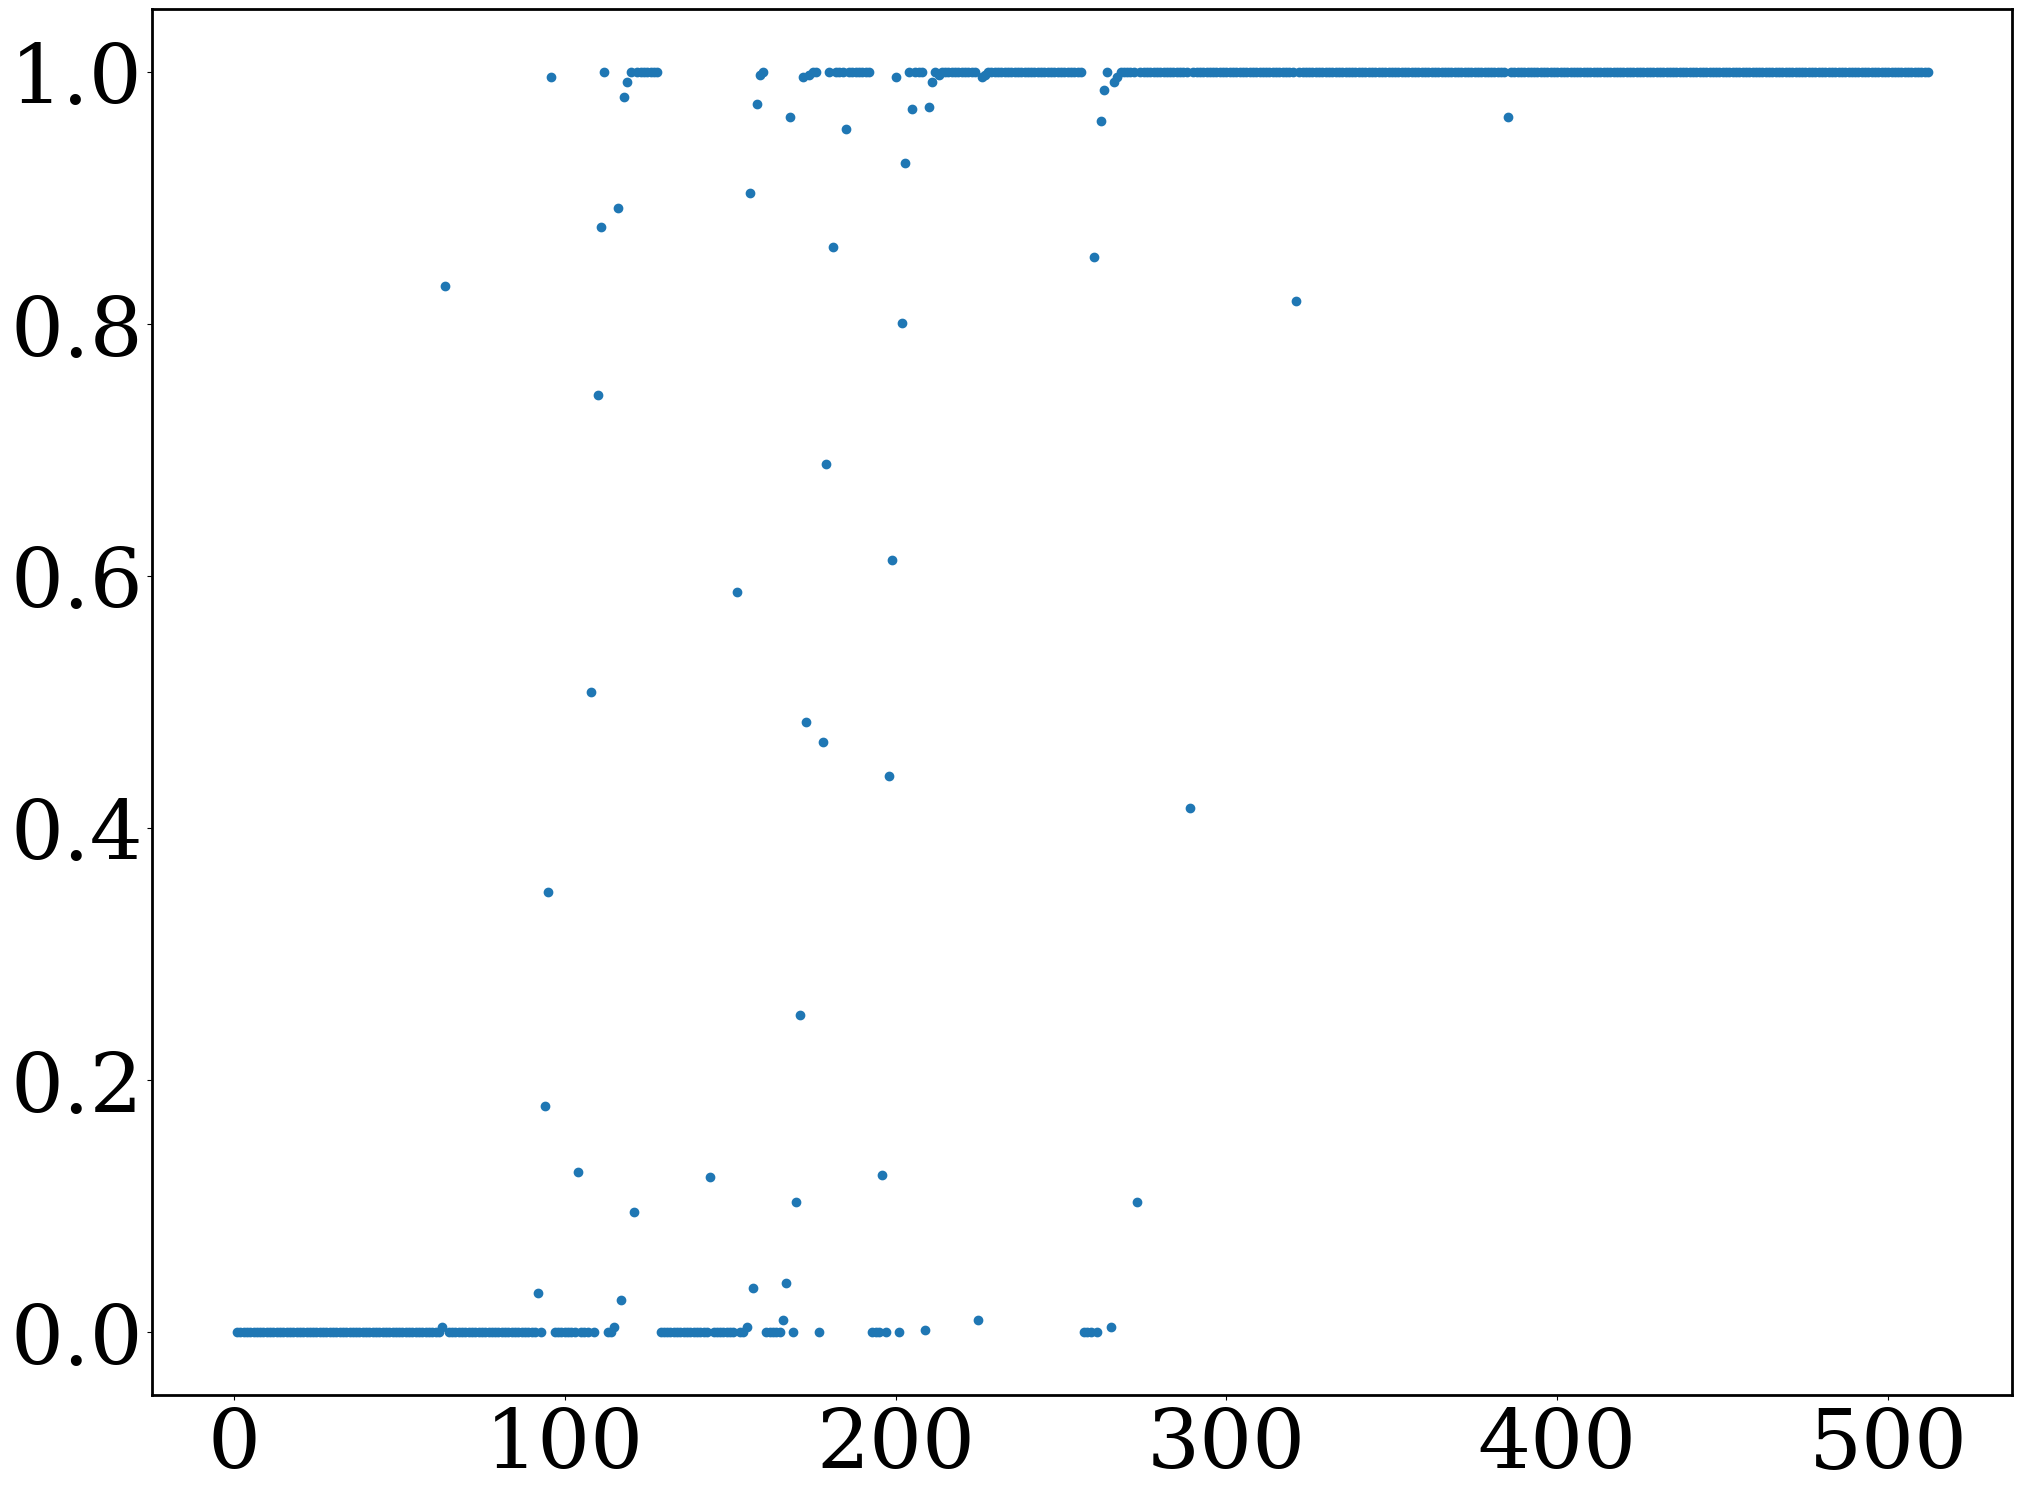

In [416]:
plt.scatter(range(1,513),perr_512_5_04)
#plt.yscale('log')

In [417]:
np.sum(perr_512_5_04>=1)/512

0.60546875

In [418]:
(2*np.sum(perr_512_5_04>=1)/512 - 1),(2*np.sum(perr_1024_5_04>=1)/1024 - 1)

(0.2109375, 0.259765625)

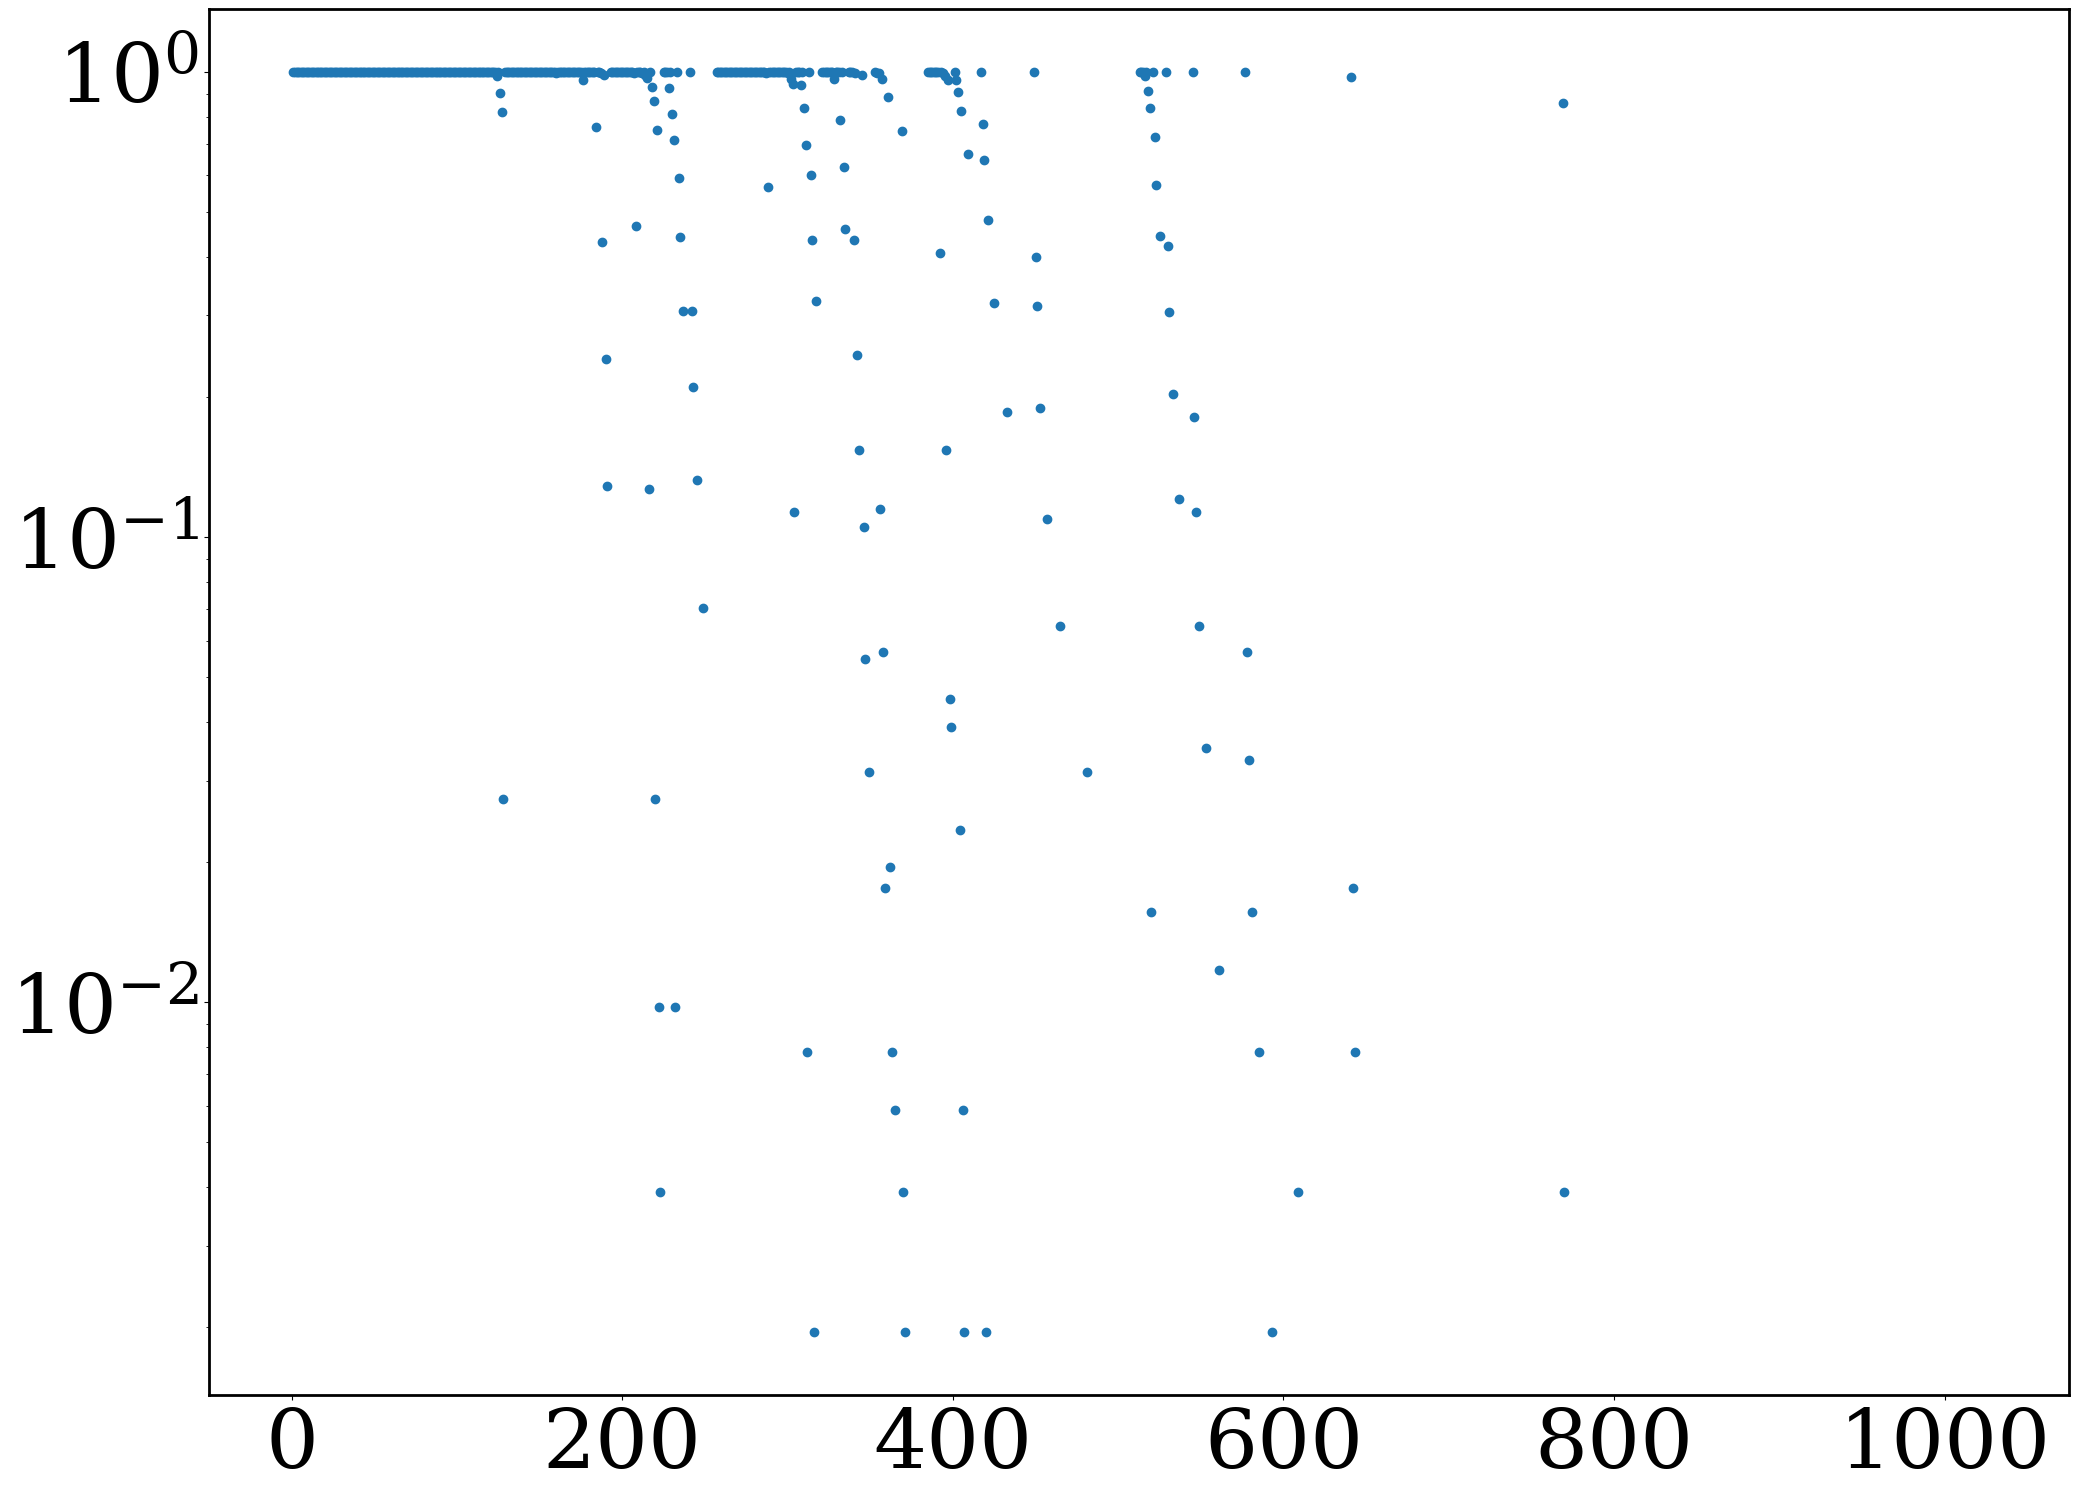

In [400]:
plt.scatter(range(1,1025),np.min(perr_1024_5_04,axis=0))

In [147]:
def multidimensional_Z_wi_integrand(x, d, N, alpha = 1):
    obj = cl_polar_dit_alpha(d,N,[],1,alpha)
    u = np.array(np.rint(x/np.sqrt(2*np.pi/d))%d,dtype=int)
        
    k1 = np.mod(x/np.sqrt(2*np.pi),np.sqrt(1/d))
    k1[k1>=np.sqrt(1/(4*d))] -= np.sqrt(1/d)

    Lu = np.zeros((d,N))
    for i in range(N):
        Lu[:,i] = pu_belief(k1[i],sig,u[i],d)

    obj.sc_decode(Lu.reshape((d,N,1)))
    return np.exp(-obj.LLRs/2).flatten()


In [567]:
z_128_mc_a1 = estimate_Z_Wi_displ_sq_dGKP_all(5, 128, 0.4, 1024,alpha=1)
z_128_mc_a2 = estimate_Z_Wi_displ_sq_dGKP_all(5, 128, 0.4, 1024,alpha=2)

In [568]:
z_128_mc_a1.shape

(5, 128)

(1e-24, 1)

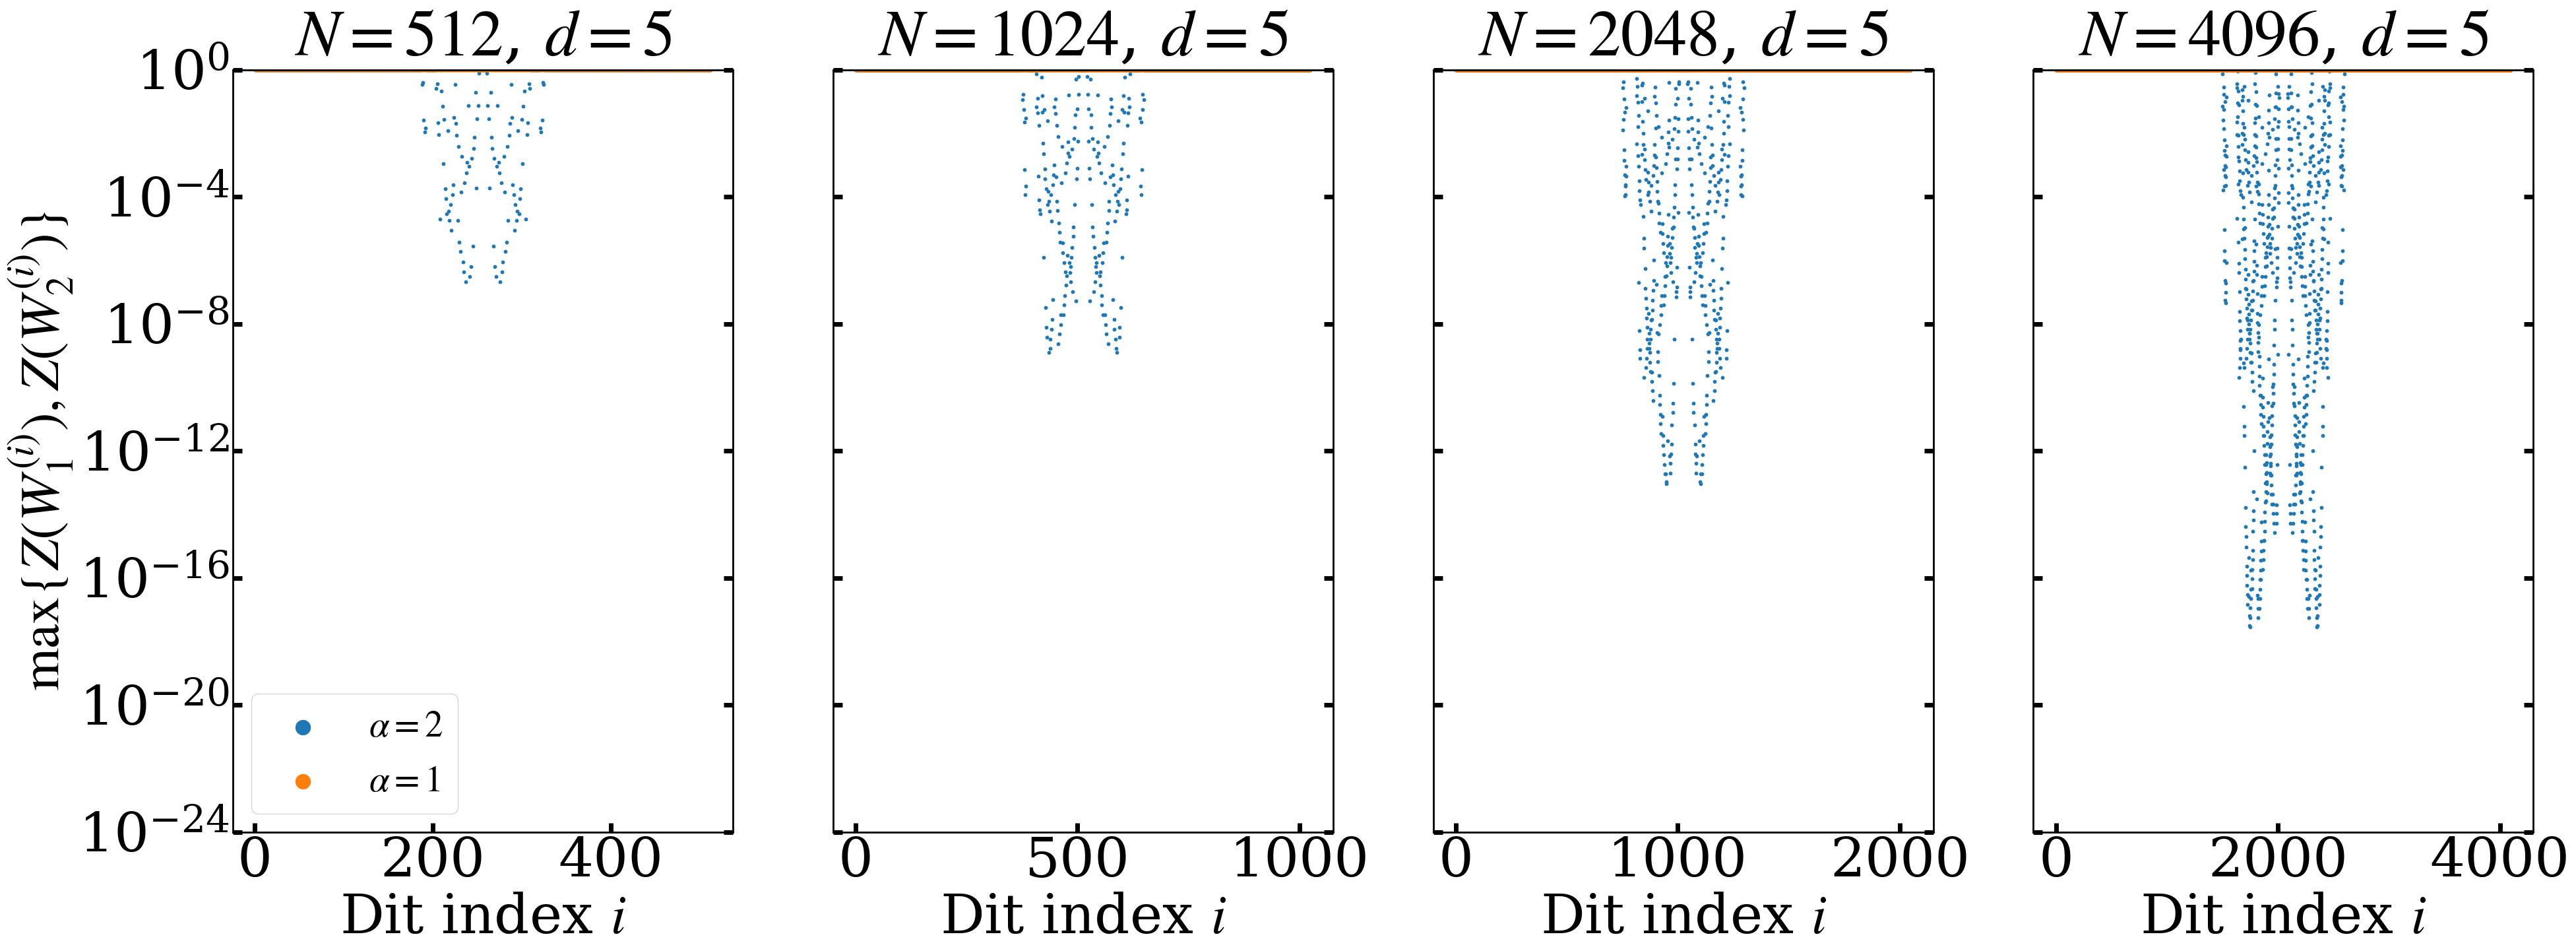

In [590]:
Z_5_03 = np.array([[scipy.integrate.quad(lambda s: Z_w_integrand(s,5,i,0.4),-1/2,1/2)[0]] for i in range(5)])

Z1 = np.log(Z_5_03)
Z2 = np.log(Z_5_03)
for i in range(8):
    Z1 = log_recursive_Zwi_upper_alpha(Z1, 1)
    Z2 = log_recursive_Zwi_upper_alpha(Z2, 2)

sze=10
plt.rcParams["figure.figsize"] = (45,15)

fig, axes = plt.subplots(1, 4, sharey=True)

Z1 = log_recursive_Zwi_upper_alpha(Z1, 1)
Z2 = log_recursive_Zwi_upper_alpha(Z2, 2)

N = len(Z1[0,:])
ZX = np.mean(np.exp(Z2[1:,:]),axis=0)
axes[0].set_title('$N ='+str(N)+' $, $d=5$')
axes[0].scatter(range(1,N+1),np.maximum(ZX,np.flip(ZX)),s=sze,label=r'$\alpha = 2$')

ZX = np.mean(np.exp(Z1[1:,:]),axis=0)
axes[0].scatter(range(1,N+1),np.maximum(ZX,np.flip(ZX)),s=sze,label=r'$\alpha = 1$')
axes[0].legend(markerscale=5)

Z1 = log_recursive_Zwi_upper_alpha(Z1, 1)
Z2 = log_recursive_Zwi_upper_alpha(Z2, 2)

N = len(Z1[0,:])
ZX = np.mean(np.exp(Z2[1:,:]),axis=0)
axes[1].set_title('$N ='+str(N)+' $, $d=5$')
axes[1].scatter(range(1,N+1),np.maximum(ZX,np.flip(ZX)),s=sze,label=r'$\alpha = 2$')

ZX = np.mean(np.exp(Z1[1:,:]),axis=0)
axes[1].scatter(range(1,N+1),np.maximum(ZX,np.flip(ZX)),s=sze,label=r'$\alpha = 1$')
#axes[1].legend(markerscale=5)

Z1 = log_recursive_Zwi_upper_alpha(Z1, 1)
Z2 = log_recursive_Zwi_upper_alpha(Z2, 2)

N = len(Z1[0,:])
ZX = np.mean(np.exp(Z2[1:,:]),axis=0)
axes[2].set_title('$N ='+str(N)+' $, $d=5$')
axes[2].scatter(range(1,N+1),np.maximum(ZX,np.flip(ZX)),s=sze,label=r'$\alpha = 2$')

ZX = np.mean(np.exp(Z1[1:,:]),axis=0)
axes[2].scatter(range(1,N+1),np.maximum(ZX,np.flip(ZX)),s=sze,label=r'$\alpha = 1$')
#axes[2].legend(markerscale=5)

Z1 = log_recursive_Zwi_upper_alpha(Z1, 1)
Z2 = log_recursive_Zwi_upper_alpha(Z2, 2)

N = len(Z1[0,:])
ZX = np.mean(np.exp(Z2[1:,:]),axis=0)
axes[3].set_title('$N ='+str(N)+' $, $d=5$')
axes[3].scatter(range(1,N+1),np.maximum(ZX,np.flip(ZX)),s=sze,label=r'$\alpha = 2$')

ZX = np.mean(np.exp(Z1[1:,:]),axis=0)
axes[3].scatter(range(1,N+1),np.maximum(ZX,np.flip(ZX)),s=sze,label=r'$\alpha = 1$')
#axes[3].legend(markerscale=5)

axes[0].set_ylabel(r'$\max\{Z(W_1^{(i)}),Z(W_2^{(i)})\}$')
for i in range(4):
    axes[i].tick_params(axis='y', direction='in',width=5,length=10,right=True)
    axes[i].tick_params(axis='x', direction='in',width=5,length=10)
    axes[i].set_xlabel(r'Dit index $i$')
plt.yscale('log')
plt.ylim(1e-24,1)

(1e-24, 1)

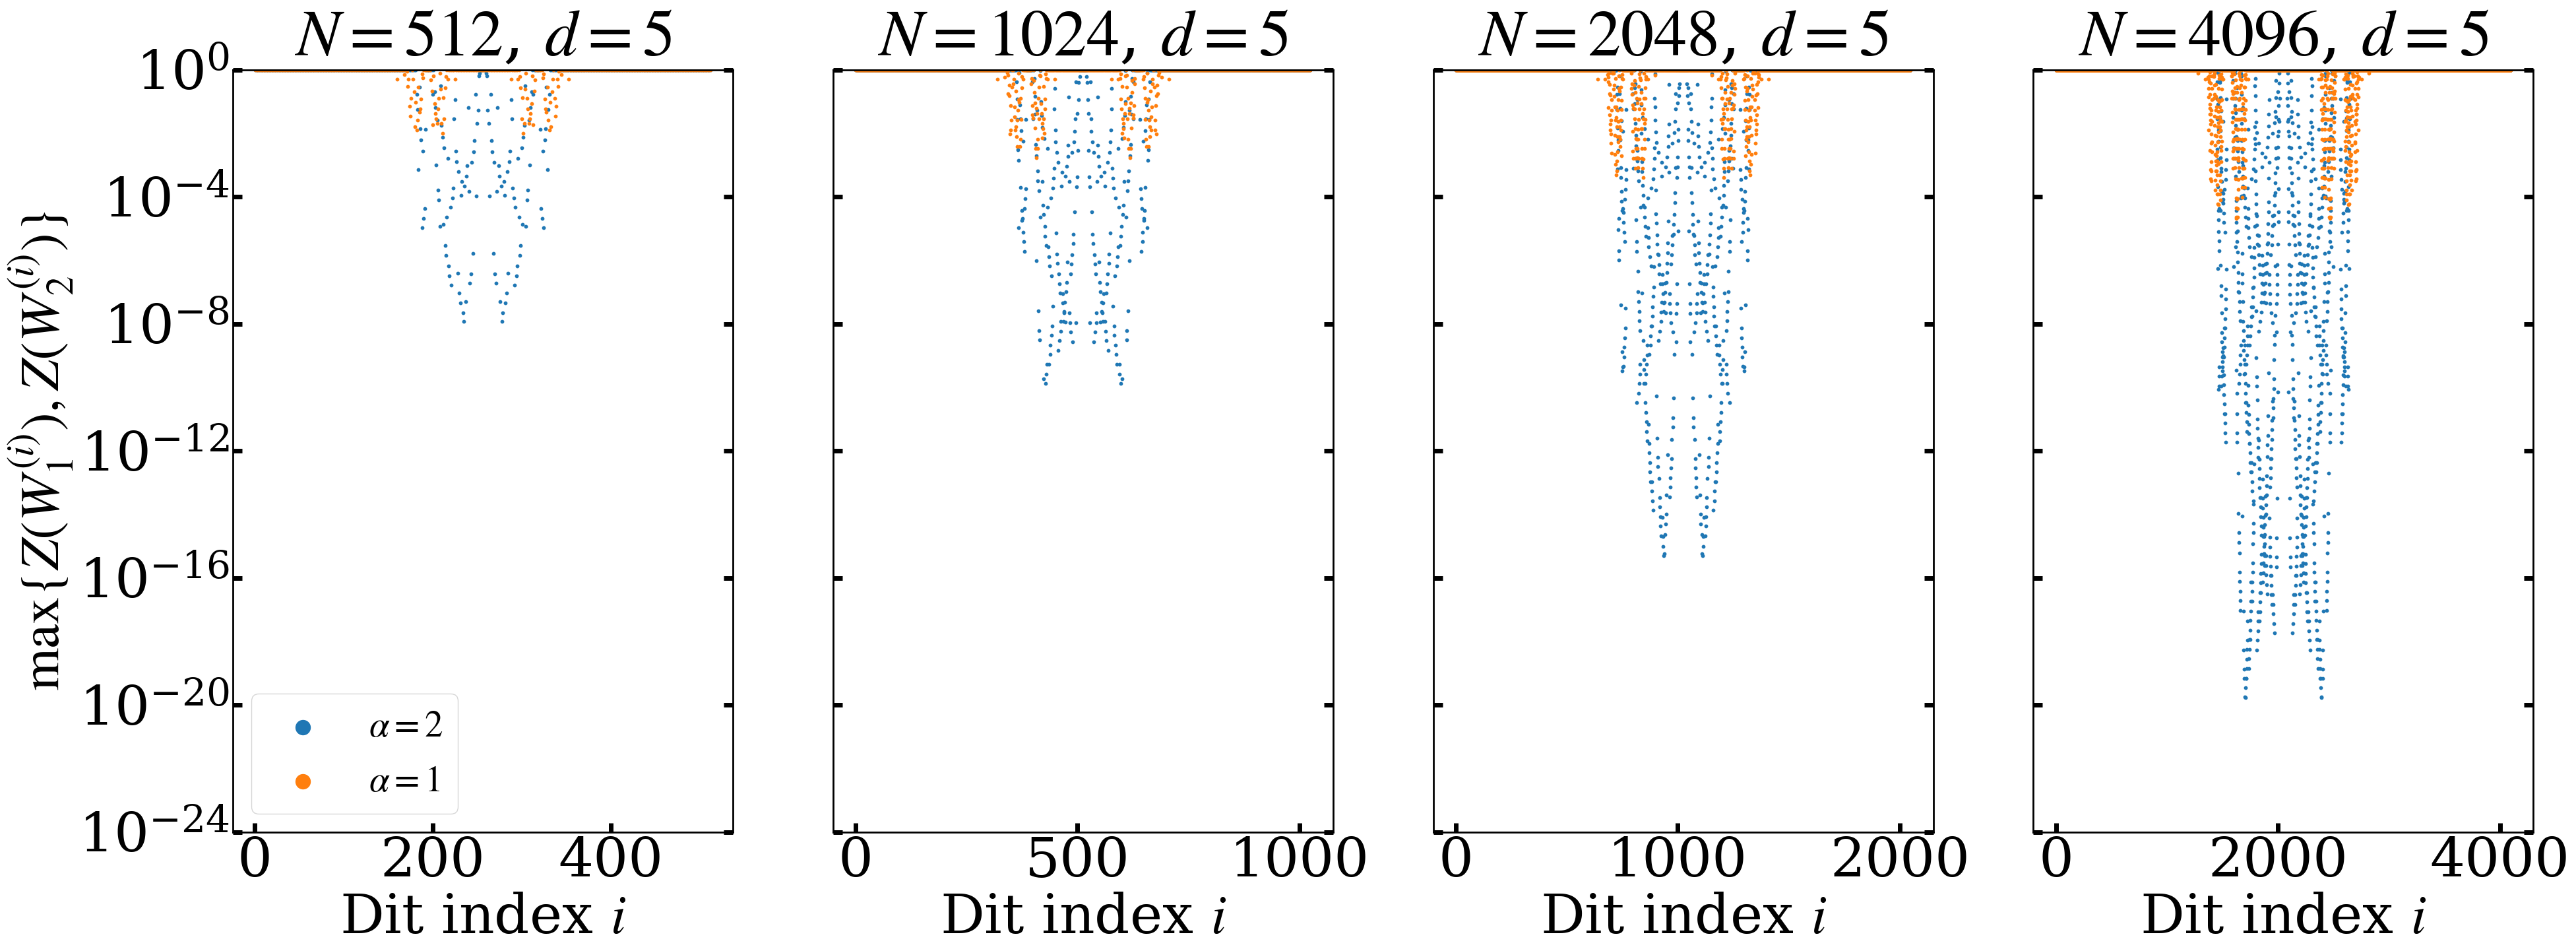

In [592]:
pin = 1

Z1 = np.log(estimate_Z_Wi_displ_sq_dGKP_all(5, 2**pin, 0.4, 1024,alpha=1))
Z2 = np.log(estimate_Z_Wi_displ_sq_dGKP_all(5, 2**pin, 0.4, 1024,alpha=2))

for i in range(8-pin):
    Z1 = log_recursive_Zwi_upper_alpha(Z1, 1)
    Z2 = log_recursive_Zwi_upper_alpha(Z2, 2)

sze=10
plt.rcParams["figure.figsize"] = (45,15)

fig, axes = plt.subplots(1, 4, sharey=True)

Z1 = log_recursive_Zwi_upper_alpha(Z1, 1)
Z2 = log_recursive_Zwi_upper_alpha(Z2, 2)

N = len(Z1[0,:])
ZX = np.mean(np.exp(Z2[1:,:]),axis=0)
axes[0].set_title('$N ='+str(N)+' $, $d=5$')
axes[0].scatter(range(1,N+1),np.maximum(ZX,np.flip(ZX)),s=sze,label=r'$\alpha = 2$')

ZX = np.mean(np.exp(Z1[1:,:]),axis=0)
axes[0].scatter(range(1,N+1),np.maximum(ZX,np.flip(ZX)),s=sze,label=r'$\alpha = 1$')
axes[0].legend(markerscale=5)

Z1 = log_recursive_Zwi_upper_alpha(Z1, 1)
Z2 = log_recursive_Zwi_upper_alpha(Z2, 2)

N = len(Z1[0,:])
ZX = np.mean(np.exp(Z2[1:,:]),axis=0)
axes[1].set_title('$N ='+str(N)+' $, $d=5$')
axes[1].scatter(range(1,N+1),np.maximum(ZX,np.flip(ZX)),s=sze,label=r'$\alpha = 2$')

ZX = np.mean(np.exp(Z1[1:,:]),axis=0)
axes[1].scatter(range(1,N+1),np.maximum(ZX,np.flip(ZX)),s=sze,label=r'$\alpha = 1$')
#axes[1].legend(markerscale=5)

Z1 = log_recursive_Zwi_upper_alpha(Z1, 1)
Z2 = log_recursive_Zwi_upper_alpha(Z2, 2)

N = len(Z1[0,:])
ZX = np.mean(np.exp(Z2[1:,:]),axis=0)
axes[2].set_title('$N ='+str(N)+' $, $d=5$')
axes[2].scatter(range(1,N+1),np.maximum(ZX,np.flip(ZX)),s=sze,label=r'$\alpha = 2$')

ZX = np.mean(np.exp(Z1[1:,:]),axis=0)
axes[2].scatter(range(1,N+1),np.maximum(ZX,np.flip(ZX)),s=sze,label=r'$\alpha = 1$')
#axes[2].legend(markerscale=5)

Z1 = log_recursive_Zwi_upper_alpha(Z1, 1)
Z2 = log_recursive_Zwi_upper_alpha(Z2, 2)

N = len(Z1[0,:])
ZX = np.mean(np.exp(Z2[1:,:]),axis=0)
axes[3].set_title('$N ='+str(N)+' $, $d=5$')
axes[3].scatter(range(1,N+1),np.maximum(ZX,np.flip(ZX)),s=sze,label=r'$\alpha = 2$')

ZX = np.mean(np.exp(Z1[1:,:]),axis=0)
axes[3].scatter(range(1,N+1),np.maximum(ZX,np.flip(ZX)),s=sze,label=r'$\alpha = 1$')
#axes[3].legend(markerscale=5)

axes[0].set_ylabel(r'$\max\{Z(W_1^{(i)}),Z(W_2^{(i)})\}$')
for i in range(4):
    axes[i].tick_params(axis='y', direction='in',width=5,length=10,right=True)
    axes[i].tick_params(axis='x', direction='in',width=5,length=10)
    axes[i].set_xlabel(r'Dit index $i$')
plt.yscale('log')
plt.ylim(1e-24,1)

(1e-24, 1)

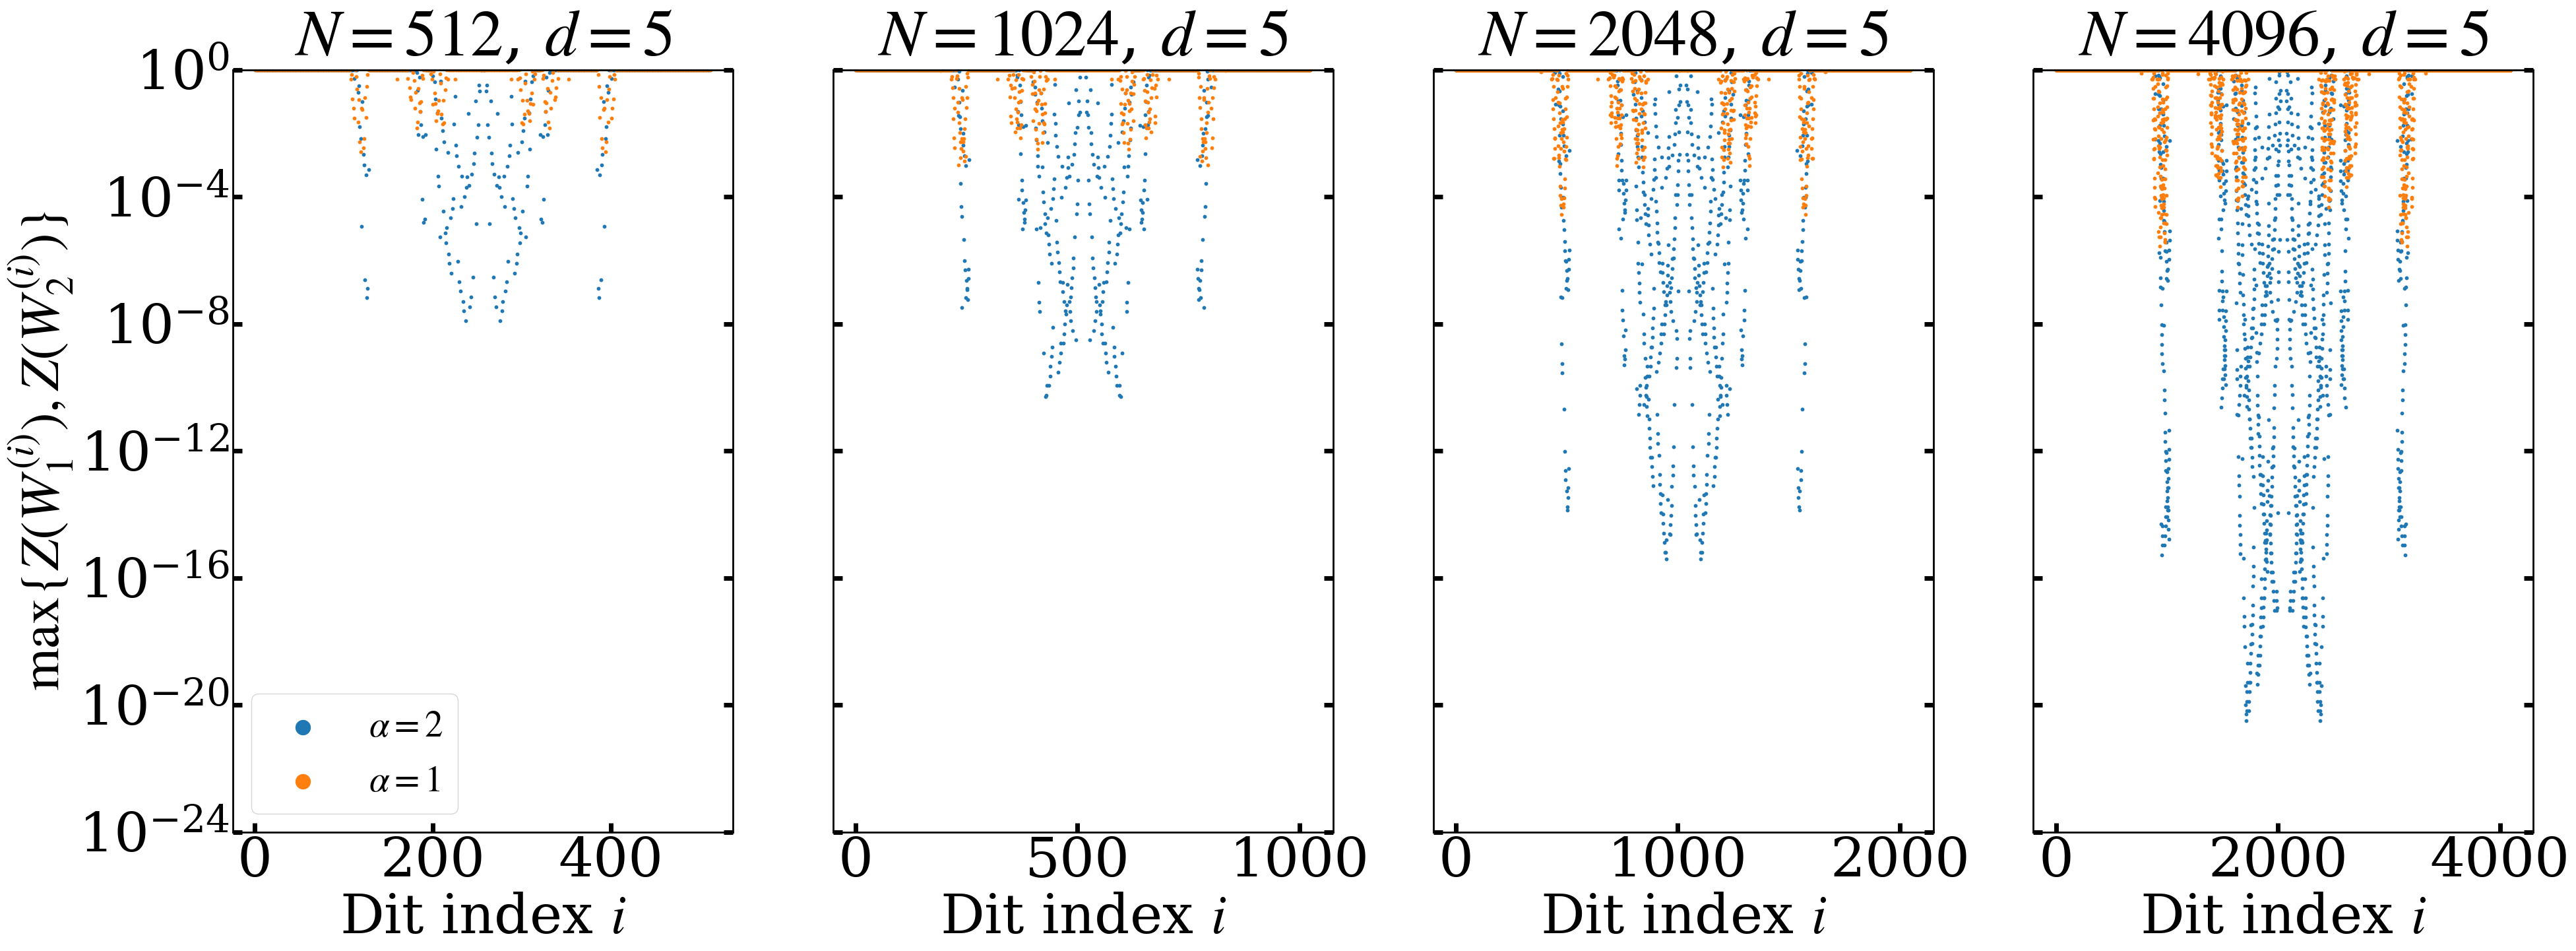

In [591]:
pin = 2

Z1 = np.log(estimate_Z_Wi_displ_sq_dGKP_all(5, 2**pin, 0.4, 1024,alpha=1))
Z2 = np.log(estimate_Z_Wi_displ_sq_dGKP_all(5, 2**pin, 0.4, 1024,alpha=2))

for i in range(8-pin):
    Z1 = log_recursive_Zwi_upper_alpha(Z1, 1)
    Z2 = log_recursive_Zwi_upper_alpha(Z2, 2)

sze=10
plt.rcParams["figure.figsize"] = (45,15)

fig, axes = plt.subplots(1, 4, sharey=True)

Z1 = log_recursive_Zwi_upper_alpha(Z1, 1)
Z2 = log_recursive_Zwi_upper_alpha(Z2, 2)

N = len(Z1[0,:])
ZX = np.mean(np.exp(Z2[1:,:]),axis=0)
axes[0].set_title('$N ='+str(N)+' $, $d=5$')
axes[0].scatter(range(1,N+1),np.maximum(ZX,np.flip(ZX)),s=sze,label=r'$\alpha = 2$')

ZX = np.mean(np.exp(Z1[1:,:]),axis=0)
axes[0].scatter(range(1,N+1),np.maximum(ZX,np.flip(ZX)),s=sze,label=r'$\alpha = 1$')
axes[0].legend(markerscale=5)

Z1 = log_recursive_Zwi_upper_alpha(Z1, 1)
Z2 = log_recursive_Zwi_upper_alpha(Z2, 2)

N = len(Z1[0,:])
ZX = np.mean(np.exp(Z2[1:,:]),axis=0)
axes[1].set_title('$N ='+str(N)+' $, $d=5$')
axes[1].scatter(range(1,N+1),np.maximum(ZX,np.flip(ZX)),s=sze,label=r'$\alpha = 2$')

ZX = np.mean(np.exp(Z1[1:,:]),axis=0)
axes[1].scatter(range(1,N+1),np.maximum(ZX,np.flip(ZX)),s=sze,label=r'$\alpha = 1$')
#axes[1].legend(markerscale=5)

Z1 = log_recursive_Zwi_upper_alpha(Z1, 1)
Z2 = log_recursive_Zwi_upper_alpha(Z2, 2)

N = len(Z1[0,:])
ZX = np.mean(np.exp(Z2[1:,:]),axis=0)
axes[2].set_title('$N ='+str(N)+' $, $d=5$')
axes[2].scatter(range(1,N+1),np.maximum(ZX,np.flip(ZX)),s=sze,label=r'$\alpha = 2$')

ZX = np.mean(np.exp(Z1[1:,:]),axis=0)
axes[2].scatter(range(1,N+1),np.maximum(ZX,np.flip(ZX)),s=sze,label=r'$\alpha = 1$')
#axes[2].legend(markerscale=5)

Z1 = log_recursive_Zwi_upper_alpha(Z1, 1)
Z2 = log_recursive_Zwi_upper_alpha(Z2, 2)

N = len(Z1[0,:])
ZX = np.mean(np.exp(Z2[1:,:]),axis=0)
axes[3].set_title('$N ='+str(N)+' $, $d=5$')
axes[3].scatter(range(1,N+1),np.maximum(ZX,np.flip(ZX)),s=sze,label=r'$\alpha = 2$')

ZX = np.mean(np.exp(Z1[1:,:]),axis=0)
axes[3].scatter(range(1,N+1),np.maximum(ZX,np.flip(ZX)),s=sze,label=r'$\alpha = 1$')
#axes[3].legend(markerscale=5)

axes[0].set_ylabel(r'$\max\{Z(W_1^{(i)}),Z(W_2^{(i)})\}$')
for i in range(4):
    axes[i].tick_params(axis='y', direction='in',width=5,length=10,right=True)
    axes[i].tick_params(axis='x', direction='in',width=5,length=10)
    axes[i].set_xlabel(r'Dit index $i$')
plt.yscale('log')
plt.ylim(1e-24,1)

(1e-24, 1)

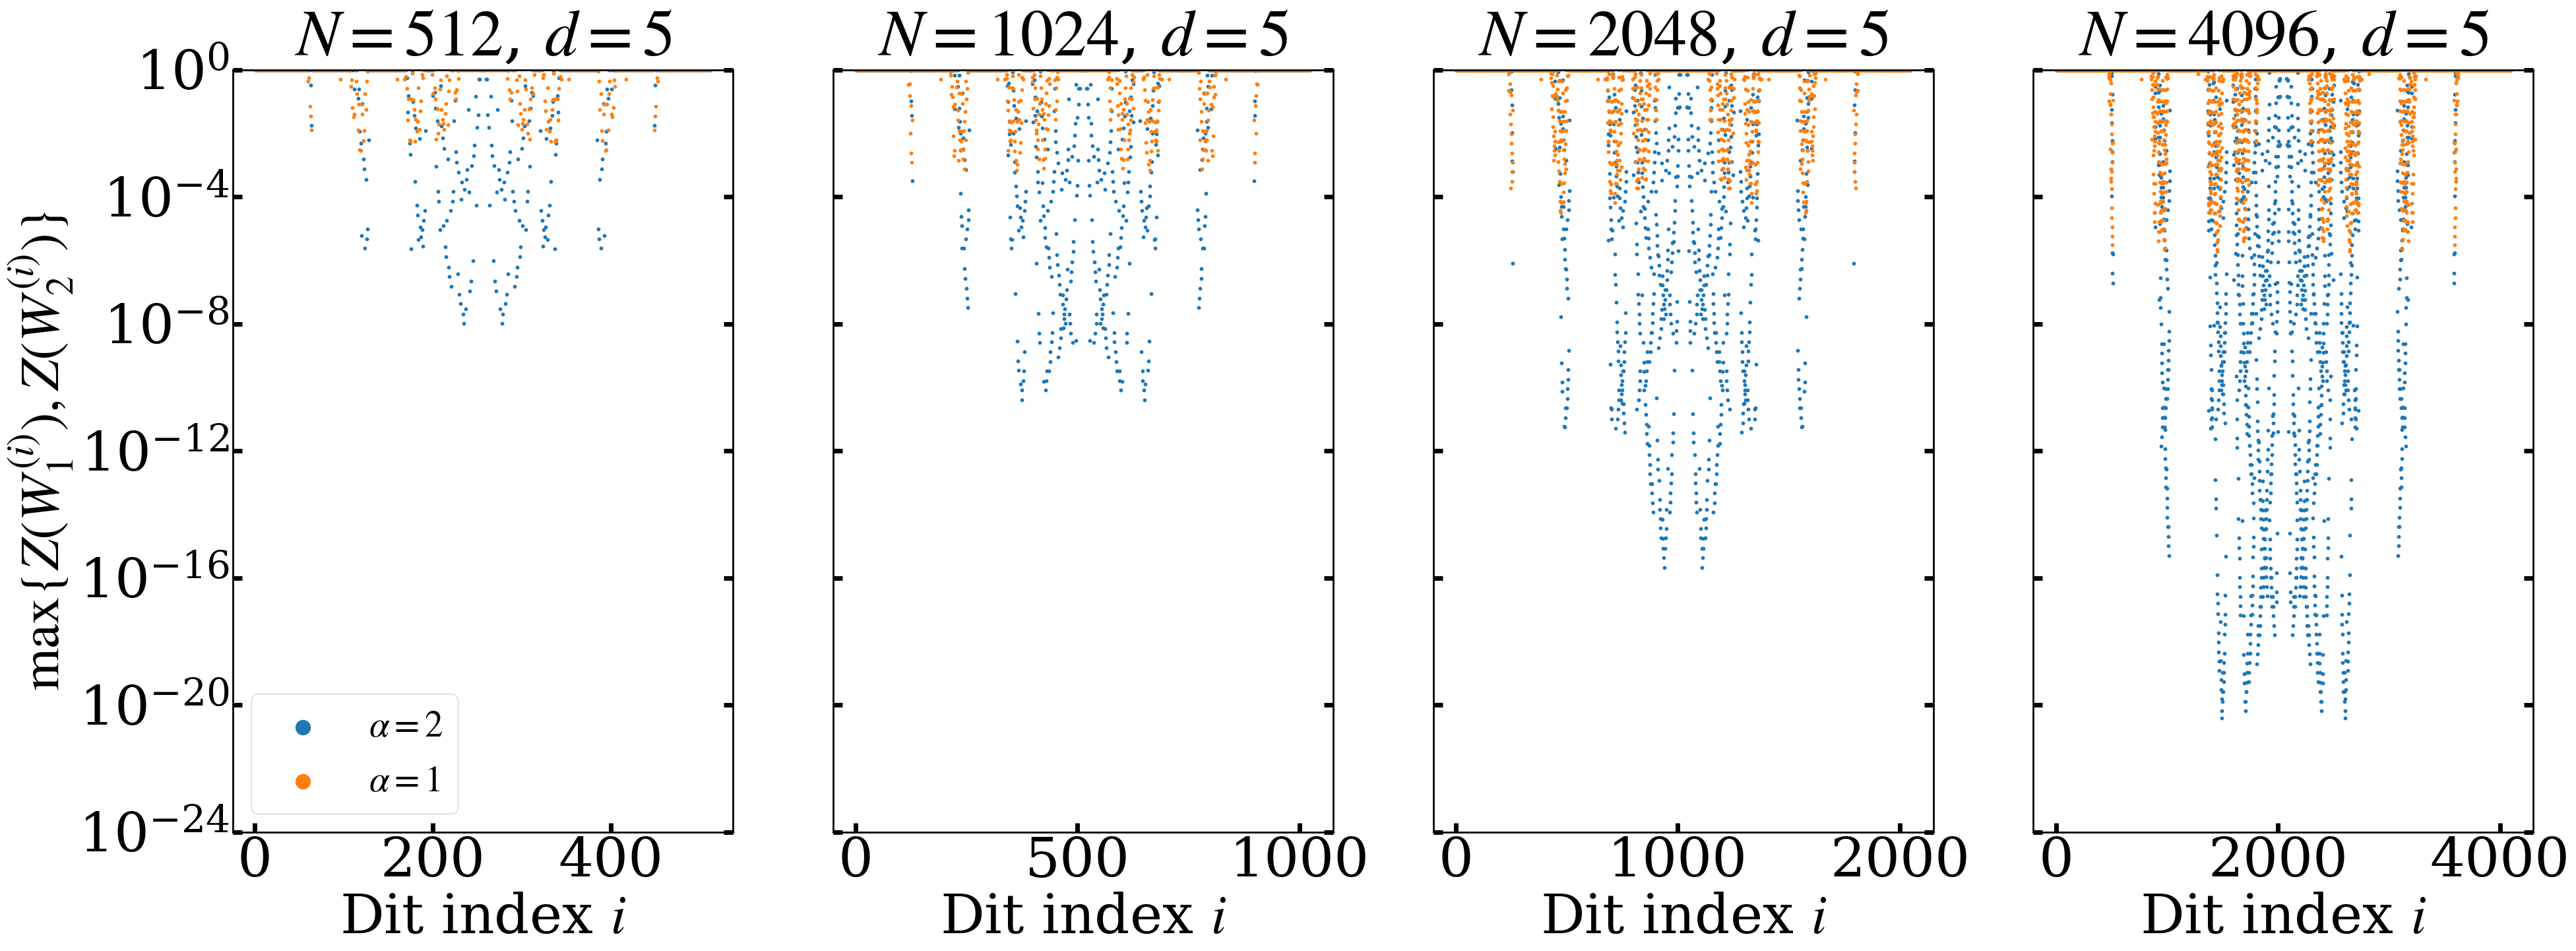

In [498]:
n_mc = 3
samples = 2**16

Zw = np.log(np.array([[scipy.integrate.quad(lambda s: Z_w_integrand(s,5,i,0.4),-1/2,1/2)[0]] for i in range(5)]))
Zw1 = Zw
Zw2 = Zw

for i in range(n_mc):
    Zw1 = log_recursive_Zwi_upper_alpha(Zw1, 1)
    Zw2 = log_recursive_Zwi_upper_alpha(Zw2, 2)
Z1 = np.log(estimate_Z_Wi_displ_sq_dGKP_all(5, 2**n_mc, 0.4, samples, alpha=1))
Z1[:,-1] = Zw1[:,-1]
Z2 = np.log(estimate_Z_Wi_displ_sq_dGKP_all(5, 2**n_mc, 0.4, samples, alpha=2))
Z2[:,-1] = Zw2[:,-1]


for i in range(8-n_mc):
    Z1 = log_recursive_Zwi_upper_alpha(Z1, 1)
    Z2 = log_recursive_Zwi_upper_alpha(Z2, 2)

sze=10
plt.rcParams["figure.figsize"] = (45,15)

fig, axes = plt.subplots(1, 4, sharey=True)

Z1 = log_recursive_Zwi_upper_alpha(Z1, 1)
Z2 = log_recursive_Zwi_upper_alpha(Z2, 2)

N = len(Z1[0,:])
ZX = np.mean(np.exp(Z2[1:,:]),axis=0)
axes[0].set_title('$N ='+str(N)+' $, $d=5$')
axes[0].scatter(range(1,N+1),np.maximum(ZX,np.flip(ZX)),s=sze,label=r'$\alpha = 2$')

ZX = np.mean(np.exp(Z1[1:,:]),axis=0)
axes[0].scatter(range(1,N+1),np.maximum(ZX,np.flip(ZX)),s=sze,label=r'$\alpha = 1$')
axes[0].legend(markerscale=5)

Z1 = log_recursive_Zwi_upper_alpha(Z1, 1)
Z2 = log_recursive_Zwi_upper_alpha(Z2, 2)

N = len(Z1[0,:])
ZX = np.mean(np.exp(Z2[1:,:]),axis=0)
axes[1].set_title('$N ='+str(N)+' $, $d=5$')
axes[1].scatter(range(1,N+1),np.maximum(ZX,np.flip(ZX)),s=sze,label=r'$\alpha = 2$')

ZX = np.mean(np.exp(Z1[1:,:]),axis=0)
axes[1].scatter(range(1,N+1),np.maximum(ZX,np.flip(ZX)),s=sze,label=r'$\alpha = 1$')
#axes[1].legend(markerscale=5)

Z1 = log_recursive_Zwi_upper_alpha(Z1, 1)
Z2 = log_recursive_Zwi_upper_alpha(Z2, 2)

N = len(Z1[0,:])
ZX = np.mean(np.exp(Z2[1:,:]),axis=0)
axes[2].set_title('$N ='+str(N)+' $, $d=5$')
axes[2].scatter(range(1,N+1),np.maximum(ZX,np.flip(ZX)),s=sze,label=r'$\alpha = 2$')

ZX = np.mean(np.exp(Z1[1:,:]),axis=0)
axes[2].scatter(range(1,N+1),np.maximum(ZX,np.flip(ZX)),s=sze,label=r'$\alpha = 1$')
#axes[2].legend(markerscale=5)

Z1 = log_recursive_Zwi_upper_alpha(Z1, 1)
Z2 = log_recursive_Zwi_upper_alpha(Z2, 2)

N = len(Z1[0,:])
ZX = np.mean(np.exp(Z2[1:,:]),axis=0)
axes[3].set_title('$N ='+str(N)+' $, $d=5$')
axes[3].scatter(range(1,N+1),np.maximum(ZX,np.flip(ZX)),s=sze,label=r'$\alpha = 2$')

ZX = np.mean(np.exp(Z1[1:,:]),axis=0)
axes[3].scatter(range(1,N+1),np.maximum(ZX,np.flip(ZX)),s=sze,label=r'$\alpha = 1$')
#axes[3].legend(markerscale=5)

axes[0].set_ylabel(r'$\max\{Z(W_1^{(i)}),Z(W_2^{(i)})\}$')
for i in range(4):
    axes[i].tick_params(axis='y', direction='in',width=5,length=10,right=True)
    axes[i].tick_params(axis='x', direction='in',width=5,length=10)
    axes[i].set_xlabel(r'Dit index $i$')
plt.yscale('log')
plt.ylim(1e-24,1)

(1e-24, 1)

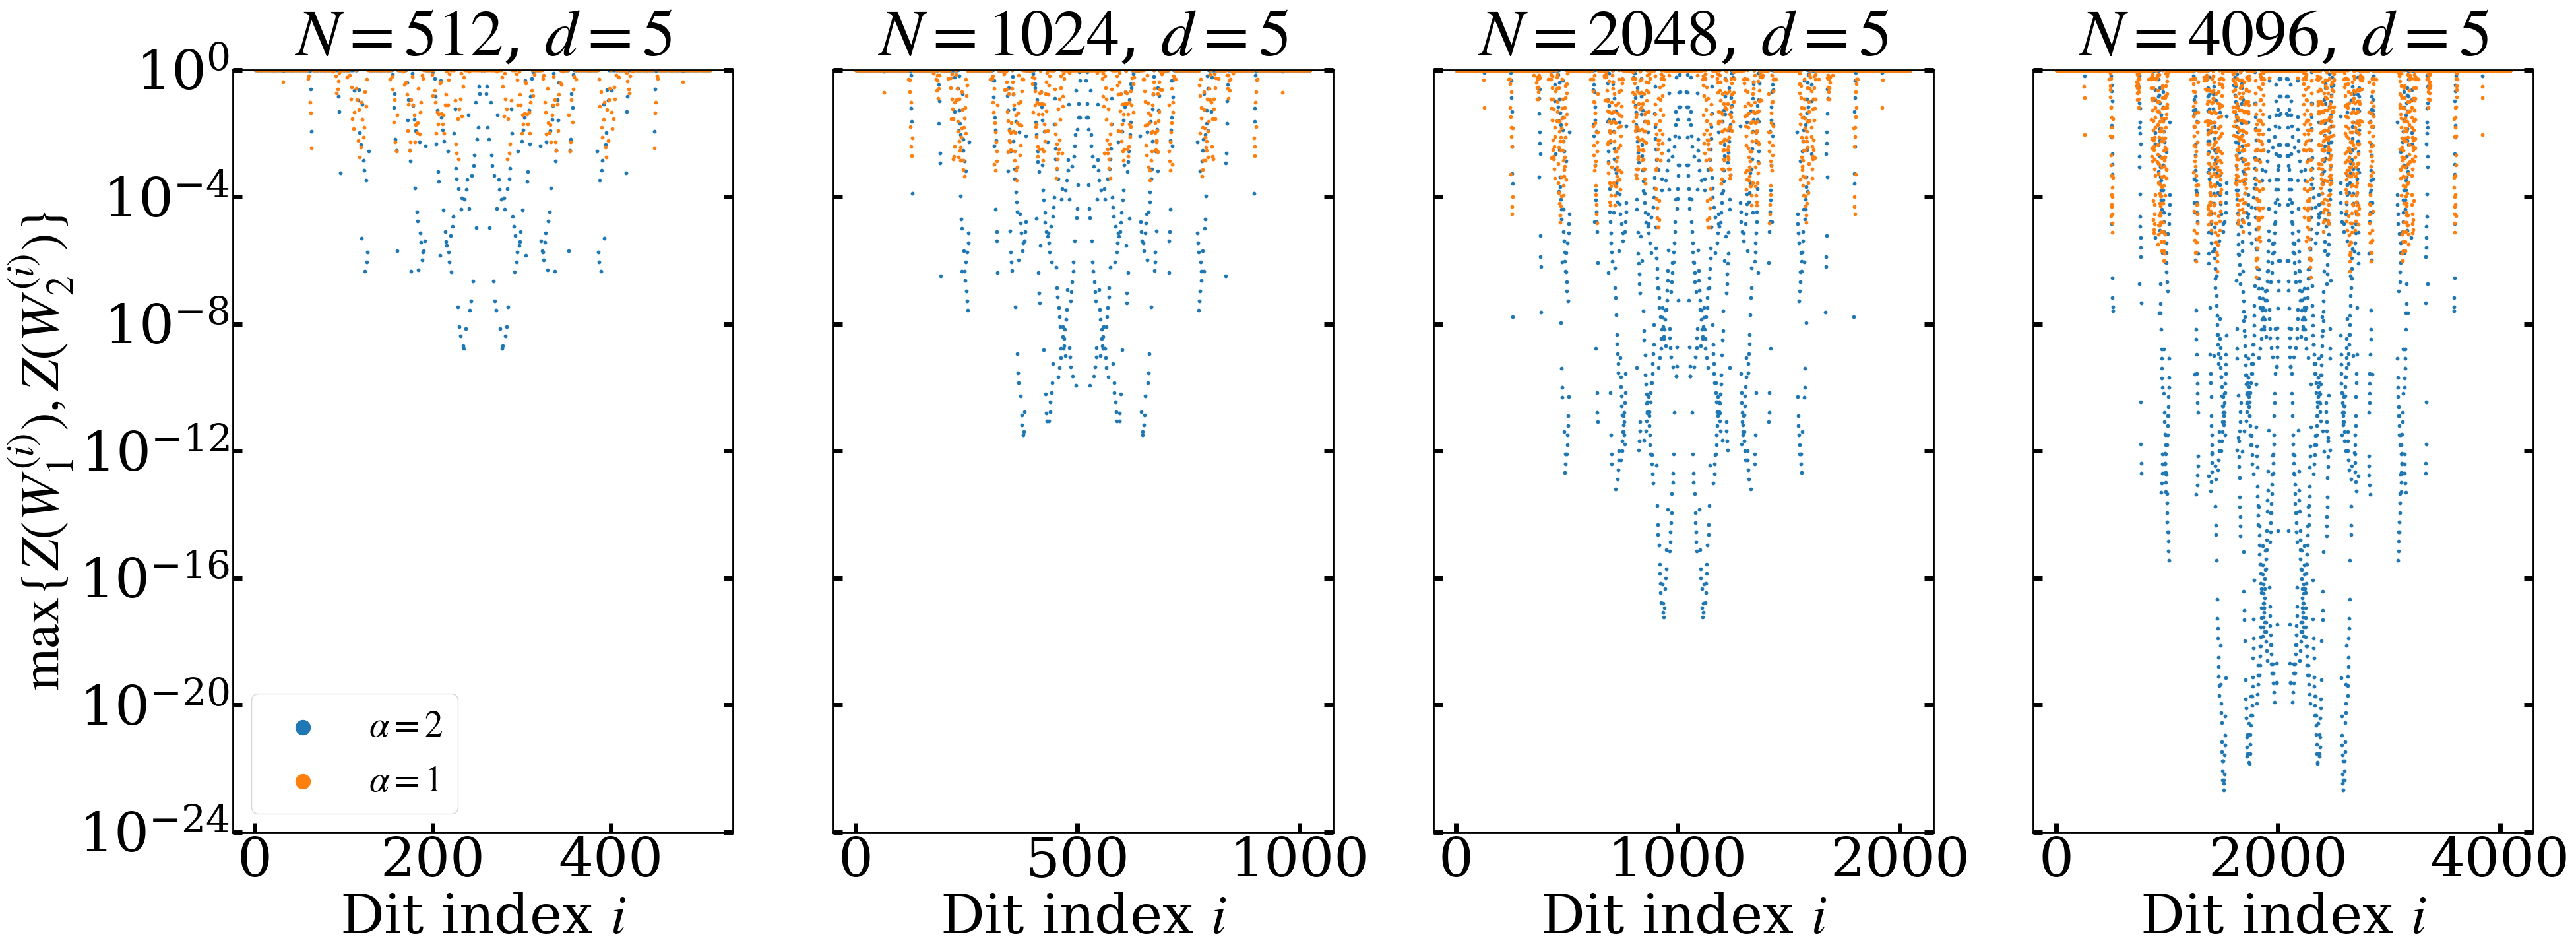

In [593]:
pin = 4

Z1 = np.log(estimate_Z_Wi_displ_sq_dGKP_all(5, 2**pin, 0.4, 1024,alpha=1))
Z2 = np.log(estimate_Z_Wi_displ_sq_dGKP_all(5, 2**pin, 0.4, 1024,alpha=2))

for i in range(8-pin):
    Z1 = log_recursive_Zwi_upper_alpha(Z1, 1)
    Z2 = log_recursive_Zwi_upper_alpha(Z2, 2)

sze=10
plt.rcParams["figure.figsize"] = (45,15)

fig, axes = plt.subplots(1, 4, sharey=True)

Z1 = log_recursive_Zwi_upper_alpha(Z1, 1)
Z2 = log_recursive_Zwi_upper_alpha(Z2, 2)

N = len(Z1[0,:])
ZX = np.mean(np.exp(Z2[1:,:]),axis=0)
axes[0].set_title('$N ='+str(N)+' $, $d=5$')
axes[0].scatter(range(1,N+1),np.maximum(ZX,np.flip(ZX)),s=sze,label=r'$\alpha = 2$')

ZX = np.mean(np.exp(Z1[1:,:]),axis=0)
axes[0].scatter(range(1,N+1),np.maximum(ZX,np.flip(ZX)),s=sze,label=r'$\alpha = 1$')
axes[0].legend(markerscale=5)

Z1 = log_recursive_Zwi_upper_alpha(Z1, 1)
Z2 = log_recursive_Zwi_upper_alpha(Z2, 2)

N = len(Z1[0,:])
ZX = np.mean(np.exp(Z2[1:,:]),axis=0)
axes[1].set_title('$N ='+str(N)+' $, $d=5$')
axes[1].scatter(range(1,N+1),np.maximum(ZX,np.flip(ZX)),s=sze,label=r'$\alpha = 2$')

ZX = np.mean(np.exp(Z1[1:,:]),axis=0)
axes[1].scatter(range(1,N+1),np.maximum(ZX,np.flip(ZX)),s=sze,label=r'$\alpha = 1$')
#axes[1].legend(markerscale=5)

Z1 = log_recursive_Zwi_upper_alpha(Z1, 1)
Z2 = log_recursive_Zwi_upper_alpha(Z2, 2)

N = len(Z1[0,:])
ZX = np.mean(np.exp(Z2[1:,:]),axis=0)
axes[2].set_title('$N ='+str(N)+' $, $d=5$')
axes[2].scatter(range(1,N+1),np.maximum(ZX,np.flip(ZX)),s=sze,label=r'$\alpha = 2$')

ZX = np.mean(np.exp(Z1[1:,:]),axis=0)
axes[2].scatter(range(1,N+1),np.maximum(ZX,np.flip(ZX)),s=sze,label=r'$\alpha = 1$')
#axes[2].legend(markerscale=5)

Z1 = log_recursive_Zwi_upper_alpha(Z1, 1)
Z2 = log_recursive_Zwi_upper_alpha(Z2, 2)

N = len(Z1[0,:])
ZX = np.mean(np.exp(Z2[1:,:]),axis=0)
axes[3].set_title('$N ='+str(N)+' $, $d=5$')
axes[3].scatter(range(1,N+1),np.maximum(ZX,np.flip(ZX)),s=sze,label=r'$\alpha = 2$')

ZX = np.mean(np.exp(Z1[1:,:]),axis=0)
axes[3].scatter(range(1,N+1),np.maximum(ZX,np.flip(ZX)),s=sze,label=r'$\alpha = 1$')
#axes[3].legend(markerscale=5)

axes[0].set_ylabel(r'$\max\{Z(W_1^{(i)}),Z(W_2^{(i)})\}$')
for i in range(4):
    axes[i].tick_params(axis='y', direction='in',width=5,length=10,right=True)
    axes[i].tick_params(axis='x', direction='in',width=5,length=10)
    axes[i].set_xlabel(r'Dit index $i$')
plt.yscale('log')
plt.ylim(1e-24,1)

In [303]:
def get_rates_mc(d, alpha, sig, n_mc, n_low, n_high, samples=2**16):
    N = [2**i for i in range(n_low, n_high+1)]
    rate = []
    pe = []
    Zw = np.log(np.array([[scipy.integrate.quad(lambda s: Z_w_integrand(s,d,i,sig),-1/2,1/2)[0]] for i in range(d)]))
    for i in range(n_mc):
        Zw = log_recursive_Zwi_upper_alpha(Zw, alpha)
    Z = np.log(estimate_Z_Wi_displ_sq_dGKP_all(d, 2**n_mc, sig, samples,alpha=alpha))
    Z[:,-1] = Zw[:,-1]

    for i in range(n_low-n_mc-1):
        Z = log_recursive_Zwi_upper_alpha(Z, alpha)
    
    for n in N:
        Z = log_recursive_Zwi_upper_alpha(Z, alpha)
        Zsum = np.sort(scipy.special.logsumexp(Z[1:,:],axis=0))
        px = -np.inf
        count1 = 0
        for i in range(n):
            if np.exp(px) >= 0.5*(1/4)**(np.log2(n)/9):
                break
            px = np.logaddexp(px,Zsum[i])
            count1 += 1
        pe.append(px)
        rate.append(max(0,(count1+count1)/len(Zsum) - 1))

    return rate, pe

In [263]:
Z_int = np.log(np.array([[scipy.integrate.quad(lambda s: Z_w_integrand(s,5,i,0.4),-1/2,1/2)[0]] for i in range(5)]))
Z_mc = np.log(estimate_Z_Wi_displ_sq_dGKP_all(5, 1, 0.4, 30000,2))

In [268]:
Z_8 = np.log(estimate_Z_Wi_displ_sq_dGKP_all(5, 8, 0.4, 30000,2))

In [284]:
Z_8[:,7]

array([  0.        , -22.39759273, -22.4800322 , -22.54429652,
       -23.21999292])

In [285]:
log_recursive_Zwi_upper_alpha(log_recursive_Zwi_upper_alpha(log_recursive_Zwi_upper_alpha(Z_int,2),2),2)[:,7]

array([  0.        , -19.60574693, -19.60574693, -19.60574693,
       -19.60574693])

In [149]:
def get_rates_var(d, alpha, sig, n_low, n_high, tries):
    rate = []
    pe = []
    
    for n in [2**p for p in range(n_low,n_high+1)]:
        pe1 = []
        rate1 = []
        for j in range(tries):
            Z = np.sort(np.exp(np.load('Zdata_var/Z_Wi_sig'+str(sig)+'_'+str(n)+'_d'+str(d)+'_a'+str(alpha)+'_try'+str(j)+'.npy')))
            px = 0.0
            count1 = 0
            for i in range(n):
                if px >= 0.5*(1/4)**(np.log2(n)/9):
                    break
                px += (d-1)*Z[i]
                count1 += 1
            pe1.append(px)
            rate1.append(max(0,(count1+count1)/len(Z) - 1))
        rate.append(rate1)
        pe.append(pe1)

    return np.array(rate), np.array(pe)

In [121]:
rate5_04, pe5_04 = get_rates_var(5, 2, 0.4, 9, 15, 5)
rate7_032, pe7_032 = get_rates_var(7, 2, 0.32, 9, 15, 5)

In [234]:
I_analog_sq = np.load('I_analog_sq_d_2-17.npy')
I_no_analog_sq = np.load('I_no_analog_sq_d_2-17.npy')
colors = ['goldenrod','red','green','purple']
coherent_info = lambda sig: np.log2(1/(sig*sig*np.e))
sig1 = np.linspace(0.1,0.62,1000)

/var/folders/dd/7cnlb81x5cxgmvjv3rvqzp780000gp/T/ipykernel_56132/3653094339.py:18: RuntimeWarning: divide by zero encountered in log2
  plt.plot(sig1,np.log2(np.floor(np.exp2(coherent_info(sig1)))),label=r'Rescaled self-dual',linewidth=6,linestyle='-.')


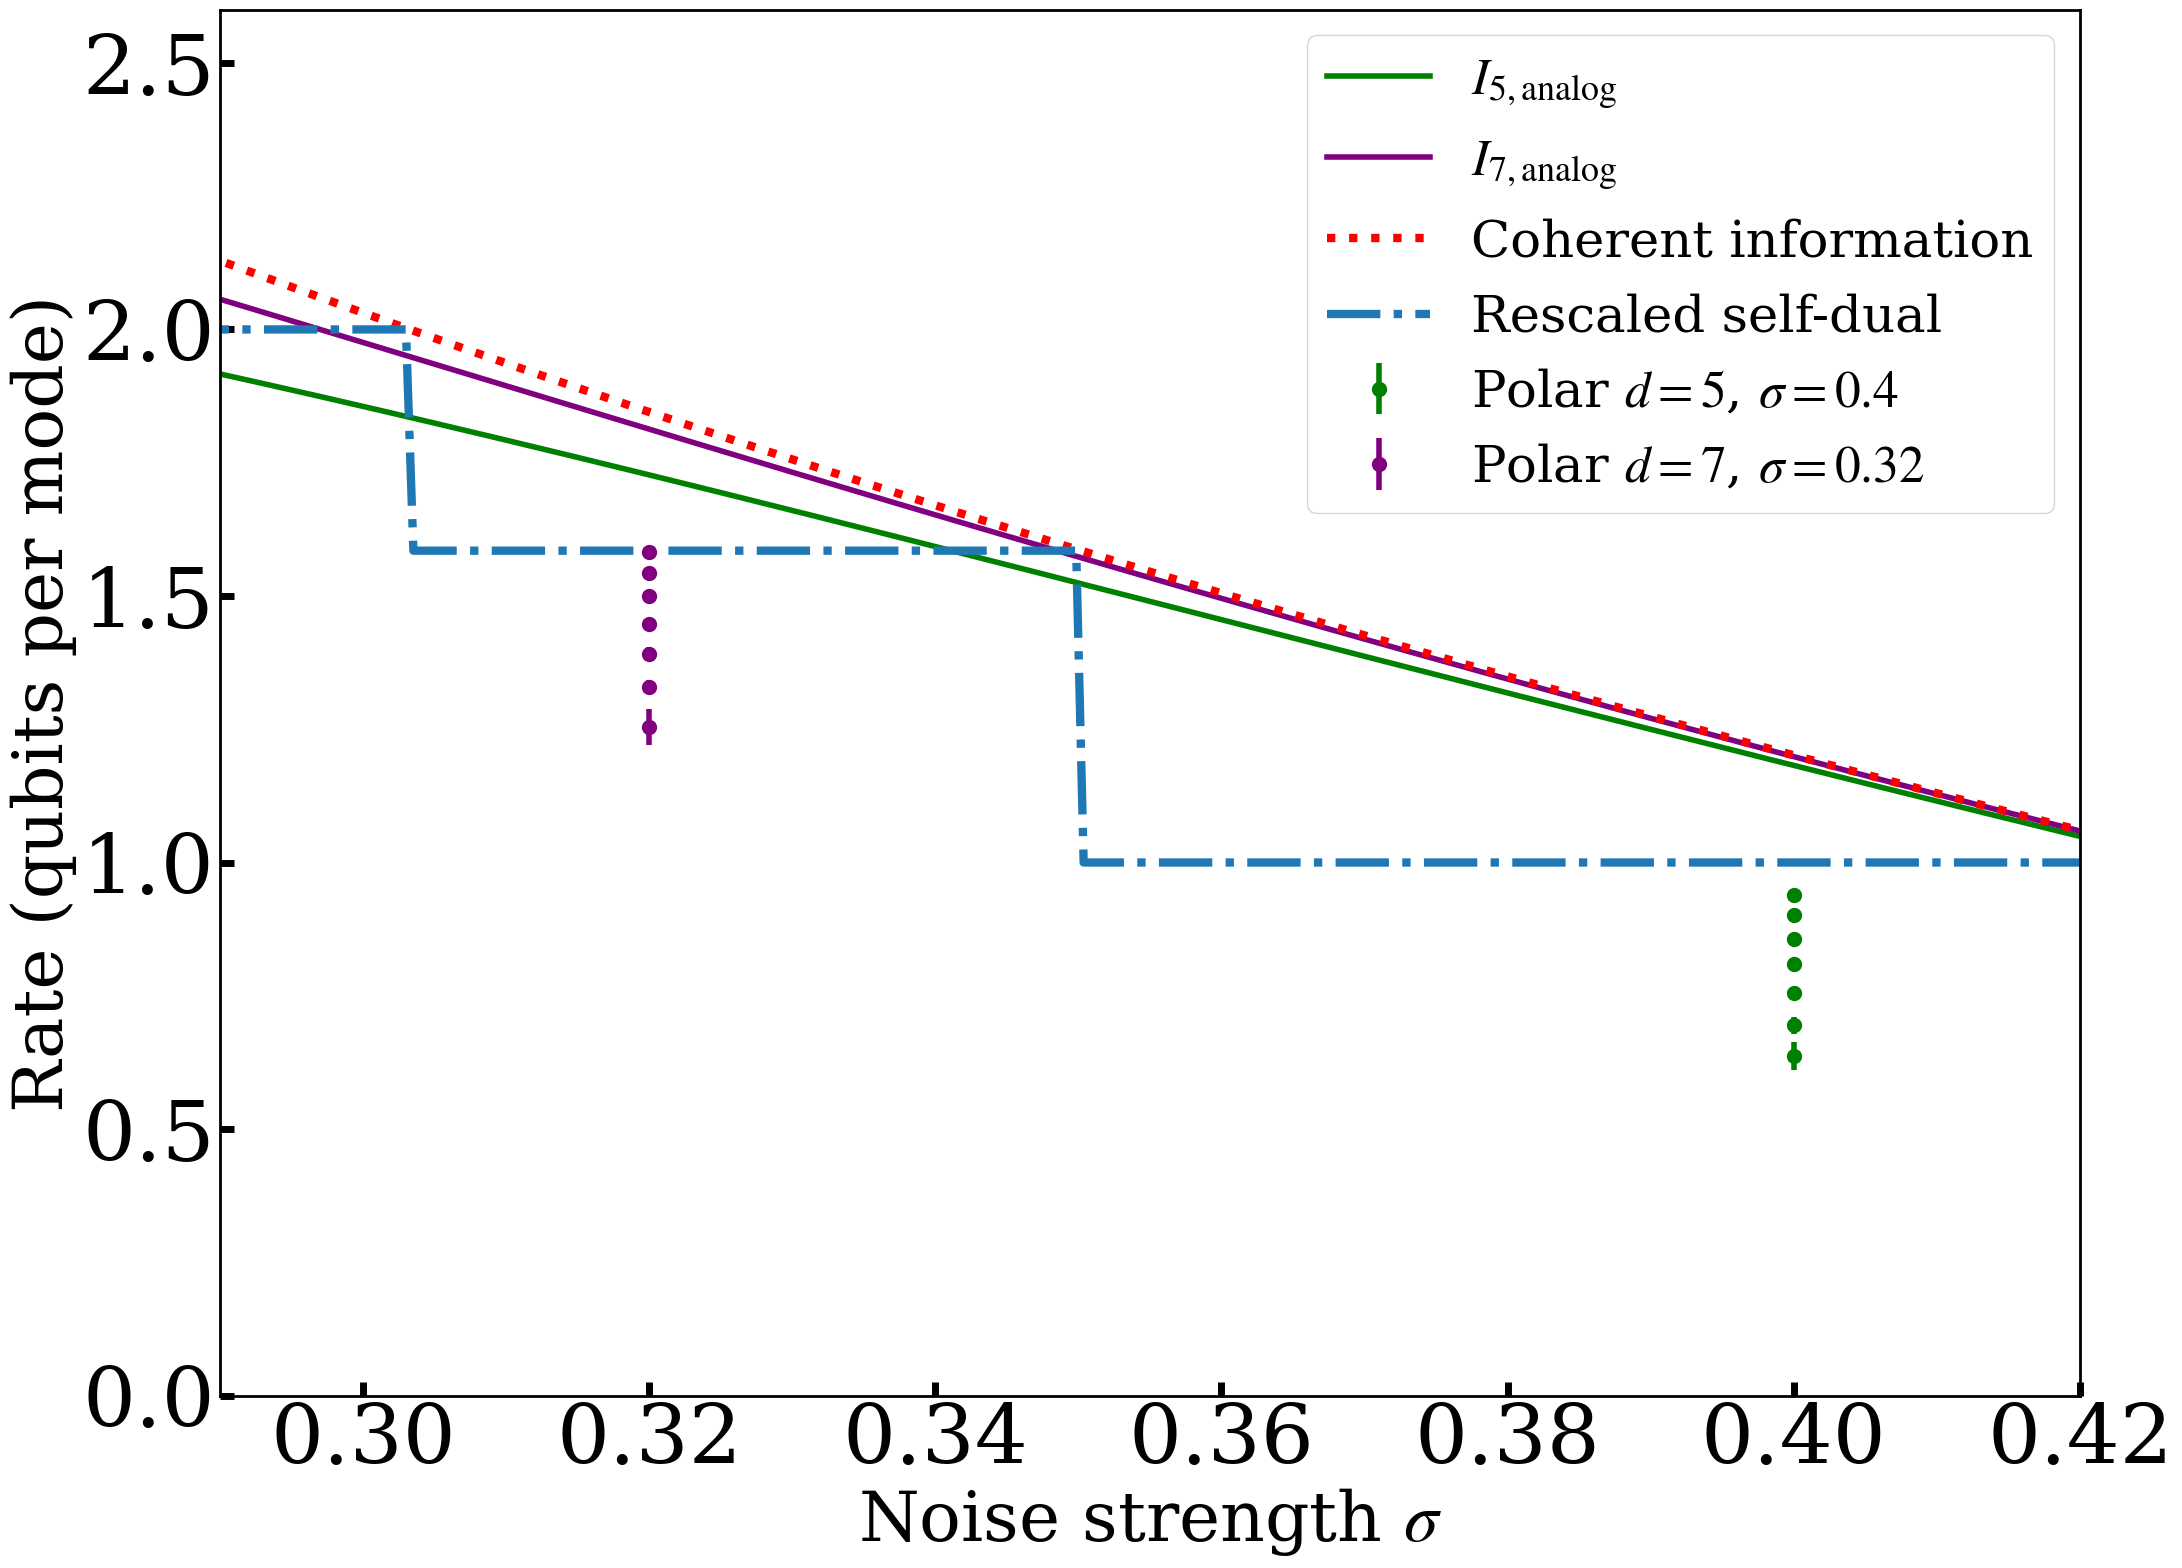

In [235]:
plt.rcParams["figure.figsize"] = (24,18)
#d=2
#plt.plot(sig1, I_analog_sq[0],label=r'$I_{2,\mathrm{analog}}$',color=colors[0],linewidth=4)
#plt.scatter([0.51]*len(rate22),rate22,label=r'Polar $\sigma=0.51$',marker='v',s=300,color=colors[0])
#plt.scatter([0.55]*len(rate),rate,label=r'Polar $\sigma=0.55$',marker='D',s=300,color=colors[0])

#d=5
plt.plot(sig1, I_analog_sq[2],label=r'$I_{5,\mathrm{analog}}$',color=colors[2],linewidth=4)
plt.errorbar(0.4+0*np.mean(rate5_04,axis=1),np.log2(5)*np.mean(rate5_04,axis=1),yerr=3*np.log2(5)*np.std(rate5_04,axis=1),
             fmt='o',markersize=10,color=colors[2],elinewidth=4,label=r'Polar $d=5$, $\sigma=0.4$')

#d=7
plt.plot(sig1, I_analog_sq[3],label=r'$I_{7,\mathrm{analog}}$',color=colors[3],linewidth=4)
plt.errorbar(0.32+0*np.mean(rate7_032,axis=1),np.log2(7)*np.mean(rate7_032,axis=1),yerr=3*np.log2(7)*np.std(rate7_032,axis=1),
             fmt='o',markersize=10,color=colors[3],elinewidth=4,label=r'Polar $d=7$, $\sigma=0.32$')

plt.plot(sig1,coherent_info(sig1),label='Coherent information',linewidth=6,color='red',linestyle='dotted')
plt.plot(sig1,np.log2(np.floor(np.exp2(coherent_info(sig1)))),label=r'Rescaled self-dual',linewidth=6,linestyle='-.')

plt.xlim(0.29,0.42)
plt.ylim(0,2.6)
plt.ylabel('Rate (qubits per mode)',fontsize=50)
plt.xlabel(r'Noise strength $\sigma$',fontsize=50)
plt.tick_params(axis='y', direction='in',width=5,length=10)
plt.tick_params(axis='x', direction='in',width=5,length=10)
plt.legend(fontsize=37,loc=1)

In [291]:
crate511, cpe511 = get_rates_mc(5, 2, 0.4, 3, 9, 22)

print(*cpe511)
print(*crate511)

0.255649729192689 0.14739505742228798 0.06594449545244147 0.022304359898846705 0.003453716445674062 0.00048125460220563646 4.2533327946998585e-05 1.5612931574332155e-06 2.8074818388059664e-08 1.7365633085716972e-10 2.877451497014252e-13 1.0574421996491483e-16 5.536575843813691e-21 2.7097387938841486e-26
0.2421875 0.244140625 0.248046875 0.25146484375 0.2509765625 0.256103515625 0.25994873046875 0.26318359375 0.267181396484375 0.27056121826171875 0.27382659912109375 0.27692413330078125 0.27976322174072266 0.2825603485107422


In [637]:
crate510, cpe510 = get_rates_mc(5, 2, 0.36, 3, 9, 22)

print(*cpe510)
print(*crate510)

0.1407957175752428 0.10758101135612766 0.0933035334801161 0.08240176443168162 0.06787491357244443 0.05828538176050693 0.05030483943679545 0.042621436339465066 0.036693159001510864 0.03127350471747941 0.026865827416261027 0.022973643492137024 0.019690220843973313 0.016888016472893338
0.3515625 0.3671875 0.3798828125 0.39013671875 0.400390625 0.4078369140625 0.41436767578125 0.41986083984375 0.4243316650390625 0.427764892578125 0.4304237365722656 0.4325447082519531 0.4342155456542969 0.43552112579345703


In [629]:
crate521, cpe521 = get_rates_mc(5, 2, 0.5, 3, 9, 22)

print(*cpe521)
print(*crate521)

0.14253622617434772 0.11158174508611111 0.09470090341718483 0.08120137646500111 0.06898807956061406 0.058163657343739746 0.04983592177245643 0.042936340423561016 0.03649229361928084 0.031354180950189534 0.026867083704997817 0.022994631011588898 0.019693193861041933 0.01687956439346352
0 0 0 0 0 0.005126953125 0.01177978515625 0.017669677734375 0.0223541259765625 0.0260772705078125 0.029048919677734375 0.03134346008300781 0.03314208984375 0.034557342529296875


In [292]:
crate7, cpe7 = get_rates_mc(7, 2, 0.32, 3, 9, 22)

print(*cpe7)
print(*crate7)

0.3671474610395921 0.1958767262028935 0.06822946503248975 0.019978181764795964 0.004259373015671695 0.0006460243111258595 4.7911986925918765e-05 1.8959724532060654e-06 3.450089960190621e-08 2.024388105215165e-10 3.230797803706896e-13 1.2035101230224375e-16 6.518003782675135e-21 3.144377881602942e-26
0.421875 0.4296875 0.427734375 0.42919921875 0.430908203125 0.434326171875 0.43719482421875 0.43975830078125 0.4424285888671875 0.444854736328125 0.4474639892578125 0.4498023986816406 0.4518594741821289 0.45398521423339844


In [293]:
crate71, cpe71 = get_rates_mc(7, 2, 0.37, 3, 9, 22)

print(*cpe71)
print(*crate71)

0.20471369691656457 0.24099029285720994 0.07815824570851529 0.021293298850287138 0.0049072102327144 0.0006629580304675884 4.862160133595299e-05 1.9075435768589084e-06 3.3336777859196355e-08 2.0252320179692172e-10 3.322599748154548e-13 1.2638149151787258e-16 6.6924632938209794e-21 3.0808437117756864e-26
0.2734375 0.287109375 0.2822265625 0.2841796875 0.285888671875 0.2890625 0.29107666015625 0.293853759765625 0.29693603515625 0.29923248291015625 0.3017997741699219 0.3042736053466797 0.30640220642089844 0.3085331916809082


In [304]:
crate72, cpe72 = get_rates_mc(7, 2, 0.29, 3, 9, 22)

print(*cpe72)
print(*crate72)

-2.034712989573124 -2.210267803986161 -2.3223008524891995 -2.512465099541002 -2.6953711121424386 -2.8489171753165934 -3.000047718894259 -3.151765080618212 -3.3075327984930296 -3.4628787124307117 -3.617710814902202 -3.7711481702999343 -3.9265250646562833 -4.080630953259501
0.5078125 0.513671875 0.5263671875 0.537109375 0.54541015625 0.5521240234375 0.5576171875 0.561737060546875 0.565093994140625 0.5678863525390625 0.5700531005859375 0.5717105865478516 0.5729770660400391 0.5739631652832031


In [295]:
crate73, cpe73 = get_rates_mc(7, 2, 0.4, 3, 9, 22)

print(*cpe73)
print(*crate73)

0.27010670415116655 0.24943723318620048 0.08665122789317707 0.018659327350535607 0.0057833260050378565 0.0006770516957742155 5.353732078459539e-05 2.0424035838352292e-06 3.805093302379598e-08 2.2991994216730568e-10 3.6363447894502376e-13 1.3838732929450848e-16 7.341958630889155e-21 3.347700938123502e-26
0.1953125 0.203125 0.19921875 0.2001953125 0.20703125 0.20751953125 0.21087646484375 0.21484375 0.2177734375 0.22023773193359375 0.2232208251953125 0.22621917724609375 0.22837257385253906 0.23061370849609375


In [300]:
crate74, cpe74 = get_rates_mc(7, 2, 0.44, 3, 9, 22)

print(*cpe74)
print(*crate74)

0.009631596483302106 0.005837535828364216 0.005380697121368382 0.0034885476318444685 0.001988206288991069 0.0012421994503957173 0.0007039108101752261 0.0004613059569376096 0.00029728111428948374 0.00019244049151883935 0.00011847910475529609 7.176126749059046e-05 4.2796705957508836e-05 2.6433038835604216e-05
0.015625 0.046875 0.0654296875 0.080078125 0.093505859375 0.105712890625 0.1153564453125 0.12353515625 0.1297760009765625 0.13465118408203125 0.1385040283203125 0.1415576934814453 0.14397144317626953 0.1458454132080078


In [297]:
rate,pe = get_rates_mc(2, 1, 0.55, 3, 9, 22)

print(*pe)
print(*rate)

ValueError: could not broadcast input array from shape (2,1) into shape (1,)

In [ ]:
rate22, pe22 = get_rates_mc(2, 1, 0.51, 3, 9, 22)

print(*pe22)
print(*rate22)

0.13264281434734426 0.10902084223552953 0.09504534524963341 0.08039408326048407 0.06811702687698117 0.05816960577211738 0.049916394501318906 0.042725543035743815 0.036563905880204285 0.031310443562176535 0.026791897026693046 0.022985596216410244 0.019698469151614745 0.016881771807874833
0 0 0 0 0 0 0 0 0 0 0 0 0 0


/var/folders/dd/7cnlb81x5cxgmvjv3rvqzp780000gp/T/ipykernel_56132/2123035944.py:22: RuntimeWarning: divide by zero encountered in log2
  plt.plot(sig1,np.log2(np.floor(np.exp2(coherent_info(sig1)))),label=r'Rescaled self-dual',linewidth=6,linestyle='-.')


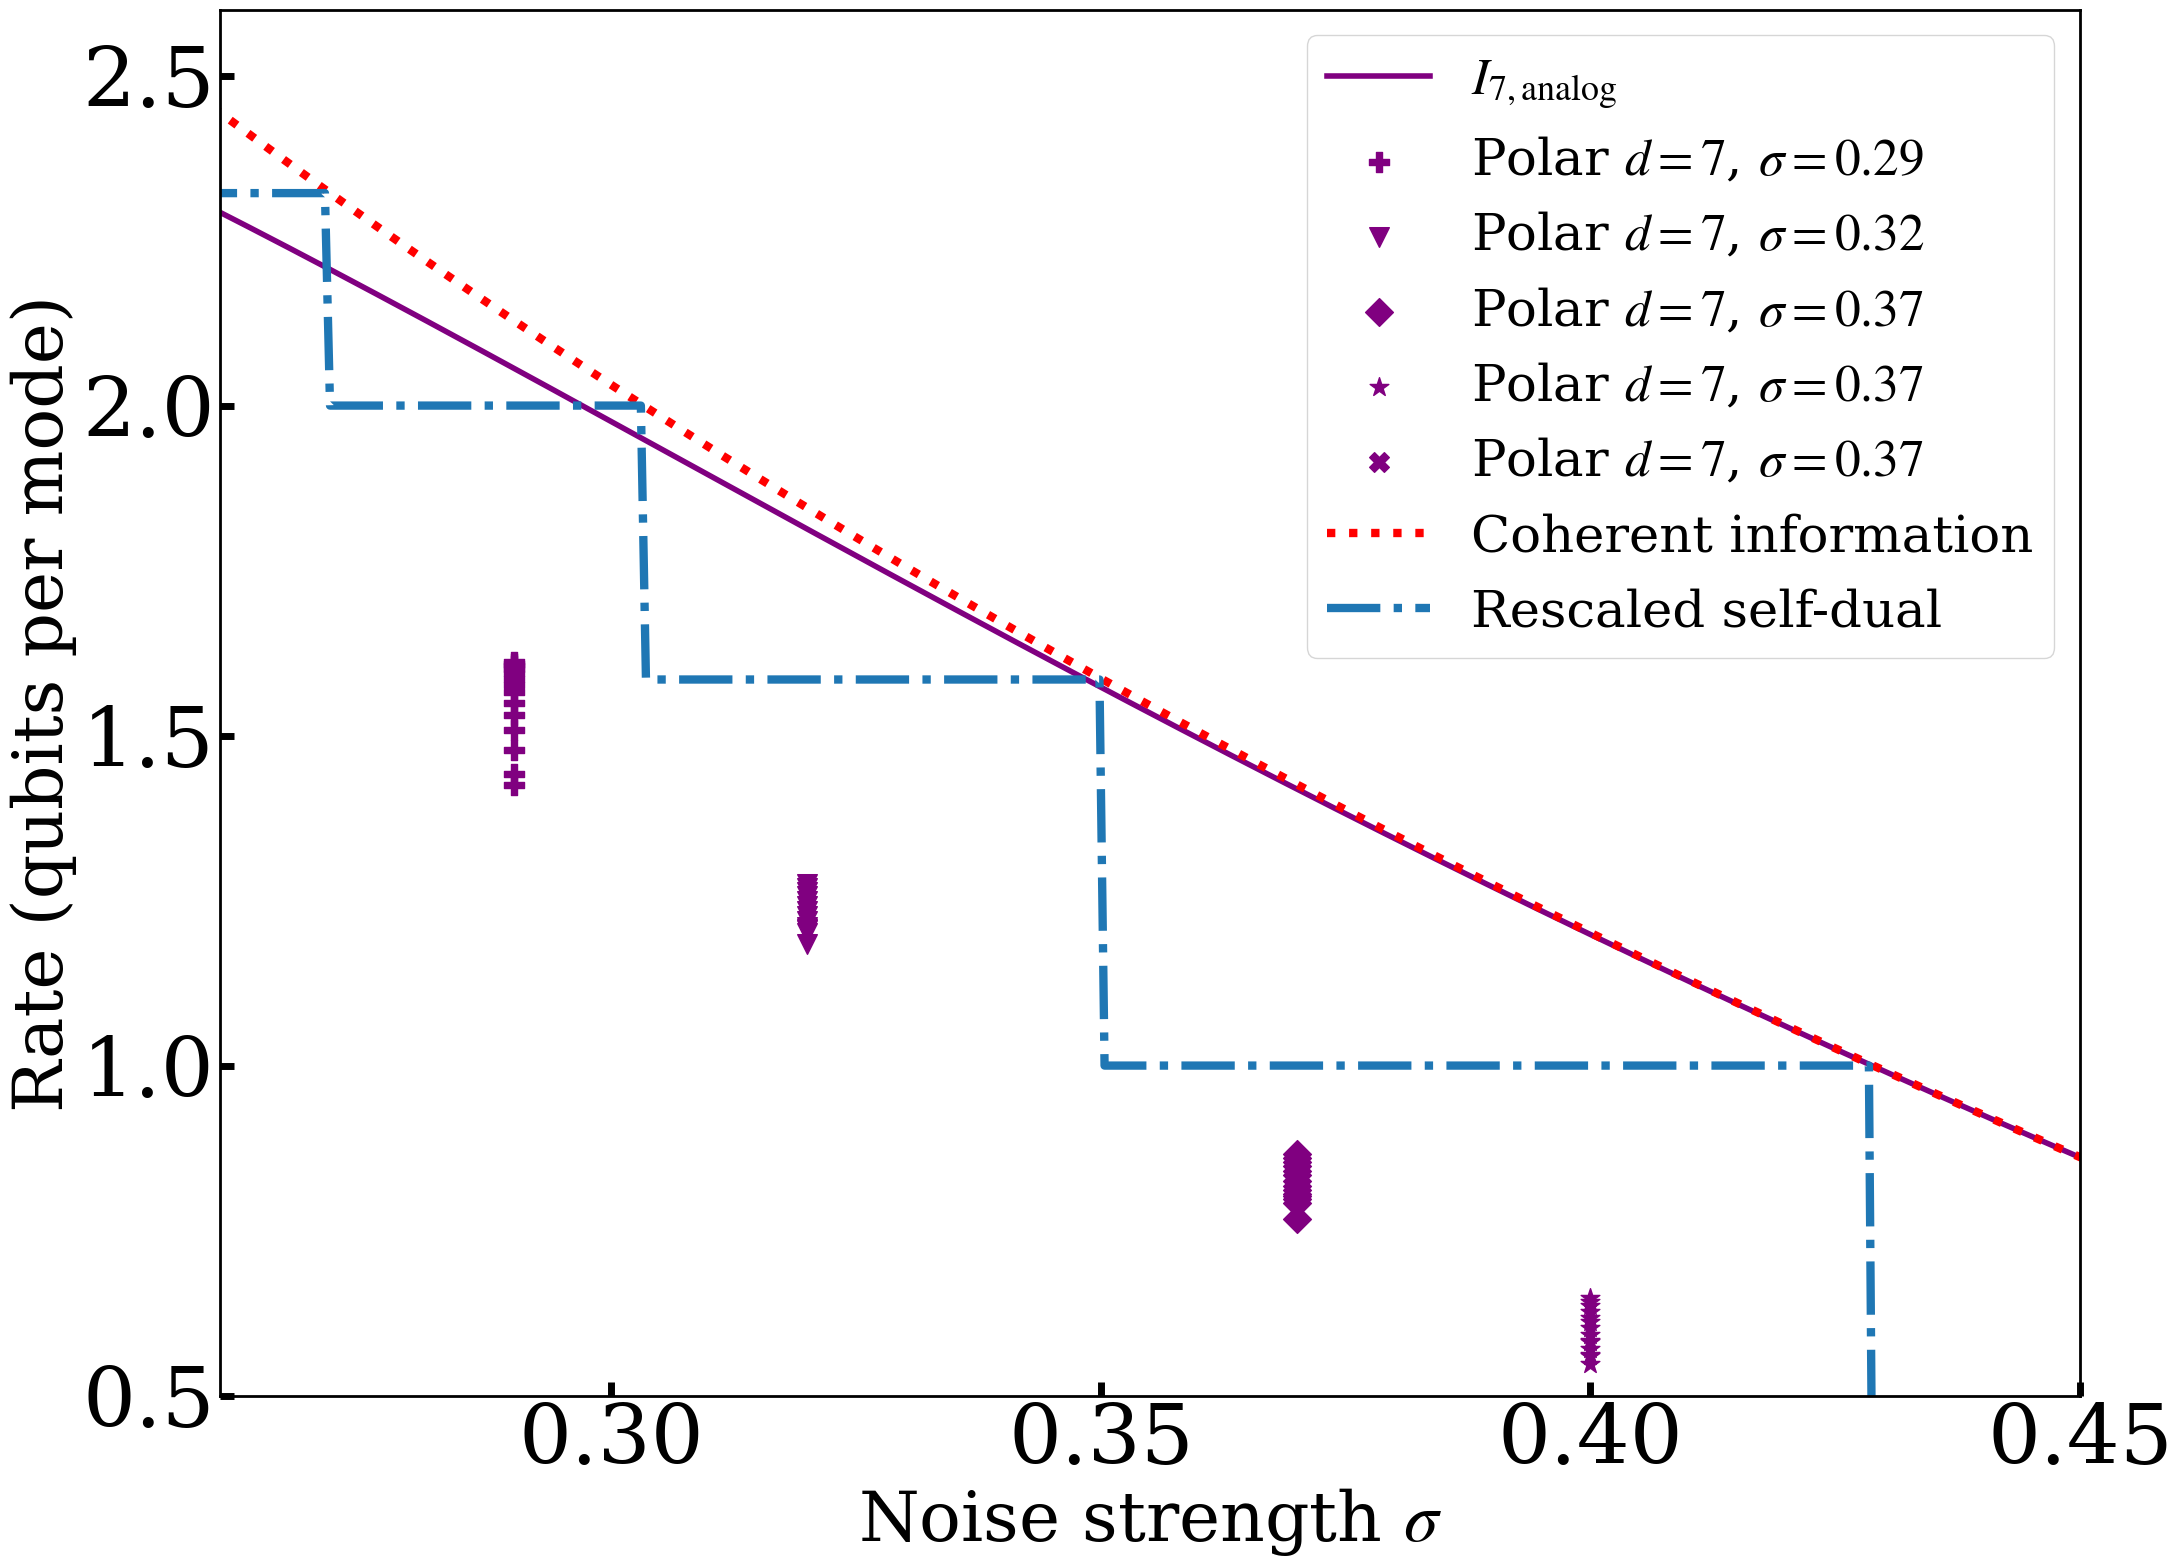

In [305]:
plt.rcParams["figure.figsize"] = (24,18)
#d=2
#plt.plot(sig1, I_analog_sq[0],label=r'$I_{2,\mathrm{analog}}$',color=colors[0],linewidth=4)
#plt.scatter([0.51]*len(rate22),rate22,label=r'Polar $\sigma=0.51$',marker='v',s=300,color=colors[0])
#plt.scatter([0.55]*len(rate),rate,label=r'Polar $\sigma=0.55$',marker='D',s=300,color=colors[0])

#d=5
#plt.plot(sig1, I_analog_sq[2],label=r'$I_{5,\mathrm{analog}}$',color=colors[2],linewidth=4)
#plt.scatter(0.4+0*np.array(rate511),np.log2(5)*np.array(crate511),s=200,marker='v',color=colors[2],label=r'Polar $d=5$, $\sigma=0.4$')
#plt.scatter(0.5+0*np.array(rate521),np.log2(5)*np.array(crate521),s=200,color=colors[2],label=r'Polar $d=5$, $\sigma=0.5$',marker='P')

#d=7
plt.plot(sig1, I_analog_sq[3],label=r'$I_{7,\mathrm{analog}}$',color=colors[3],linewidth=4)
plt.scatter(0.29+0*np.array(crate72),np.log2(7)*np.array(crate72),s=200,label=r'Polar $d=7$, $\sigma=0.29$',color=colors[3],marker='P')
plt.scatter(0.32+0*np.array(crate7),np.log2(7)*np.array(crate7),s=200,marker='v',color=colors[3],label=r'Polar $d=7$, $\sigma=0.32$')
plt.scatter(0.37+0*np.array(crate71),np.log2(7)*np.array(crate71),s=200,marker='D',color=colors[3],label=r'Polar $d=7$, $\sigma=0.37$')
plt.scatter(0.4+0*np.array(crate73),np.log2(7)*np.array(crate73),s=200,marker='*',color=colors[3],label=r'Polar $d=7$, $\sigma=0.37$')
plt.scatter(0.44+0*np.array(crate74),np.log2(7)*np.array(crate74),s=200,marker='X',color=colors[3],label=r'Polar $d=7$, $\sigma=0.37$')


plt.plot(sig1,coherent_info(sig1),label='Coherent information',linewidth=6,color='red',linestyle='dotted')
plt.plot(sig1,np.log2(np.floor(np.exp2(coherent_info(sig1)))),label=r'Rescaled self-dual',linewidth=6,linestyle='-.')

plt.xlim(0.26,0.45)
plt.ylim(0.5,2.6)
plt.ylabel('Rate (qubits per mode)',fontsize=50)
plt.xlabel(r'Noise strength $\sigma$',fontsize=50)
plt.tick_params(axis='y', direction='in',width=5,length=10)
plt.tick_params(axis='x', direction='in',width=5,length=10)
plt.legend(fontsize=37,loc=1)
#plt.yscale('log')

In [74]:
def logsum_var(Alogs):
    samples = Alogs.shape[0]
    logsum_sqA = scipy.special.logsumexp(2*Alogs, axis=0) - np.log(samples)
    logsum_A = scipy.special.logsumexp(Alogs, axis=0) - np.log(samples)
    return scipy.special.logsumexp(np.stack([logsum_sqA, logsum_A*2],axis=0), axis = 0, b = np.array([1.0, -1.0]).reshape(2,1))

In [99]:
log_z_8_mc_all2 = np.array([np.load('Zdata_var2/Z_Wi_sig0.4_8_d5_a2_try'+str(i)+'.npy') for i in range(10)])
log_z_8_mc_mean2 = scipy.special.logsumexp(log_z_8_mc_all2, axis = 0) - np.log(log_z_8_mc_all2.shape[0])
log_z_8_mc_var2 = logsum_var(log_z_8_mc_all2)

(0.0001, 100)

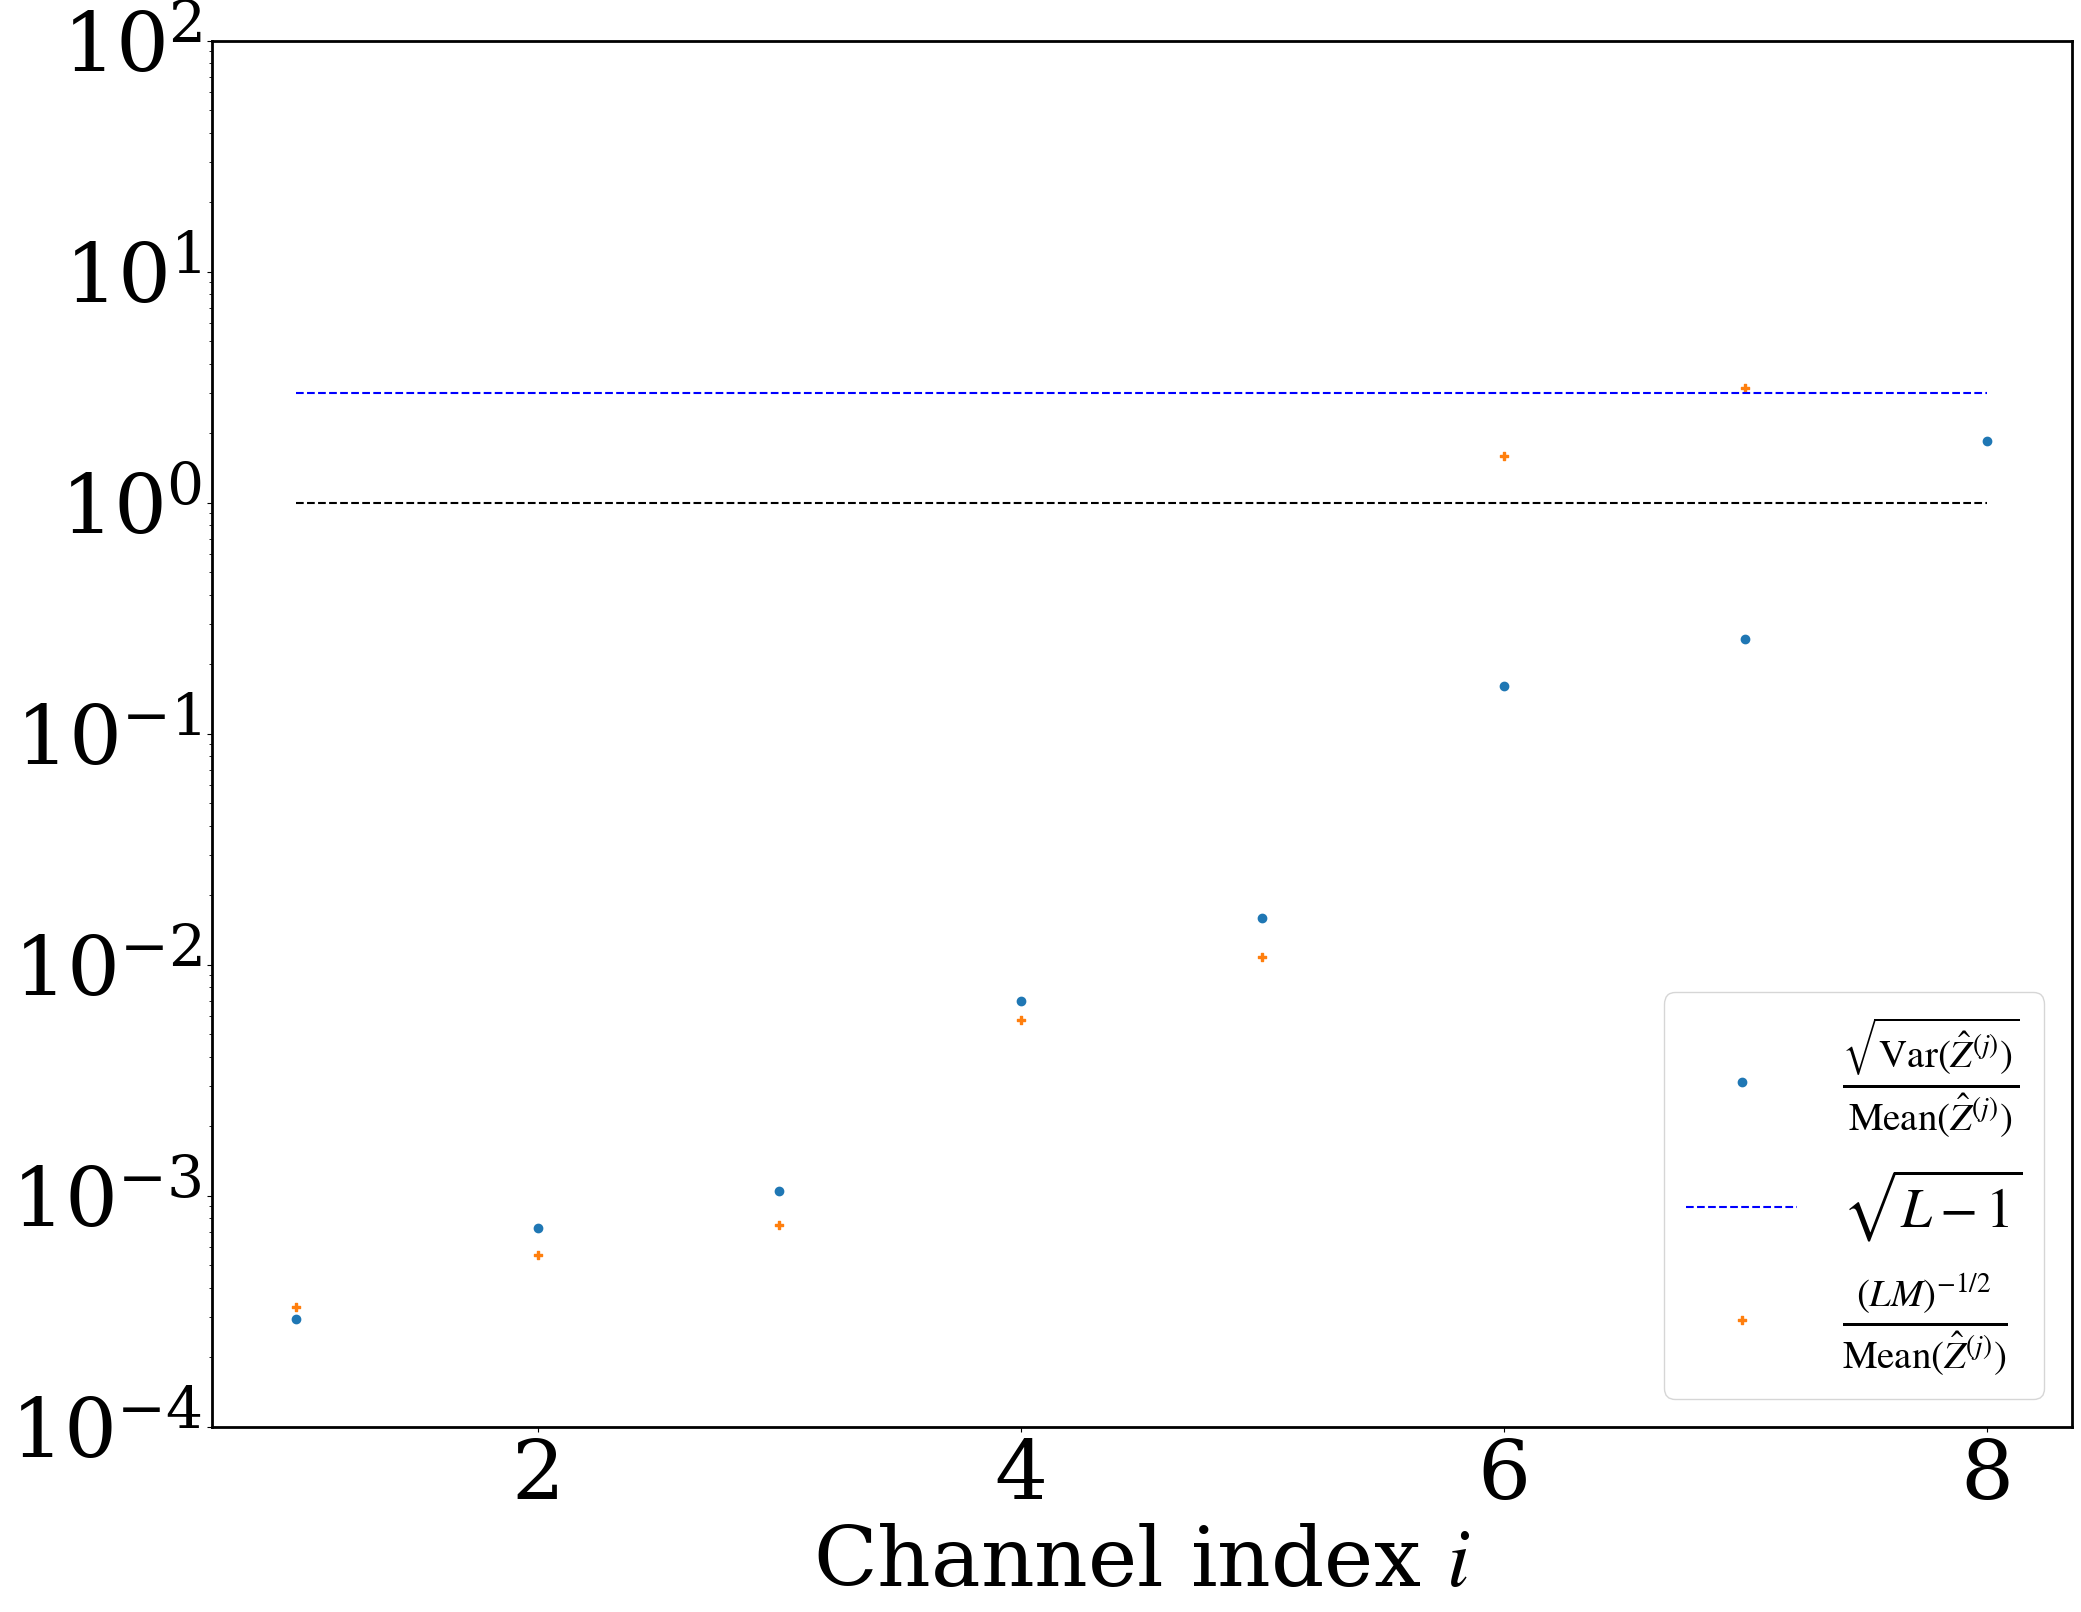

In [131]:
plt.scatter(range(1,9),np.exp(log_z_8_mc_var2*0.5 - log_z_8_mc_mean2),label=r'$\frac{\sqrt{\mathrm{Var}(\hat{Z}^{(j)})}}{\mathrm{Mean}(\hat{Z}^{(j)})}$')
plt.plot([1,8],[1,1],'k--')
plt.plot([1,8],[3,3],'b--',label=r'$\sqrt{L-1}$')
plt.scatter(range(1,9),(1/np.sqrt(10*(2**20)))*np.exp(-log_z_8_mc_mean2),marker='P',label=r'$\frac{(LM)^{-1/2}}{\mathrm{Mean}(\hat{Z}^{(j)})}$')
plt.yscale('log')
plt.legend()
plt.xlabel('Channel index $i$')
plt.ylim(1e-4,100)


In [79]:
log_z_512_mc_all = np.array([np.load('Zdata_var1/Z_Wi_sig0.4_512_d5_a1_try'+str(i)+'.npy') for i in range(10)])
log_z_512_mc_mean = scipy.special.logsumexp(log_z_512_mc_all, axis = 0) - np.log(log_z_512_mc_all.shape[0])
log_z_512_mc_var = logsum_var(log_z_512_mc_all)
log_z_512_mc_all2 = np.array([np.load('Zdata_var1/Z_Wi_sig0.4_512_d5_a2_try'+str(i)+'.npy') for i in range(10)])
log_z_512_mc_mean2 = scipy.special.logsumexp(log_z_512_mc_all2, axis = 0) - np.log(log_z_512_mc_all2.shape[0])
log_z_512_mc_var2 = logsum_var(log_z_512_mc_all2)

(1e-10, 0.001)

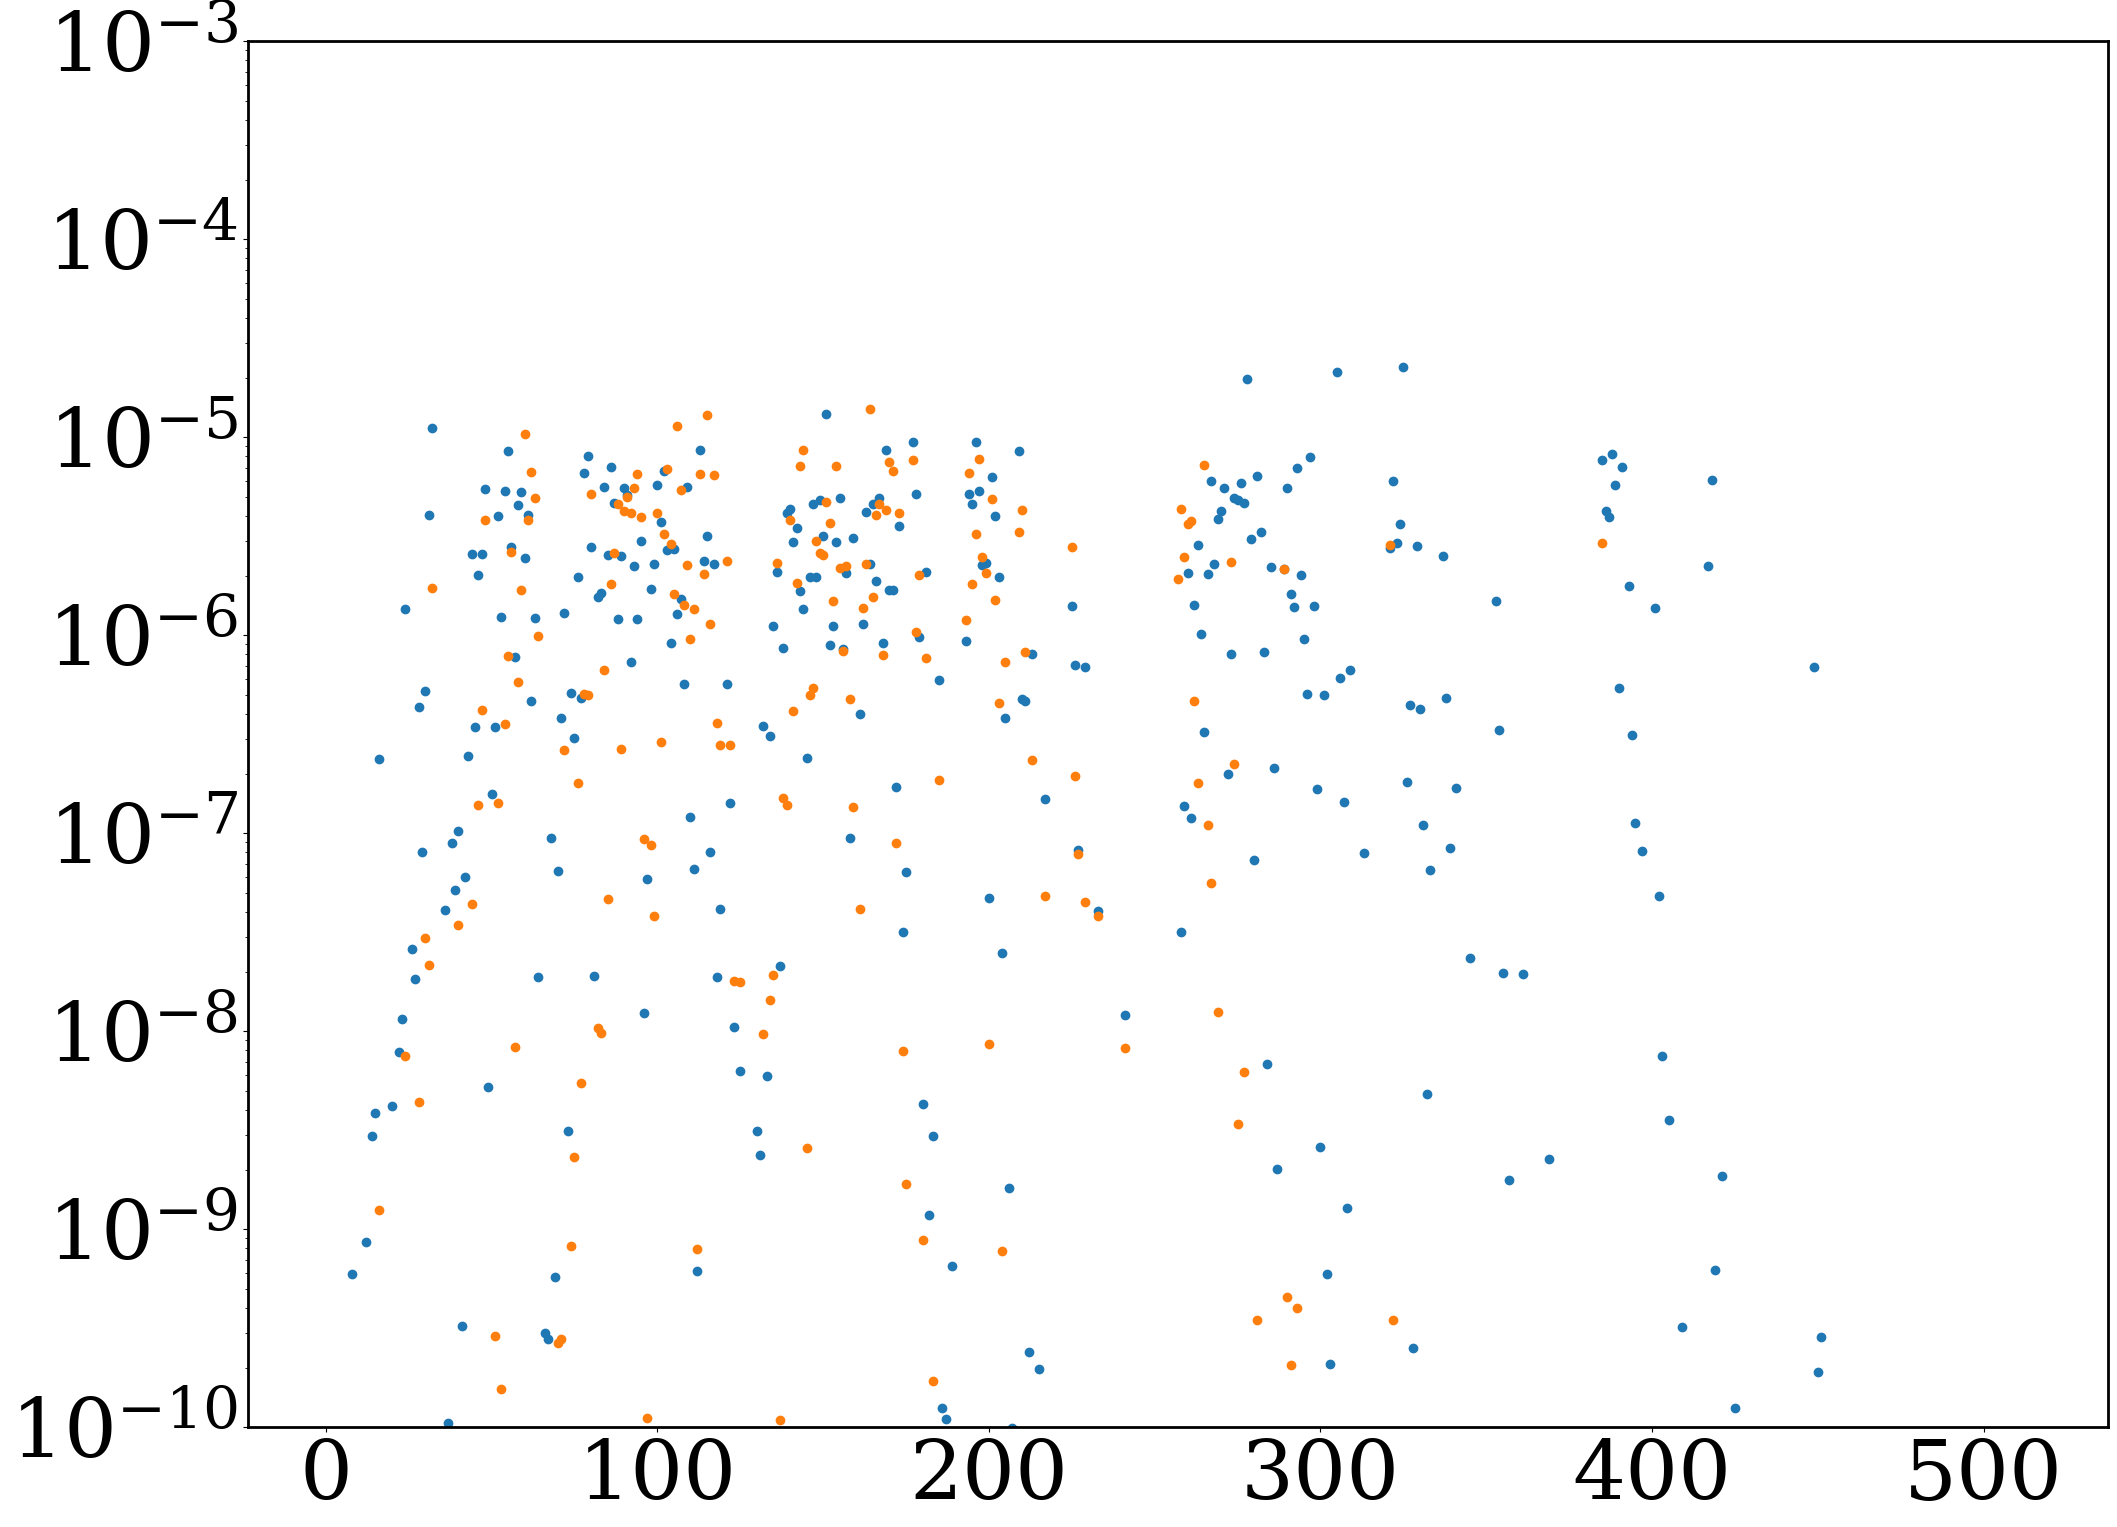

In [80]:
plt.scatter(range(1,513),np.exp(log_z_512_mc_var))
plt.scatter(range(1,513),np.exp(log_z_512_mc_var2))
plt.yscale('log')
plt.ylim(1e-10,1e-3)

/var/folders/dd/7cnlb81x5cxgmvjv3rvqzp780000gp/T/ipykernel_56132/3626016451.py:1: RuntimeWarning: invalid value encountered in subtract
  plt.scatter(range(1,513),np.exp(0.5*log_z_512_mc_var2 - log_z_512_mc_mean2),label=r'$\alpha = 2$')
/var/folders/dd/7cnlb81x5cxgmvjv3rvqzp780000gp/T/ipykernel_56132/3626016451.py:2: RuntimeWarning: invalid value encountered in subtract
  plt.scatter(range(1,513),np.exp(0.5*log_z_512_mc_var - log_z_512_mc_mean),label=r'$\alpha = 1$')


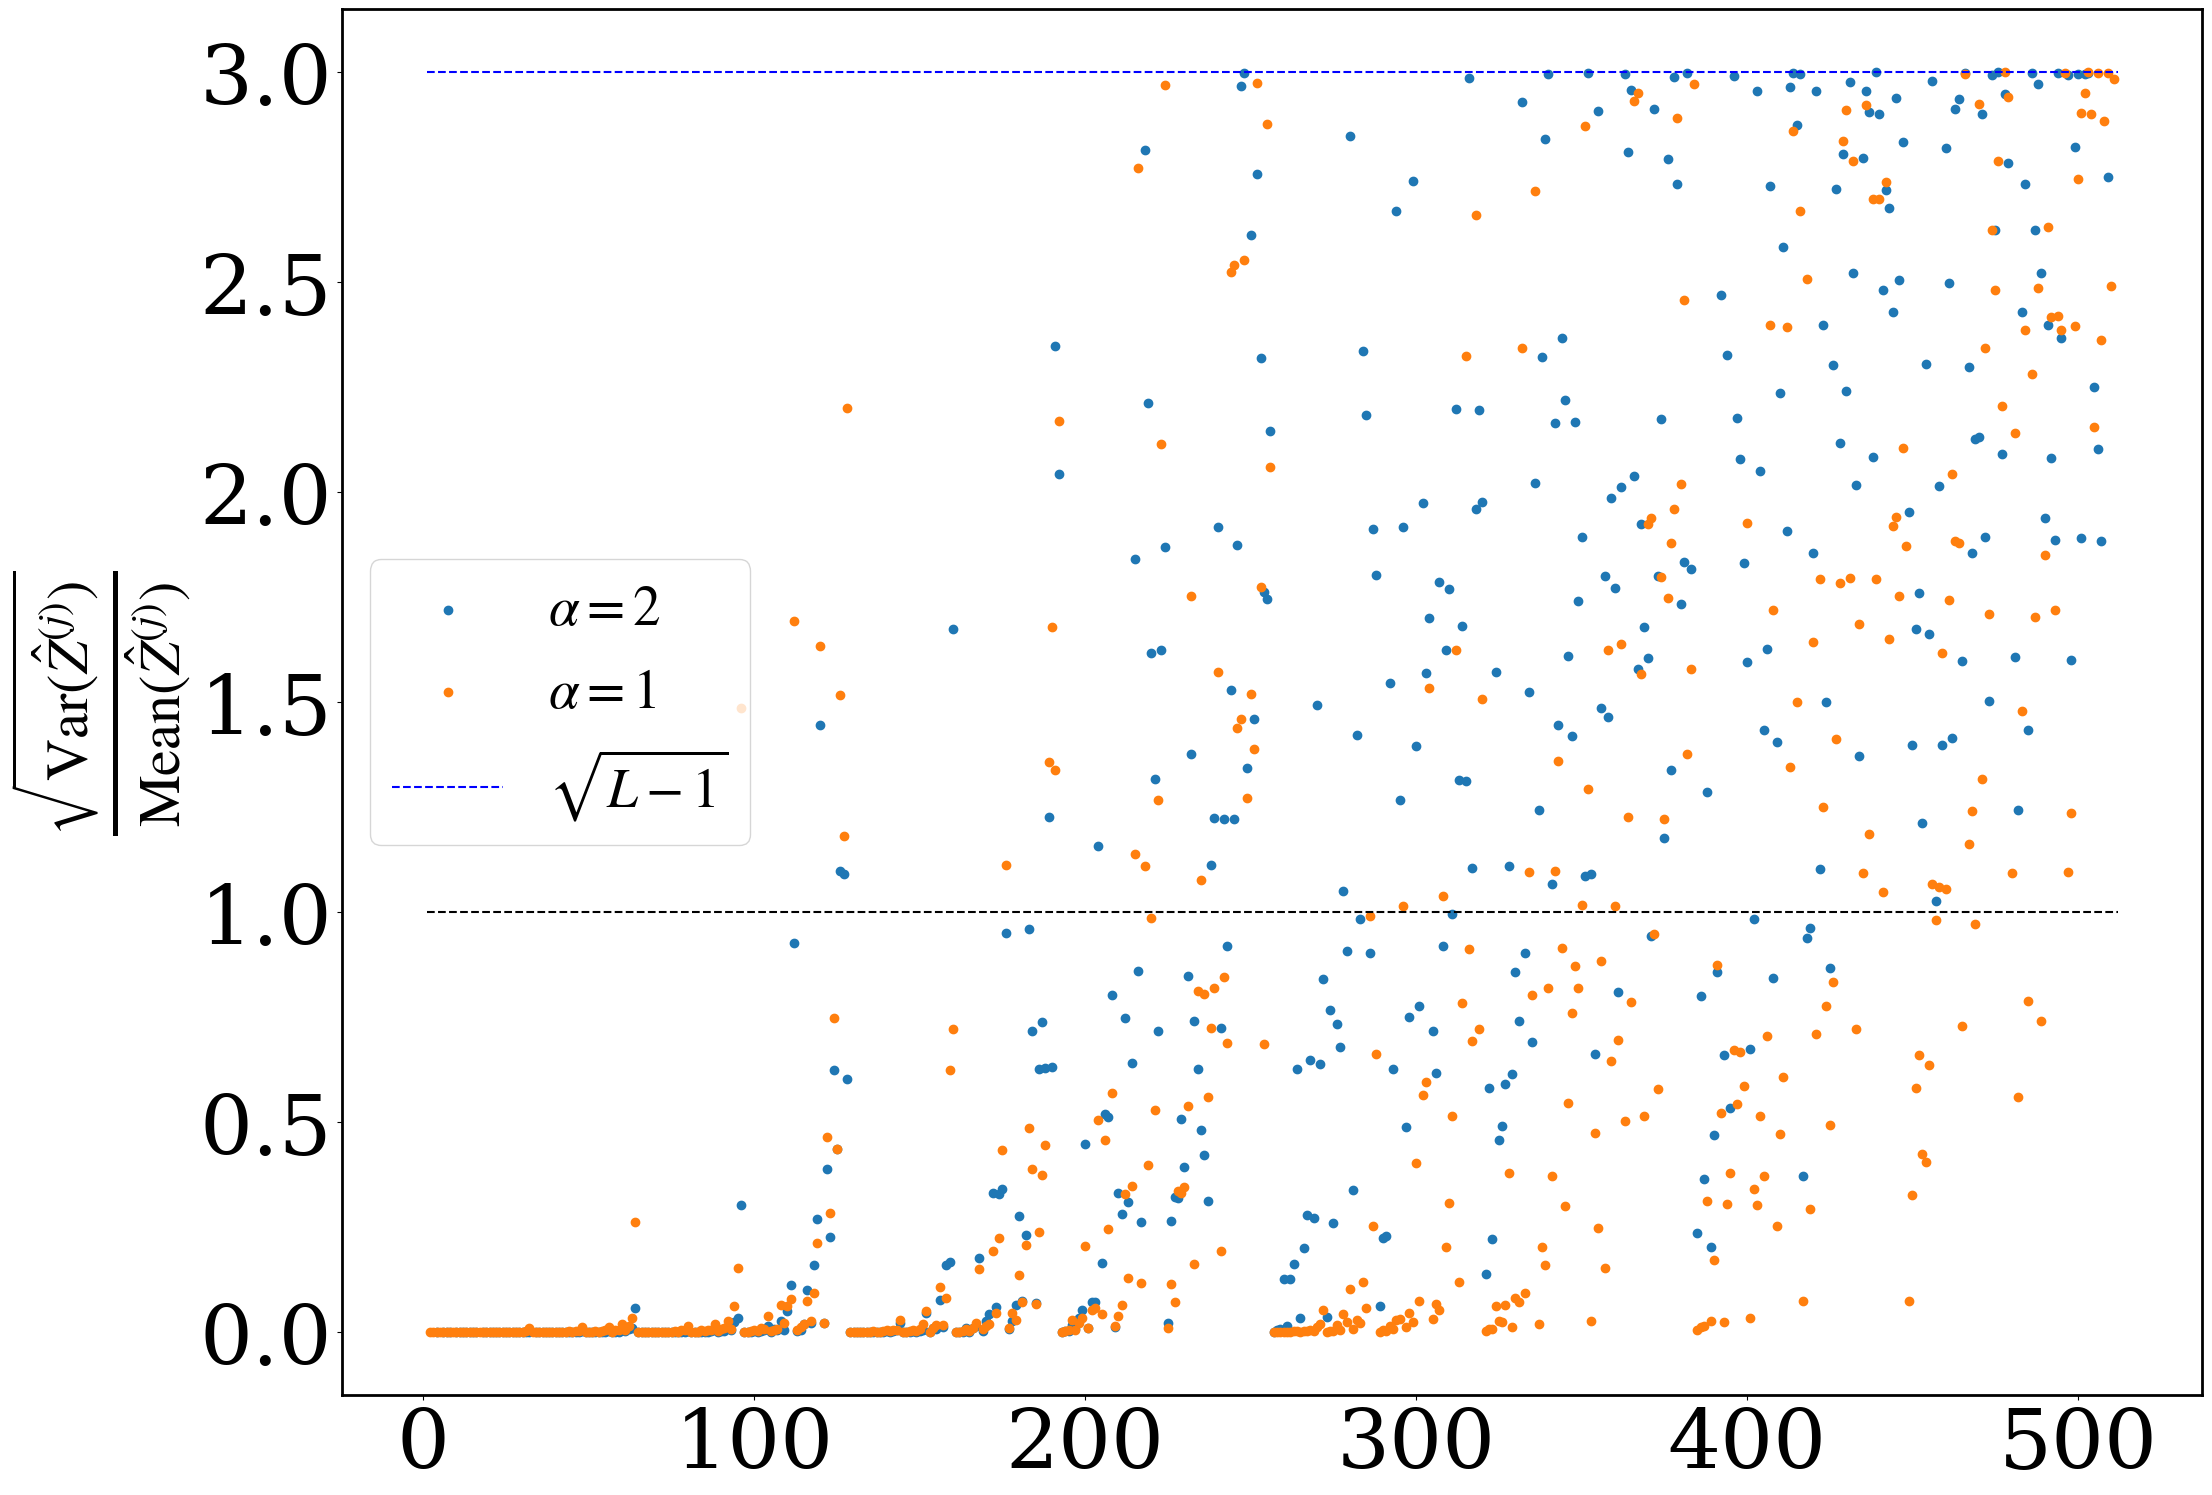

In [135]:
plt.scatter(range(1,513),np.exp(0.5*log_z_512_mc_var2 - log_z_512_mc_mean2),label=r'$\alpha = 2$')
plt.scatter(range(1,513),np.exp(0.5*log_z_512_mc_var - log_z_512_mc_mean),label=r'$\alpha = 1$')
#plt.yscale('log')
#plt.ylim(1e-16,10)
plt.plot([1,512],[1,1],'k--')
plt.plot([1,512],[3,3],'b--',label=r'$\sqrt{L-1}$')
plt.ylabel(r'$\frac{\sqrt{\mathrm{Var}(\hat{Z}^{(j)})}}{\mathrm{Mean}(\hat{Z}^{(j)})}$')
plt.legend()

In [95]:
log_z_1024_mc_all = np.array([np.load('Zdata_var1/Z_Wi_sig0.4_1024_d5_a1_try'+str(i)+'.npy') for i in range(10)])
log_z_1024_mc_mean = scipy.special.logsumexp(log_z_1024_mc_all, axis = 0) - np.log(log_z_1024_mc_all.shape[0])
log_z_1024_mc_var = logsum_var(log_z_1024_mc_all)
log_z_1024_mc_all2 = np.array([np.load('Zdata_var1/Z_Wi_sig0.4_1024_d5_a2_try'+str(i)+'.npy') for i in range(10)])
log_z_1024_mc_mean2 = scipy.special.logsumexp(log_z_1024_mc_all2, axis = 0) - np.log(log_z_1024_mc_all2.shape[0])
log_z_1024_mc_var2 = logsum_var(log_z_1024_mc_all2)

(1e-10, 0.001)

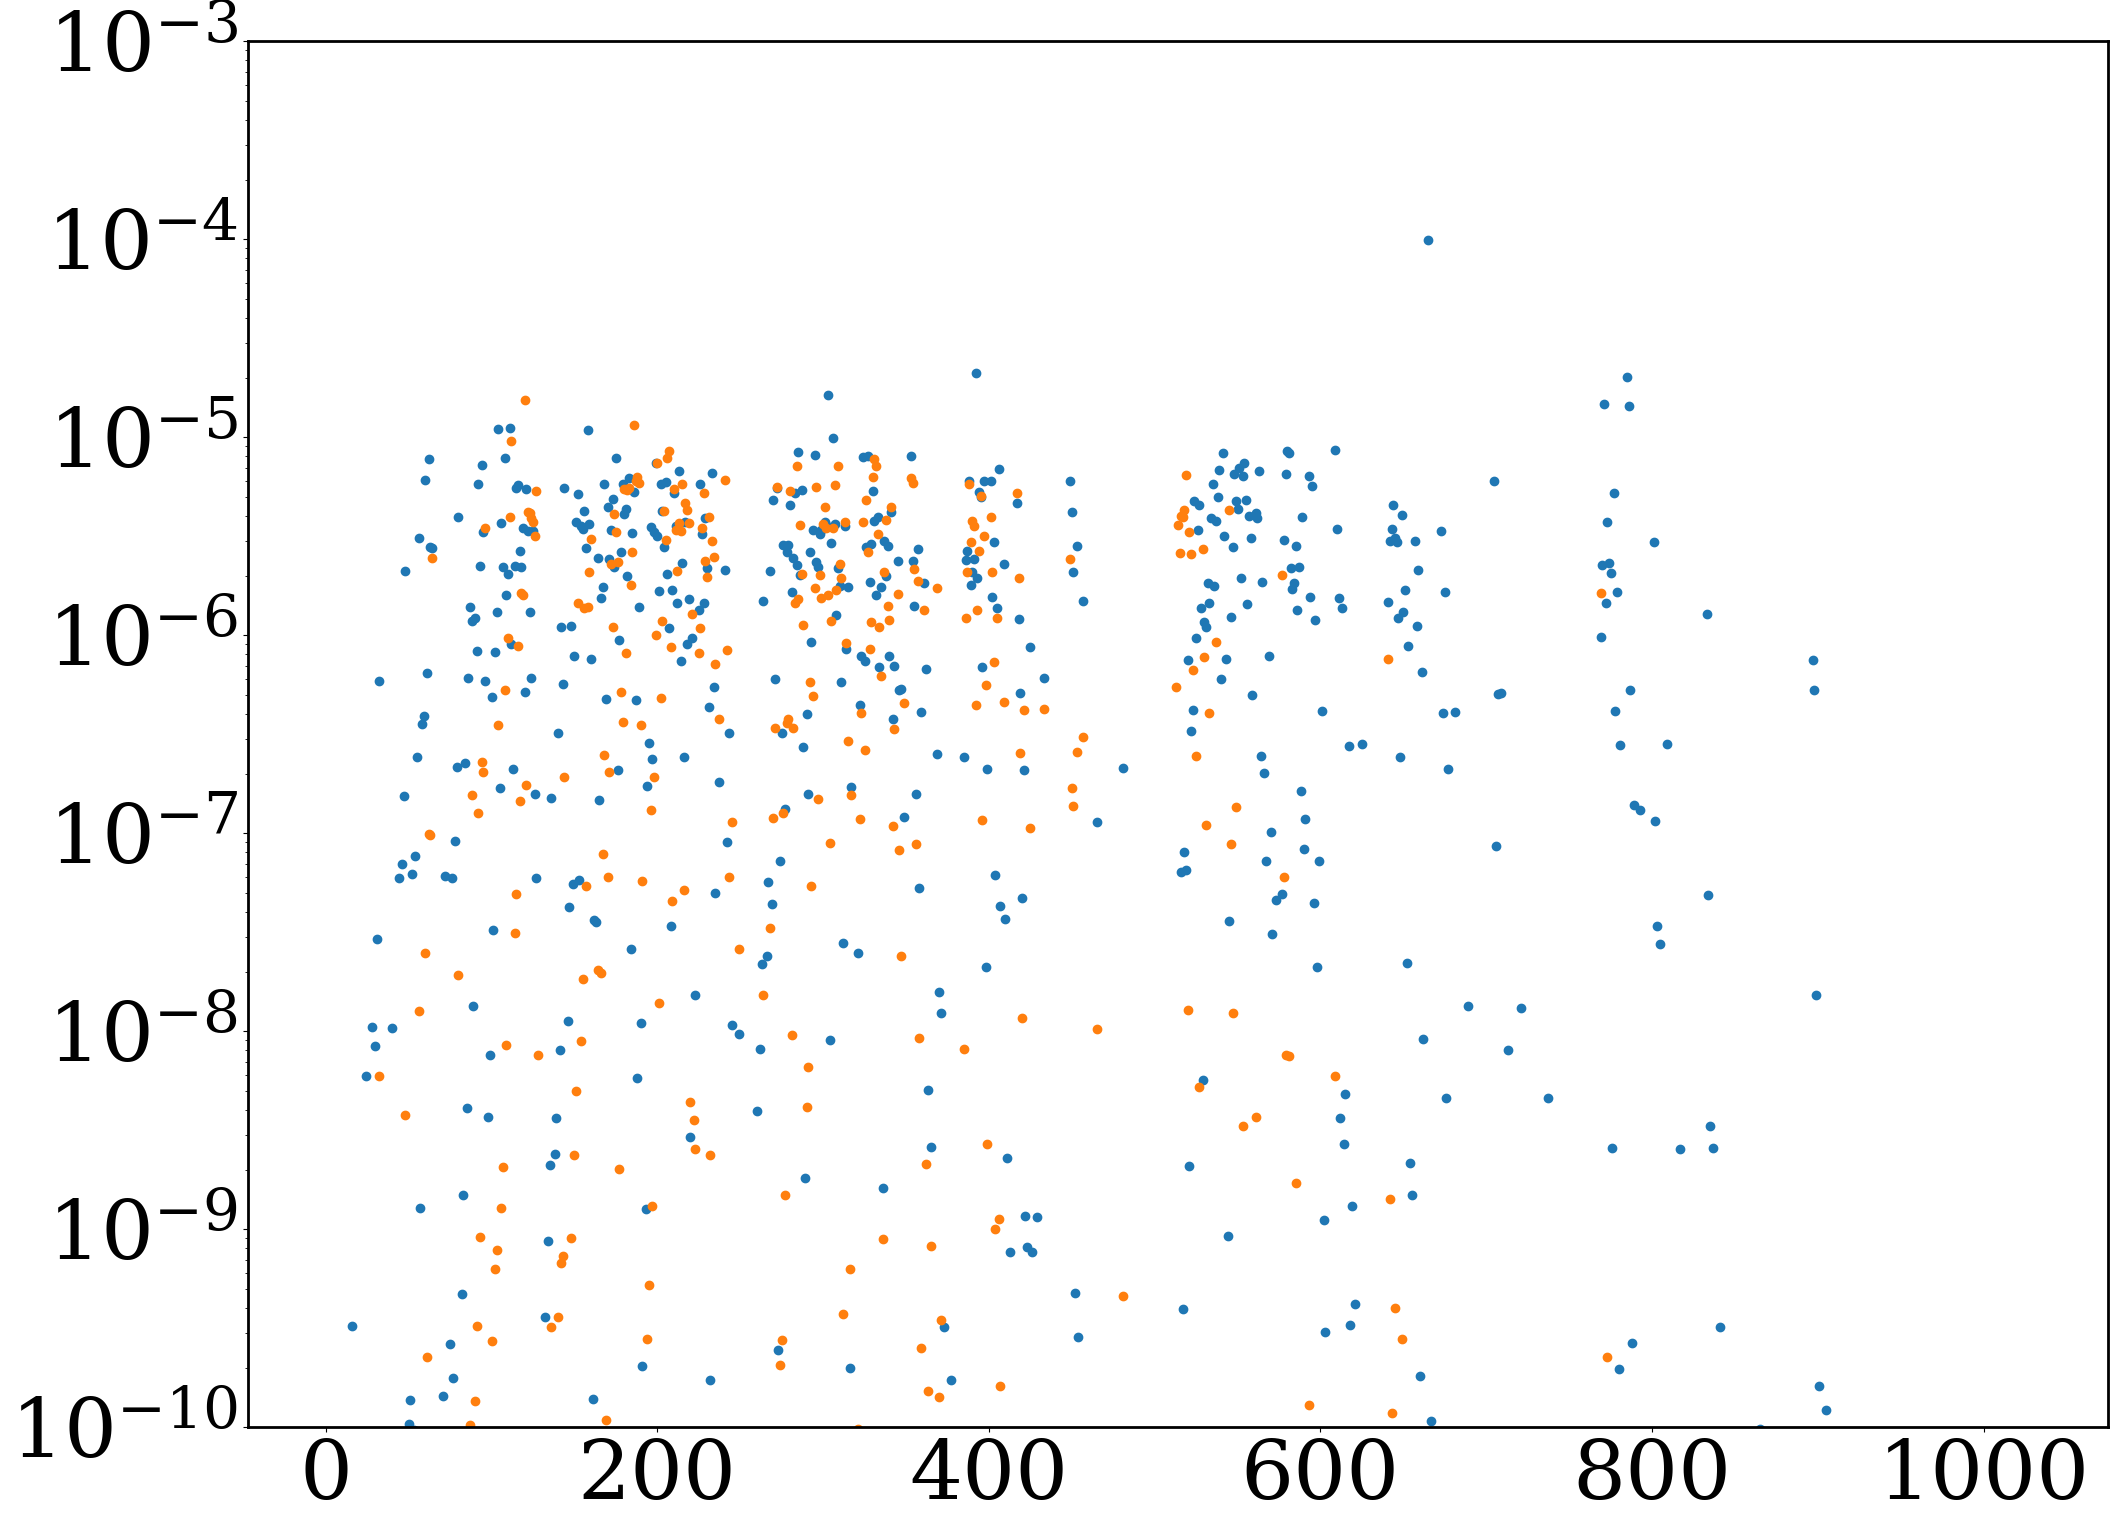

In [96]:
plt.scatter(range(1,1025),np.exp(log_z_1024_mc_var))
plt.scatter(range(1,1025),np.exp(log_z_1024_mc_var2))
plt.yscale('log')
plt.ylim(1e-10,1e-3)

/var/folders/dd/7cnlb81x5cxgmvjv3rvqzp780000gp/T/ipykernel_56132/481029887.py:1: RuntimeWarning: invalid value encountered in subtract
  plt.scatter(range(1,1025),np.exp(0.5*log_z_1024_mc_var2 - log_z_1024_mc_mean2),label=r'$\alpha = 2$')
/var/folders/dd/7cnlb81x5cxgmvjv3rvqzp780000gp/T/ipykernel_56132/481029887.py:2: RuntimeWarning: invalid value encountered in subtract
  plt.scatter(range(1,1025),np.exp(0.5*log_z_1024_mc_var - log_z_1024_mc_mean),label=r'$\alpha = 1$')


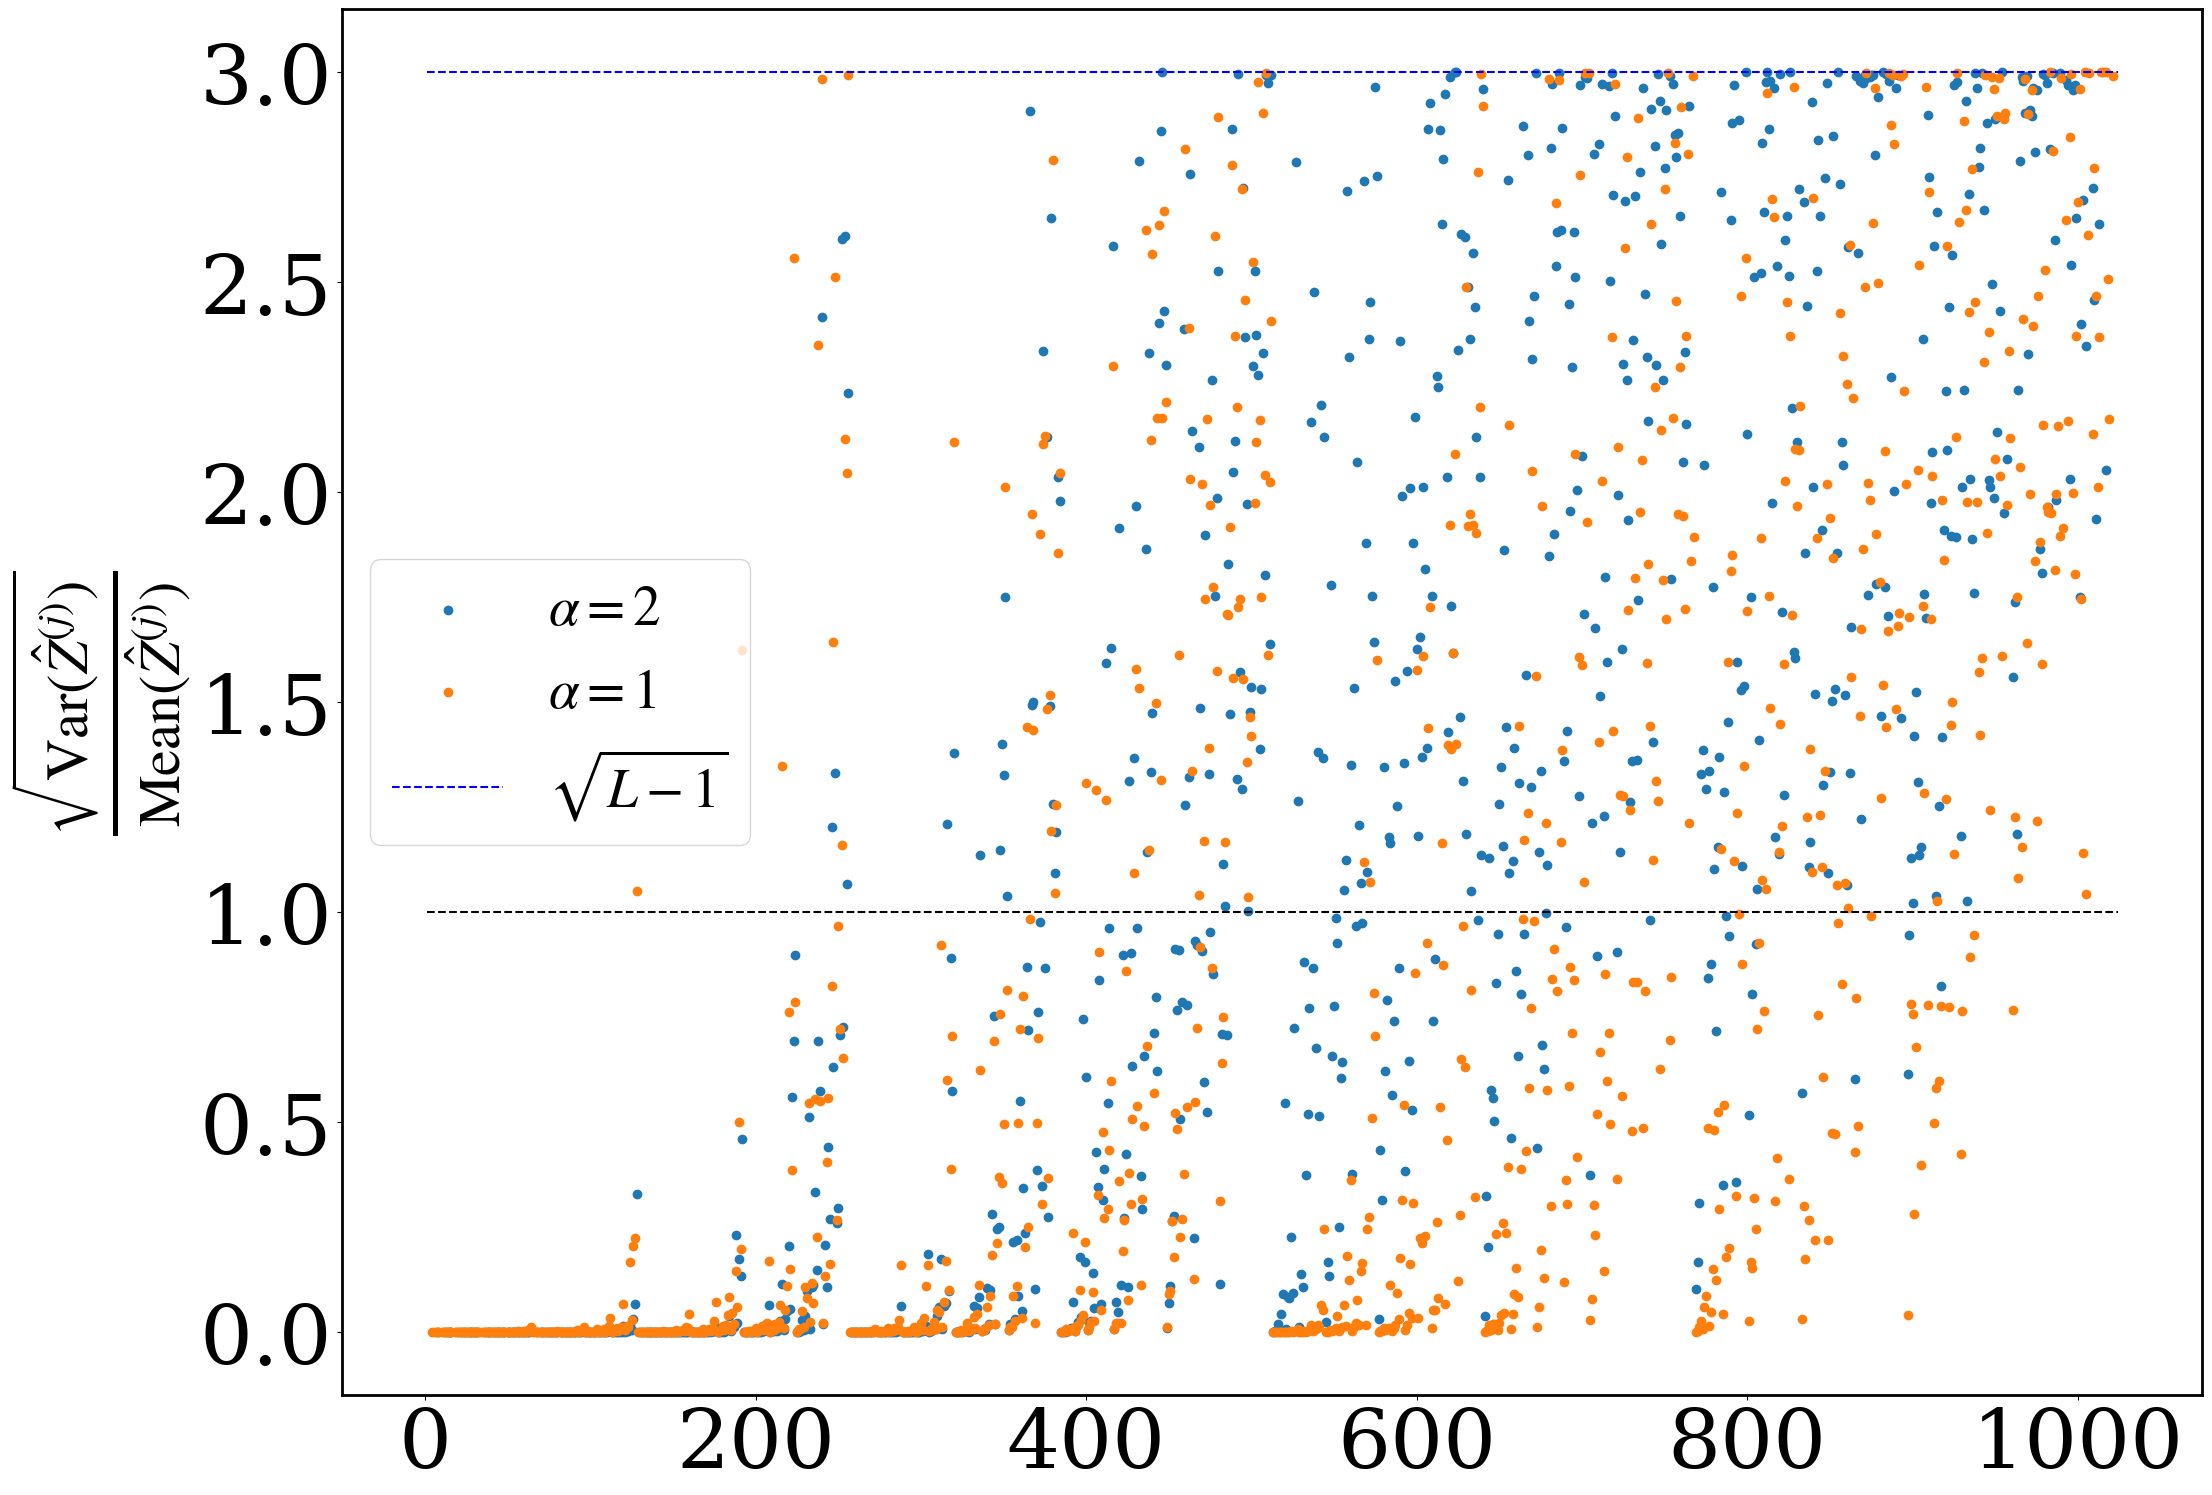

In [136]:
plt.scatter(range(1,1025),np.exp(0.5*log_z_1024_mc_var2 - log_z_1024_mc_mean2),label=r'$\alpha = 2$')
plt.scatter(range(1,1025),np.exp(0.5*log_z_1024_mc_var - log_z_1024_mc_mean),label=r'$\alpha = 1$')
#plt.yscale('log')
#plt.ylim(1e-16,10)
plt.ylabel(r'$\frac{\sqrt{\mathrm{Var}(\hat{Z}^{(j)})}}{\mathrm{Mean}(\hat{Z}^{(j)})}$')
plt.plot([1,1024],[1,1],'k--')
plt.plot([1,1024],[np.sqrt(9),np.sqrt(9)],'b--',label=r'$\sqrt{L-1}$')
plt.legend()

In [88]:
log_z_2048_mc_all = np.array([np.load('Zdata_var1/Z_Wi_sig0.4_2048_d5_a1_try'+str(i)+'.npy') for i in range(3)])
log_z_2048_mc_mean = scipy.special.logsumexp(log_z_2048_mc_all, axis = 0) - np.log(log_z_2048_mc_all.shape[0])
log_z_2048_mc_var = logsum_var(log_z_2048_mc_all)
log_z_2048_mc_all2 = np.array([np.load('Zdata_var1/Z_Wi_sig0.4_2048_d5_a2_try'+str(i)+'.npy') for i in range(3)])
log_z_2048_mc_mean2 = scipy.special.logsumexp(log_z_2048_mc_all2, axis = 0) - np.log(log_z_2048_mc_all2.shape[0])
log_z_2048_mc_var2 = logsum_var(log_z_2048_mc_all2)

(1e-10, 0.001)

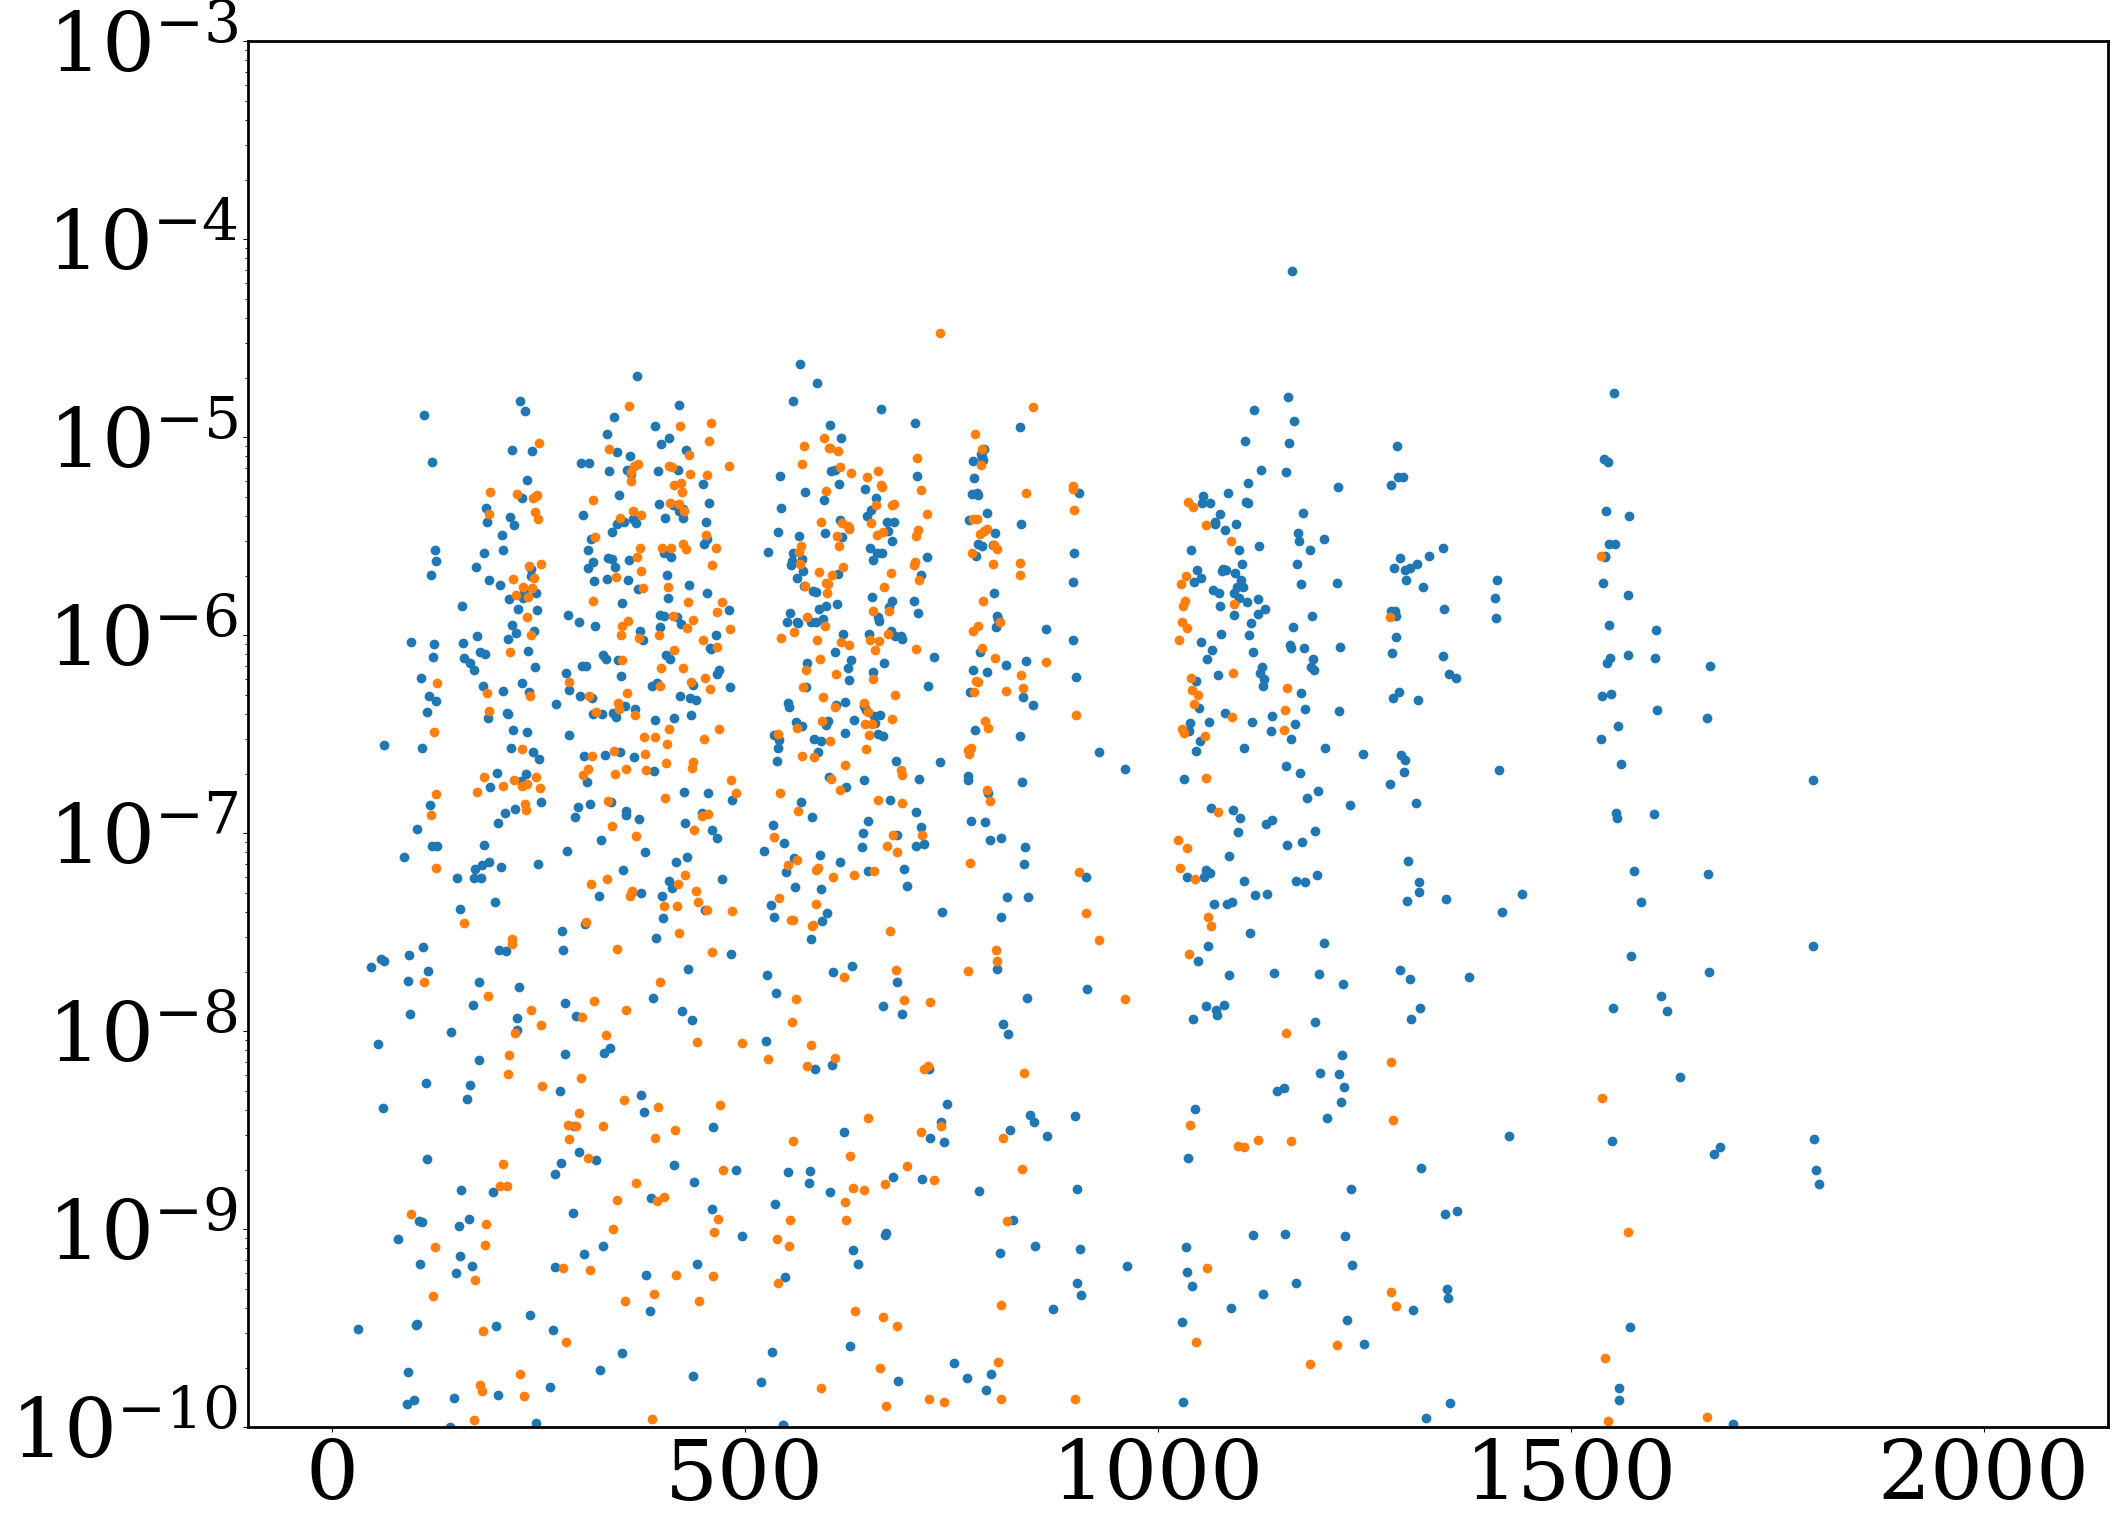

In [89]:
plt.scatter(range(1,2049),np.exp(log_z_2048_mc_var))
plt.scatter(range(1,2049),np.exp(log_z_2048_mc_var2))
plt.yscale('log')
plt.ylim(1e-10,1e-3)

/var/folders/dd/7cnlb81x5cxgmvjv3rvqzp780000gp/T/ipykernel_56132/1814162117.py:1: RuntimeWarning: invalid value encountered in subtract
  plt.scatter(range(1,2049),np.exp(0.5*log_z_2048_mc_var - log_z_2048_mc_mean))
/var/folders/dd/7cnlb81x5cxgmvjv3rvqzp780000gp/T/ipykernel_56132/1814162117.py:2: RuntimeWarning: invalid value encountered in subtract
  plt.scatter(range(1,2049),np.exp(0.5*log_z_2048_mc_var2 - log_z_2048_mc_mean2))


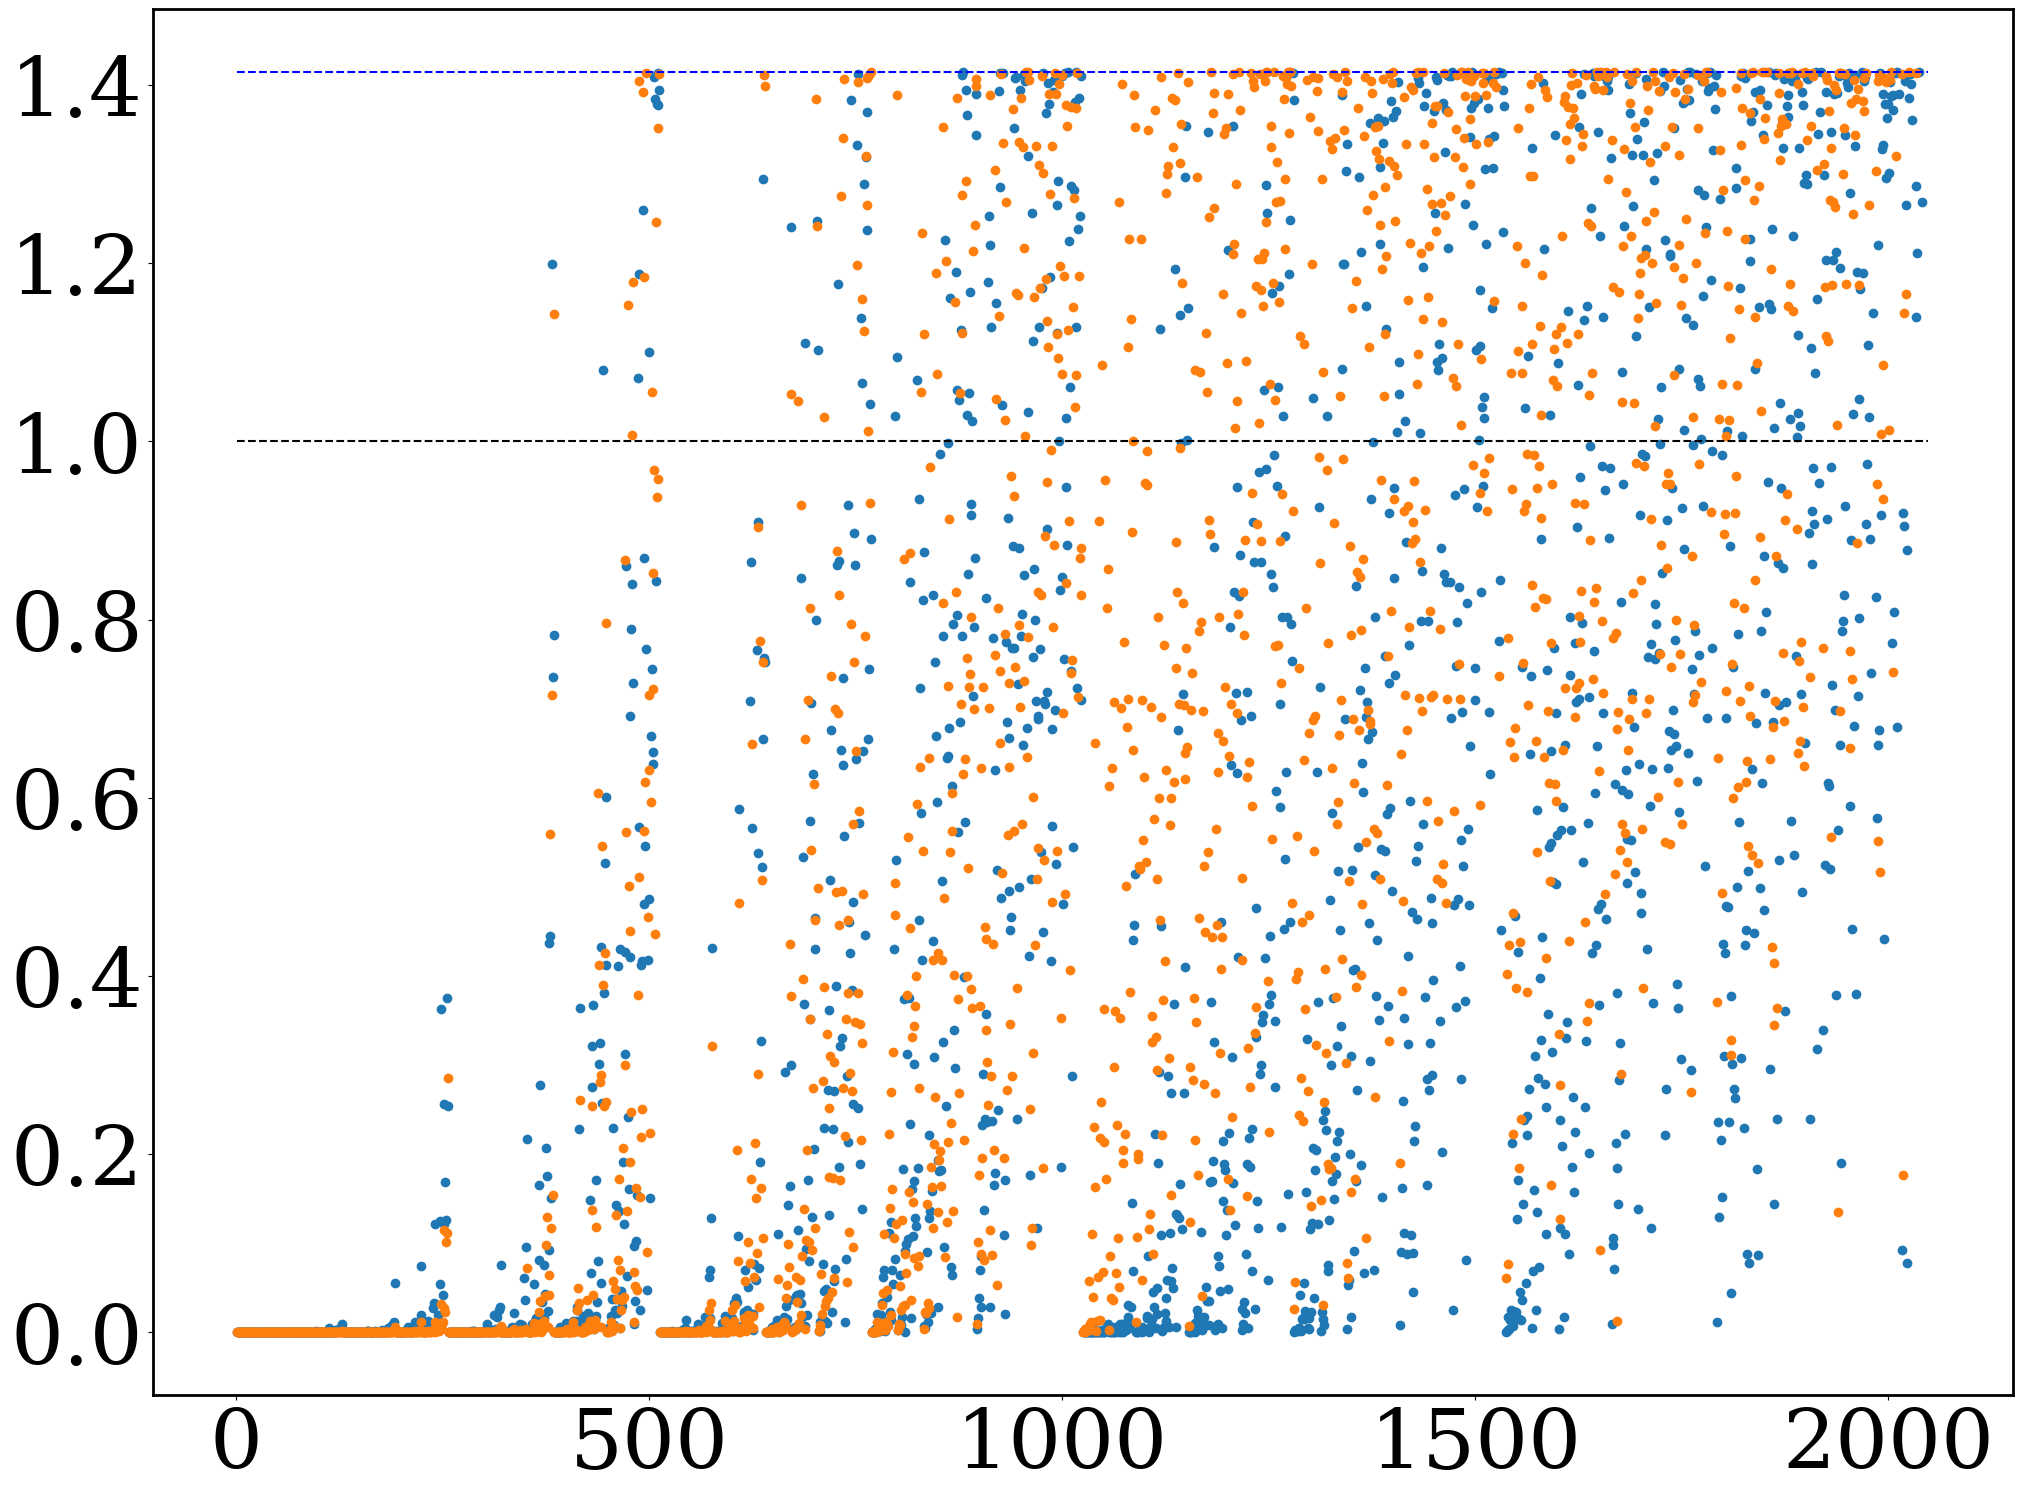

In [90]:
plt.scatter(range(1,2049),np.exp(0.5*log_z_2048_mc_var - log_z_2048_mc_mean))
plt.scatter(range(1,2049),np.exp(0.5*log_z_2048_mc_var2 - log_z_2048_mc_mean2))
plt.plot([1,2048],[1,1],'k--')
plt.plot([1,2048],[np.sqrt(2),np.sqrt(2)],'b--')